# 07 — LM5176 Pin Design, Stability & Compensation

**Project:** USB-C PD → 12 V fan-array controller (LM5176 4-switch buck-boost, 42 W)

**Purpose:** Size every LM5176 support component (feedback divider, current sense, slope compensation, soft start, RT, dither) and design the frequency compensation. The loop is deliberately slow (f_bw ≈ 11 Hz) so the converter draws steady input power while the output bank absorbs the ~160 Hz fan commutation ripple — this choice is what later broke the LM5176's pre-bias startup (see `uvlo/`).

**Compensation history:** good low-frequency design → values accidentally assembled on PCB v1 → maximum-bandwidth alternative → chosen PCB v1 modification.

**See also:** 05 (why the loop must be slow), `uvlo/` (UVLO divider + lockout latch that replaced the plain divider studied here).

> **Note:** the simulation cells in this notebook take minutes to run, so the outputs shown are preserved from the original run (code cleaned, paths fixed, `%matplotlib widget` → `inline`). Re-run top-to-bottom locally to refresh.


## Config

Max Fan Load Power: 42.00W


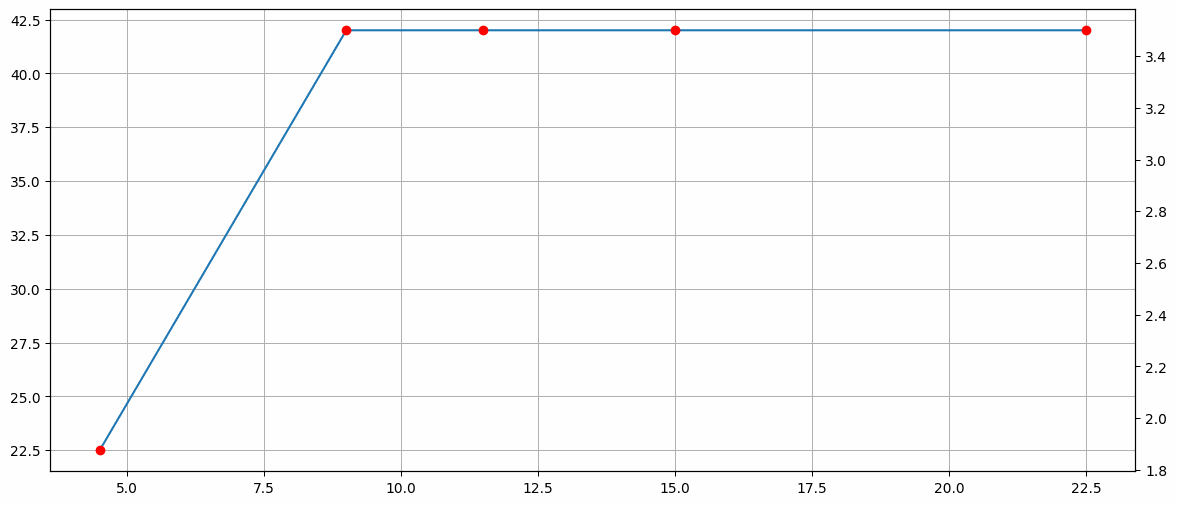

c_out r_esr: 18.34 mOhm


In [1]:
import sys; sys.path.insert(0, '..')   # repo root: constants.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- System Constants ---
USB_V_TOLERANCE = 0.10
USB_I_MAX_AMPS = 5.0
USB_I_NOMINAL_AMPS = 3.0

FAN_V_NOMINAL = 12.0
FAN_P14_PRO_MAX_I = 0.35
FAN_COUNT_MAX = 10

SWITCHING_FREQ_HZ = 100e3
INDUCTOR_L_HENRY = 47e-6

#USB-C power sources, 5V to 20V, 5A
v_in_min_nominal = 5
v_in_max_nominal = 20
USB_V_TOLERANCE = 0.1 # 10% tolerance
#v_in = np.linspace(v_in_min_nominal*(1-usb_c_v_tolerance), v_in_max_nominal*(1+usb_c_v_tolerance), 10)
v_in = np.array([4.5, 9, 11.5, 15, 22.5])
i_in_max = 5 # USB-C PD max current is 5, but we may use 3
i_in_nom_max = 3 # common USB-C maximum current
v_out = 12
fan_p14_pro_max_current = 0.35
fan_p14_pwm_max_current = 0.12
max_number_p14_pro = 10
max_load_watts = v_out * fan_p14_pro_max_current * max_number_p14_pro
print(f"Max Fan Load Power: {max_load_watts:.2f}W")

# Situations: Light (4%), Medium (25%), Full (100%)
load_ratios = np.array([0.04, 0.25, 1.0])
load_labels = ['Light', 'Medium', 'Full']

# Create a meshgrid for V_in and Load combinations
# This gives us a 2D grid of every possible operating point
VIN, LOAD = np.meshgrid(v_in, load_ratios)

# Calculate Power and Current for every point in the grid
P_OUT = np.minimum(max_load_watts * LOAD, VIN * i_in_max)
I_OUT = P_OUT / v_out

# Calculate "Effective" Duty Cycle 
# For a 4-switch Buck-Boost:
# If Vin > Vout: Buck Mode (D = Vout/Vin)
# If Vin < Vout: Boost Mode (D = 1 - Vin/Vout)
D_BUCK = np.where(VIN > v_out, v_out / VIN, 1.0)
D_BOOST = np.where(VIN < v_out, 1 - (VIN / v_out), 0.0)

input_voltage_operating_points = v_in
f_sw = 100e3 # Assume we use minimum frequency. Helps lower switching mosfet losses. Though increases inductor core/ac losses.

# Calculate max power at each point: min(Available Input Power, Load Limit)
p_out_operating_points = np.minimum(max_load_watts, v_in * i_in_max)
i_out_operating_points = p_out_operating_points / v_out


fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
ax1.plot(v_in, p_out_operating_points, label='Output Power [W]')
ax2.plot(v_in, i_out_operating_points, 'o', color = "red", label='Output Current [A]')
ax1.grid()
plt.show()

L1 = 47e-6 # from 1_.pynb
c_out_chosen_nominal = 4.7e-3 * 4
c_out_chosen_derated = 4.7e-3 * 4 * 0.7 # 4 4700 uF with 70% dc bias derating
c_out_dissipation_factor = 0.16 + 0.02 * 5
f_df = 120
r_esr = c_out_dissipation_factor / (2 * np.pi * f_df * c_out_chosen_nominal)
print(f"c_out r_esr: {r_esr*1000:.2f} mOhm")

## Feedback resistors

In [2]:
v_out = 12
r_fb1 = 20e3 # random choice, copy datasheet application. 1kOhm to 100kOhm typical
r_fb2 =  (v_out - 0.8 ) / 0.8 * r_fb1
print(f"r_fb2: {r_fb2/1000:.2f} kOhm")

r_fb2: 280.00 kOhm


## Current-sense resistor

In [3]:
r_sense_buck = 0.08 / max(i_out_operating_points)

i_l_max = v_out * max(i_out_operating_points) / (0.9 * min(input_voltage_operating_points))
i_l_peak = i_l_max + min(input_voltage_operating_points) * (v_out - min(input_voltage_operating_points)) / (2 * L1 * f_sw * v_out)


r_sense_buck = 0.08 / max(i_out_operating_points)
r_sense_boost = 0.12 / i_l_peak
print(f"r_sense_buck: {r_sense_buck*1000:.1f} mOhm")
print(f"r_sense_boost: {r_sense_boost*1000:.1f} mOhm")

# choose 12 mOhm or 10mOhm
r_sense = 0.010

p_r_sense_max = (0.120/r_sense) ** 2 * r_sense * (1 - min(input_voltage_operating_points) / v_out)
print(f"p_r_sense_max: {p_r_sense_max} W")

# 20mOhm 0612 (wide) 1W ERJ-B2CFR02V https://www.digikey.com/en/products/detail/panasonic-electronic-components/ERJ-B2CFR02V/3982651?_gl=1*p3aiiz*_up*MQ..*_gs*MQ..&gclid=EAIaIQobChMIgq21gvDAkwMVMzjUAR2JzS0nEAQYAiABEgKVDvD_BwE&gclsrc=aw.ds&gbraid=0AAAAADrbLliD0c621Hml0oVr6-TvI91La
# use 2 in parallel. larger size resistors has higher risk of cracking due to cte

r_sense = 0.010   # chosen: 10 mOhm (used by slope compensation and the loop model)

r_sense_buck: 22.9 mOhm
r_sense_boost: 11.2 mOhm
p_r_sense_max: 0.8999999999999999 W


## Slope compensation

c_slope calculated: 1.880 nF
c_slope chosen: 0.330 nF
v_comp_buck: 1.188 V
v_comp_boost: 2.092 V


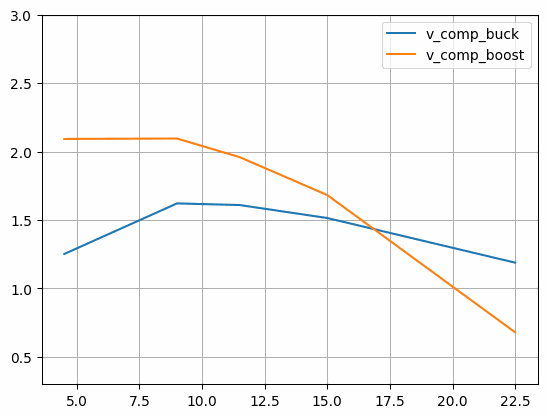

In [4]:
gm_slope = 2e-6  # datasheet
a_cs = 5  # datasheet
c_slope = gm_slope * L1 / (r_sense * a_cs)
print(f"c_slope calculated: {c_slope*1e9:.3f} nF")

c_slope = 0.33e-9 # choose smaller for noise immunity. check below if ok based on v_comp range
print(f"c_slope chosen: {c_slope*1e9:.3f} nF")

# need to check what value to use still. effect on noise immunity in buck boost transition and input output range
D_buck = v_out / input_voltage_operating_points
v_comp_buck = (
    1.6
    - a_cs * r_sense * v_out / (2 * L1 * f_sw) * (1 - D_buck)
    - (2e-6 * (input_voltage_operating_points - v_out) + 6e-6)
    / (c_slope * f_sw)
    * (1 - D_buck)
)
print(f"v_comp_buck: {v_comp_buck[-1]:.3f} V")

D_boost = 1 - input_voltage_operating_points / v_out
v_comp_boost = (
    1.6
    + a_cs
    * r_sense
    * (
        i_out_operating_points * v_out / input_voltage_operating_points
        + input_voltage_operating_points / (2 * L1 * f_sw) * D_boost
    )
    + (2e-6 * (v_out - input_voltage_operating_points) + 5e-6)
    / (c_slope * f_sw)
    * (1 - D_boost)
)

print(f"v_comp_boost: {v_comp_boost[0]:.3f} V")
plt.plot(input_voltage_operating_points, v_comp_buck, label = "v_comp_buck")
plt.plot(input_voltage_operating_points, v_comp_boost, label = "v_comp_boost")
plt.grid()
plt.ylim([0.3,3])
plt.legend()

# ok, since v_comp within 0.3V to 3V per datasheet

## UVLO divider (historical)

> **Superseded:** these divider studies led to the TLV431 + lockout-latch solution now designed in `uvlo/10a_uvlo_resistor_search.py` / `uvlo/uvlo_tlv431.tex`. Kept for the reasoning trail.

In [5]:
delta_i_hys_op = np.asarray([2.15e-6, 3.15e-6, 4.25e-6]) # datasheet

tol = 0.015
r_uv2 = 249e3 #
r_uv2 = 300e3 * (1+tol)#
delta_v_hys_uv = delta_i_hys_op * r_uv2

print(delta_v_hys_uv)

i_en_stby = np.asarray([1e-6, 2e-6, 3e-6]) # datasheet
v_en_op = np.asarray([1.17, 1.22, 1.29]) # datasheet
r_uv1 = 100e3 * (1-tol)
v_in_uv = v_en_op * (1 + r_uv2 / r_uv1) -  r_uv2 * i_en_stby
print(v_in_uv) #rough range, just checking typical value ok for 5V usb with 500mV drop

[0.654675 0.959175 1.294125]
[4.48240355 4.38247208 4.36436802]


--- AIR PURIFIER UVLO REPORT (4-SIGMA @ ΔT=35°C) ---
Resistor R1: 120.0k (1.35% eff. tol)
Resistor R2: 330.0k (1.35% eff. tol)
----------------------------------------------------------
Turn-ON  Threshold: 3.91V (4-sigma Range: 3.49V - 4.33V)
Turn-OFF Threshold: 2.88V (4-Sigma Shutdown: 2.33V - 3.42V)
Hysteresis: 1.04V (4-Sigma Hysteresis: 0.69V - 1.39V)
VERDICT: PASS - Device guaranteed to start on 4.5V USB.


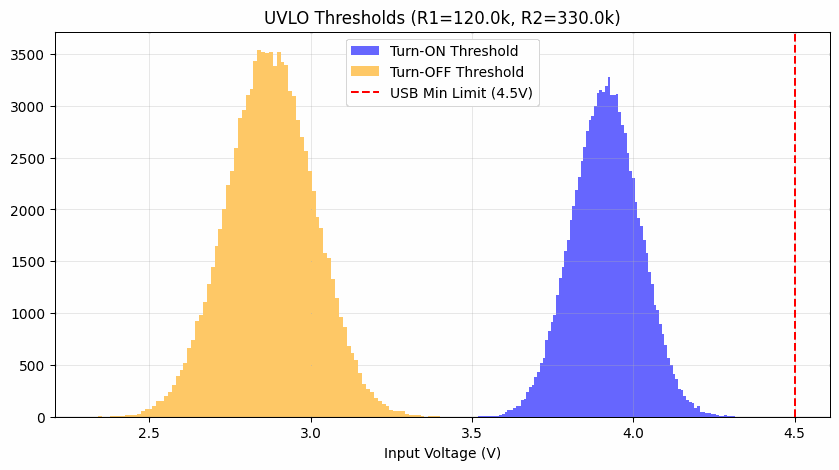

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, truncnorm
from constants import MFG  # Assuming constants.py is in the same folder

# --- CONFIGURATION ---
samples = 100000
sigma_level = 4
delta_t = 35  # Operating temperature rise (e.g., 60°C internal - 25°C ambient)

# --- HELPER FUNCTION FOR DYNAMIC TOLERANCE ---
def get_effective_tolerance(nominal_value, d_t):
    # Lookup PPM from MFG, default to 100 if not in outliers
    ppm = MFG.RES_PPM_MAPPING.get(nominal_value, 100)
    temp_drift = (ppm * 1e-6) * d_t
    return MFG.BASE_TOLERANCE + temp_drift

# --- COMPONENT SELECTION ---
r1nom = 120e3  # Choose from MFG.BASIC_0603_RESISTORS
r2nom = 330e3

# Calculate dynamic tolerances based on MFG data
tol_r1 = get_effective_tolerance(r1nom, delta_t)
tol_r2 = get_effective_tolerance(r2nom, delta_t)

# --- IC DATA ---
def get_truncated_normal(mean=0, sd=1, low=0, upp=10):
    # truncnorm takes standardized bounds (relative to mean and sd)
    return truncnorm(
        (low - mean) / sd, (upp - mean) / sd, loc=mean, scale=sd)

# Generate samples
gen = get_truncated_normal(mean=1.22, sd=(1.29 - 1.17) / (1 * sigma_level), low=1.17, upp=1.29)
v_en = gen.rvs(samples)
gen = get_truncated_normal(mean=2e-6, sd=(3e-6 - 1e-6) / (1 * sigma_level), low=1e-6, upp=3e-6)
i_stby = gen.rvs(samples)
gen = get_truncated_normal(mean=3.15e-6, sd=(4.25e-6 - 2.15e-6) / (2 * sigma_level), low=2.15e-6, upp=4.25e-6)
i_hys = gen.rvs(samples)

# --- RESISTORS (Using MFG-derived tolerances) ---
# We use uniform distribution for resistor manufacturing tolerance
r1 = np.random.uniform(r1nom * (1 - tol_r1), r1nom * (1 + tol_r1), samples)
r2 = np.random.uniform(r2nom * (1 - tol_r2), r2nom * (1 + tol_r2), samples)

# --- CALCULATIONS ---
v_start = v_en * (1 + r2 / r1) - (r2 * i_stby)
v_stop = v_start - (i_hys * r2)
v_hysteresis = i_hys * r2

# --- STATS CALCULATION ---
mean_on, std_on = np.mean(v_start), np.std(v_start)
mean_off, std_off = np.mean(v_stop), np.std(v_stop)
mean_hysteresis, std_hysteresis = np.mean(v_hysteresis), np.std(v_hysteresis)

v_on_max_4sig = mean_on + 4 * std_on
v_on_min_4sig = mean_on - 4 * std_on
v_off_min_4sig = mean_off - 4 * std_off
v_off_max_4sig = mean_off + 4 * std_off
v_hysteresis_max_4sig = mean_hysteresis + 4 * std_hysteresis
v_hysteresis_min_4sig = mean_hysteresis - 4 * std_hysteresis

# Failure Probability Calculation
z_score = (4.5 - mean_on) / std_on
fail_prob = norm.sf(z_score) 

# --- REPORT ---
print(f"--- AIR PURIFIER UVLO REPORT (4-SIGMA @ ΔT={delta_t}°C) ---")
print(f"Resistor R1: {r1nom/1000}k ({tol_r1*100:.2f}% eff. tol)")
print(f"Resistor R2: {r2nom/1000}k ({tol_r2*100:.2f}% eff. tol)")
print(f"----------------------------------------------------------")
print(f"Turn-ON  Threshold: {mean_on:.2f}V (4-sigma Range: {v_on_min_4sig:.2f}V - {v_on_max_4sig:.2f}V)")
print(f"Turn-OFF Threshold: {mean_off:.2f}V (4-Sigma Shutdown: {v_off_min_4sig:.2f}V - {v_off_max_4sig:.2f}V)")
print(f"Hysteresis: {mean_hysteresis:.2f}V (4-Sigma Hysteresis: {v_hysteresis_min_4sig:.2f}V - {v_hysteresis_max_4sig:.2f}V)")

if v_on_max_4sig < 4.5:
    print("VERDICT: PASS - Device guaranteed to start on 4.5V USB.")
else:
    print(f"VERDICT: FAIL - Estimated {fail_prob*100:.4f}% failure rate.")

# --- PLOT ---
plt.figure(figsize=(10, 5))
plt.hist(v_start, bins=100, alpha=0.6, label='Turn-ON Threshold', color='blue')
plt.hist(v_stop, bins=100, alpha=0.6, label='Turn-OFF Threshold', color='orange')
#plt.hist(v_hysteresis, bins=100, alpha=0.6, label='Hysteresis', color='red')
plt.axvline(4.5, color='red', linestyle='--', label='USB Min Limit (4.5V)')
plt.title(f"UVLO Thresholds (R1={r1nom/1000}k, R2={r2nom/1000}k)")
plt.xlabel("Input Voltage (V)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
import numpy as np
from constants import MFG

# --- USER TARGETS ---
USB_LIMIT = 4.5        # Must turn on below this
V_OFF_FLOOR = 3.3      # Must not drop below this (example)
V_ON_FLOOR = 3.5
MIN_HYS_GAP = 0.2     # Volts
MAX_POWER_W = 0.0005   # 0.5mW limit at 5V
DELTA_T = 35           # Temp rise

def run_optimizer():
    results = []
    samples = 10000
    sigma_level = 6
    
    # Nested loop through all Basic resistors
    # R2 is Top, R1 is Bottom per your formula
    for r2_nom in MFG.BASIC_0603_RESISTORS:
        for r1_nom in MFG.BASIC_0603_RESISTORS:
            
            # 1. Quick Power Check (Nominal 5V)
            p_nom = (5.0**2) / (r1_nom + r2_nom)
            if p_nom > MAX_POWER_W:
                continue
            
            # 2. Get Effective Tolerances
            tol_r1 = get_effective_tolerance(r1_nom, DELTA_T)
            tol_r2 = get_effective_tolerance(r2_nom, DELTA_T)
            
            # 3. Perform Mini-Monte Carlo (or use Worst-Case Math)
            # For speed in a loop, we can use 4-sigma analytical math:
            # Var(V_start) approx propagation of error... 
            # Or just run a 10k sample Monte Carlo:
            
            v_en = np.random.normal(1.22, (1.29 - 1.17) / (2 * sigma_level), samples)
            i_stby = np.random.normal(2e-6, (3e-6 - 1e-6) / (2 * sigma_level), samples)
            i_hys = np.random.normal(3.15e-6, (4.25e-6 - 2.15e-6) / (2 * sigma_level), samples)
            
            r1 = np.random.uniform(r1_nom*(1-tol_r1), r1_nom*(1+tol_r1), samples)
            r2 = np.random.uniform(r2_nom*(1-tol_r2), r2_nom*(1+tol_r2), samples)
            
            v_on = v_en * (1 + r2/r1) - (r2 * i_stby)
            v_off = v_on - (i_hys * r2)
            hysteresis = i_hys * r2

            v_on_max_4sig = np.mean(v_on) + 4 * np.std(v_on)
            v_off_min_4sig = np.mean(v_off) - 4 * np.std(v_off)
            v_hysteresis_min_4sig = np.mean(hysteresis) - 4 * np.std(hysteresis)

            # 4. Filter against Constraints
            if v_on_max_4sig < USB_LIMIT and v_off_min_4sig > V_OFF_FLOOR and v_hysteresis_min_4sig > MIN_HYS_GAP:
                results.append({
                    'R2_k': r2_nom/1e3,
                    'R1_k': r1_nom/1e3,
                    'V_ON_MAX': v_on_max_4sig,
                    'V_OFF_MIN': v_off_min_4sig,
                    'V_HYSTERESIS_MIN': v_hysteresis_min_4sig,
                    'Power_uW': p_nom * 1e6
                })
                
    return results

# Run it and sort by most hysteresis or lowest power
candidates = run_optimizer()
# Sort by lowest power consumption
candidates.sort(key=lambda x: x['Power_uW'])

print(f"Found {len(candidates)} valid combinations.")
for c in candidates[:50]: # Show top 5
    print(f"R2: {c['R2_k']}k, R1: {c['R1_k']}k | Max ON: {c['V_ON_MAX']:.2f}V | Min OFF: {c['V_OFF_MIN']:.2f}V | Min Hysteresis: {c['V_HYSTERESIS_MIN']:.2f}V | P: {c['Power_uW']:.1f}uW")

Found 5 valid combinations.
R2: 150.0k, R1: 56.0k | Max ON: 4.41V | Min OFF: 3.47V | Min Hysteresis: 0.37V | P: 121.4uW
R2: 120.0k, R1: 49.9k | Max ON: 4.11V | Min OFF: 3.32V | Min Hysteresis: 0.29V | P: 147.1uW
R2: 120.0k, R1: 47.0k | Max ON: 4.30V | Min OFF: 3.50V | Min Hysteresis: 0.29V | P: 149.7uW
R2: 100.0k, R1: 39.0k | Max ON: 4.36V | Min OFF: 3.62V | Min Hysteresis: 0.24V | P: 179.9uW
R2: 82.0k, R1: 36.0k | Max ON: 4.02V | Min OFF: 3.39V | Min Hysteresis: 0.20V | P: 211.9uW


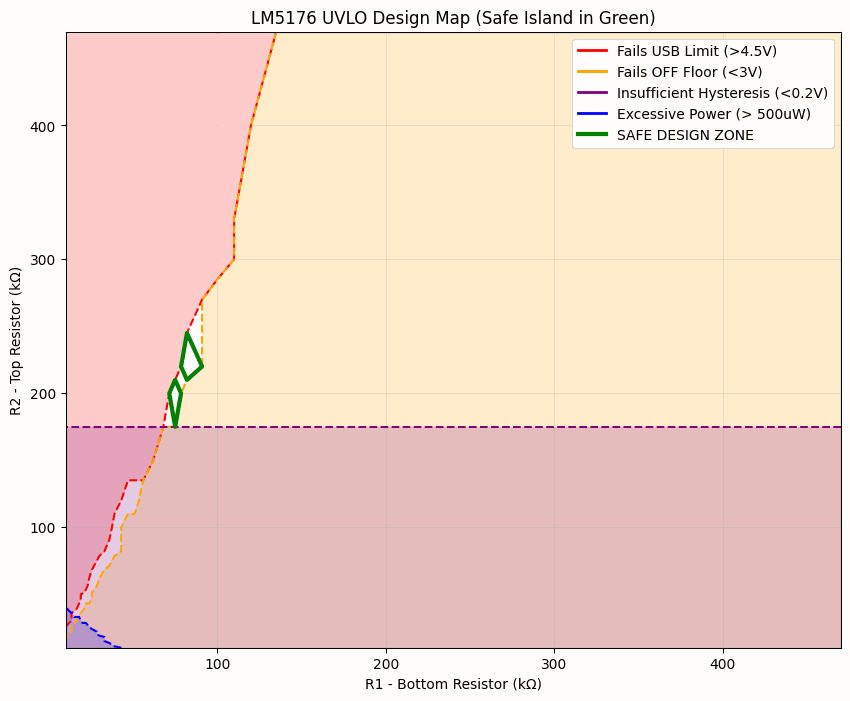

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from constants import MFG

# --- SETTINGS ---
V_USB_MIN = 4.5
V_ON_FLOOR = 3.5
V_OFF_FLOOR = 3
MIN_HYS_GAP = 0.2
MAX_POWER_UW = 500
DELTA_T = 35

# 1. Prepare Grid (using your Basic Resistor list)
# We filter the list to a relevant range to keep the plot clean
res_list = MFG.BASIC_0603_RESISTORS
res_list = res_list[(res_list >= 10e3) & (res_list <= 500e3)] 

R1_mesh, R2_mesh = np.meshgrid(res_list, res_list)

# 2. Vectorized Math (Analytical 4-Sigma for speed)
# We use analytical approx here to avoid 100k samples per grid point
v_en_m, v_en_s = 1.22, (1.29 - 1.17) / 12  # Mean, StdDev
i_stby_m, i_stby_s = 2e-6, 0.5e-6
i_hys_m, i_hys_s = 3.15e-6, 0.5e-6

# Effective tolerances from your function
# (Simplified here as a constant for the mesh visualization)
tol = 0.0135 

# NOMINAL VALUES
V_ON_NOM = v_en_m * (1 + R2_mesh/R1_mesh) - (R2_mesh * i_stby_m)
V_OFF_NOM = V_ON_NOM - (i_hys_m * R2_mesh)

# 4-SIGMA BOUNDS (Simplified Error Propagation)
# This estimates the "spread" of the thresholds
V_ON_MAX = V_ON_NOM + 4 * 0.08  # Approx 80mV std dev
V_OFF_MIN = V_OFF_NOM - 4 * 0.08
HYS_MIN = (i_hys_m - 4*i_hys_s) * (R2_mesh * (1-tol))

# 3. Define Failure Masks
fail_on    = V_ON_MAX > V_USB_MIN
fail_off   = V_OFF_MIN < V_OFF_FLOOR
fail_hys   = HYS_MIN < MIN_HYS_GAP
fail_power = (5.0**2 / (R1_mesh + R2_mesh)) * 1e6 > MAX_POWER_UW

# 4. Plotting
plt.figure(figsize=(10, 8))

# Plot failure regions
plt.contourf(R1_mesh/1e3, R2_mesh/1e3, fail_on, levels=[0.5, 1], colors=['red'], alpha=0.2)
plt.contour(R1_mesh/1e3, R2_mesh/1e3, fail_on, colors='red', linestyles='--')

plt.contourf(R1_mesh/1e3, R2_mesh/1e3, fail_off, levels=[0.5, 1], colors=['orange'], alpha=0.2)
plt.contour(R1_mesh/1e3, R2_mesh/1e3, fail_off, colors='orange', linestyles='--')

plt.contourf(R1_mesh/1e3, R2_mesh/1e3, fail_hys, levels=[0.5, 1], colors=['purple'], alpha=0.2)
plt.contour(R1_mesh/1e3, R2_mesh/1e3, fail_hys, colors='purple', linestyles='--')

plt.contourf(R1_mesh/1e3, R2_mesh/1e3, fail_power, levels=[0.5, 1], colors=['blue'], alpha=0.2)
plt.contour(R1_mesh/1e3, R2_mesh/1e3, fail_power, colors='blue', linestyles='--')

# Highlight the "Safe Island"
safe_mask = ~(fail_on | fail_off | fail_hys | fail_power)
plt.contour(R1_mesh/1e3, R2_mesh/1e3, safe_mask, levels=[0.5], colors='green', linewidths=3)

# Labeling
plt.title("LM5176 UVLO Design Map (Safe Island in Green)")
plt.xlabel("R1 - Bottom Resistor (kΩ)")
plt.ylabel("R2 - Top Resistor (kΩ)")
plt.grid(True, which='both', alpha=0.3)

# Legend Proxy
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Fails USB Limit (>4.5V)'),
    Line2D([0], [0], color='orange', lw=2, label=f'Fails OFF Floor (<{V_OFF_FLOOR}V)'),
    Line2D([0], [0], color='purple', lw=2, label=f'Insufficient Hysteresis (<{MIN_HYS_GAP}V)'),
    Line2D([0], [0], color='blue', lw=2, label=f'Excessive Power (> {MAX_POWER_UW}uW)'),
    Line2D([0], [0], color='green', lw=3, label='SAFE DESIGN ZONE')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.show()

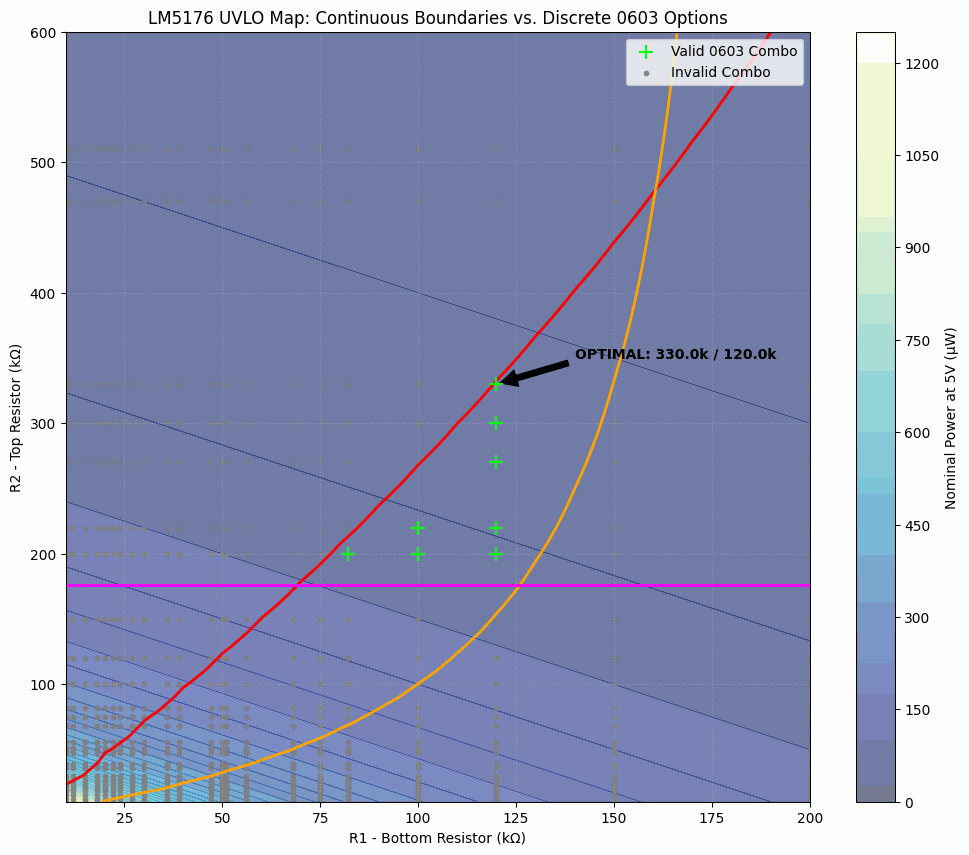

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from constants import MFG

# --- SETTINGS ---
V_USB_MIN = 4.5 # must turn on/at this voltage or lower since usb might not give more than 4.5V
V_USB_MAX = 22.5 # must still stay latched even if vin rises this high if vout not fallen yet
V_ON_FLOOR = 3.8 # must not turn on unless vin higher than this. rough based on 2.6v mosfet plateau voltage
V_OFF_FLOOR = 2 # turn off managed by external latch circuit if vout is high, but if vout is low, we should turn off if vin drops. this must also be lower than the latch circuit threshold since if vout is high, we want it to latch before ic would turn off by itself without latching
V_OFF_LATCH_FLOOR = 3 # when vout is on, off floor is 3v, this shuold be higher than ic's off floor so that we always latch, not just turn off by ic
MIN_HYS_GAP = 0.2 # min hystersis to prevent chatter during turn on while vout is low, ie voff max. from on to off non-latching.
LATCH_TO_IC_OFF_GAP = 0.1 #ensure latch always latches before ic would have turned off by normally looking at en/uvlo 
LATCH_TO_IC_ON_GAP = 0.1 # make sure that latch wont be latching if ic turns on and starts increasing the output. ie, 3.8v vin ic on, vout rises. we want to make sure latch wont think vin is too low and latch en/uvlo as soon as vout is on..
LATCH_VOUT_THRESH_CEIL = 2 # make sure vout is fully off before letting ic turn back on. 2V arbitrary. higher is risky since energy on output still might cause too much backfeed. lower the better
LATCH_VOUT_THRESH_FLOOR = 0 # not sur if needed
MAX_POWER_UW = 500 # arbitrary power limit. lower the better. dcdc approximately has 0.1W to 1W loss
DELTA_T = 35 # temp change for tolerance calculations

# --- SETUP ---
# High-resolution mesh for smooth curves
res_fine = np.linspace(10e3, 1000e3, 100) 
R1_mesh, R2_mesh = np.meshgrid(res_fine, res_fine)

# Discrete available resistors from your library
avail = MFG.BASIC_0603_RESISTORS
avail = avail[(avail >= 10e3) & (avail <= 1000e3)]

# --- PHYSICS ENGINE (Vectorized) ---
v_en_m, v_en_s = 1.22, (1.29 - 1.17) / 4
i_hys_m, i_hys_s = 3.15e-6, 0.5e-6
i_stby_m = 2e-6
tol = 0.0135

# Worst-case analytical boundaries
V_ON_MAX = (v_en_m + 4*v_en_s) * (1 + (R2_mesh*(1+tol))/(R1_mesh*(1-tol))) - (R2_mesh*(1-tol)*i_stby_m)
V_OFF_MIN = V_ON_MAX - ((i_hys_m + 4*i_hys_s) * R2_mesh * (1+tol))
HYS_MIN = (i_hys_m - 4*i_hys_s) * (R2_mesh * (1-tol))
Power_uW = (5.0**2 / (R1_mesh + R2_mesh)) * 1e6

# --- PLOTTING ---
plt.figure(figsize=(12, 10))

# 1. Background Power Gradient
cp = plt.contourf(R1_mesh/1e3, R2_mesh/1e3, Power_uW, levels=50, cmap='YlGnBu_r', alpha=0.6)
plt.colorbar(cp, label='Nominal Power at 5V (µW)')

# 2. Smooth Failure Boundaries
plt.contour(R1_mesh/1e3, R2_mesh/1e3, V_ON_MAX, levels=[V_USB_MIN], colors='red', linewidths=2)
plt.contour(R1_mesh/1e3, R2_mesh/1e3, V_OFF_MIN, levels=[V_OFF_FLOOR], colors='orange', linewidths=2)
plt.contour(R1_mesh/1e3, R2_mesh/1e3, HYS_MIN, levels=[MIN_HYS_GAP], colors='magenta', linewidths=2)

# 3. DISCRETE COMPONENT CROSSHAIRS
# Generate all possible pairs from your BASIC_0603_RESISTORS
r1_pts, r2_pts = np.meshgrid(avail, avail)
r1_flat = r1_pts.flatten()
r2_flat = r2_pts.flatten()

# Filter points to see which ones are actually "Safe"
# (Using the same logic as the mesh)
v_on_pts = (v_en_m + 4*v_en_s) * (1 + (r2_flat*(1+tol))/(r1_flat*(1-tol))) - (r2_flat*(1-tol)*i_stby_m)
v_off_pts = v_on_pts - ((i_hys_m + 4*i_hys_s) * r2_flat * (1+tol))
hys_pts = (i_hys_m - 4*i_hys_s) * (r2_flat * (1-tol))

is_safe = (v_on_pts < V_USB_MIN) & (v_off_pts > V_OFF_FLOOR) & (hys_pts > MIN_HYS_GAP)

# Plot valid combos as Green Crosshairs, invalid as small grey dots
plt.scatter(r1_flat[is_safe]/1e3, r2_flat[is_safe]/1e3, color='lime', marker='+', s=100, label='Valid 0603 Combo', zorder=5)
plt.scatter(r1_flat[~is_safe]/1e3, r2_flat[~is_safe]/1e3, color='grey', alpha=0.9, s=10, label='Invalid Combo')

# 4. Annotation of the "Golden Pair"
# Finding the combo with the highest R2 in the safe list for max hysteresis
# 4. Annotation of the "Golden Pair"
if np.any(is_safe):
    best_idx = np.argmax(r2_flat[is_safe])
    bx, by = r1_flat[is_safe][best_idx]/1e3, r2_flat[is_safe][best_idx]/1e3
    plt.annotate(f'OPTIMAL: {by}k / {bx}k', xy=(bx, by), xytext=(bx+20, by+20),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontweight='bold')
else:
    plt.text(50, 150, "NO VALID COMBOS FOUND\nLoosen constraints!", 
             color='red', fontsize=14, fontweight='bold', ha='center')
    
#best_idx = np.argmax(r2_flat[is_safe])
#bx, by = r1_flat[is_safe][best_idx]/1e3, r2_flat[is_safe][best_idx]/1e3
#plt.annotate(f'OPTIMAL: {by}k / {bx}k', xy=(bx, by), xytext=(bx+20, by+20),
#             arrowprops=dict(facecolor='black', shrink=0.05), fontweight='bold')

plt.title("LM5176 UVLO Map: Continuous Boundaries vs. Discrete 0603 Options")
plt.xlabel("R1 - Bottom Resistor (kΩ)")
plt.ylabel("R2 - Top Resistor (kΩ)")
plt.xlim(10, 200)
plt.ylim(10, 600)
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.show()

## Soft start

Charge the output caps at least as slowly as the nominal maximum output current; 1 µF chosen.

In [10]:
print(f"{1:0.1f} uF, chosen capacitor")
# i = c dvdt
# assume max output, what dv/dtc_out_chosen_derated
dvdt = max(i_out_operating_points) / c_out_chosen_nominal
time = v_out / dvdt

print(f"time to charge output cap: {time*1e3:0.1f} ms")
vref = 0.8
iss = np.asarray([3.75, 5, 6.35])*1e-6
css = 1e-6
tss = css * vref / iss
print([f"{tss*1e3:0.1f} ms" for tss in tss])

1.0 uF, chosen capacitor
time to charge output cap: 80.6 ms
['213.3 ms', '160.0 ms', '126.0 ms']


## Switching frequency (RT/SYNC)

In [11]:
r_t = (1/f_sw - 190e-9) / 116e-12
print(f"{r_t*1e-3:0.1f} kOhm")
print(f"{82:0.1f} kOhm, chosen 5% resistor")

84.6 kOhm
82.0 kOhm, chosen 5% resistor


## Dither capacitor (not implemented; 0 Ω to ground)

In [12]:
# not implemented, populated wiht 0 Ohm resistor to ground
f_mod = 500
c_dith = 10e-6 / (f_mod * 0.24)
print(f"{c_dith*1e9:0.1f} nF")

83.3 nF


## VCC bypass

1 µF on VCC (≈8 V rail): 16 V X7R 0603, e.g. KEMET C0603C105K4RACTU.

## MOSFETs

Selected in notebook 04 (BSC0902NS).

## Frequency compensation

Power-stage poles/zeros across the operating envelope, then compensator design.

In [13]:
r_out = v_out / i_out_operating_points
print(r_out)
R_OUT = v_out / I_OUT
print(R_OUT)
f_p1_boost = 1 / 2 / np.pi * (2 / (r_out * c_out_chosen_derated))
f_z1 =  1 / 2 / np.pi * (2 / (r_esr * c_out_chosen_derated))
D_max_boost = 1 - min(input_voltage_operating_points) / v_out
f_rhp_boost = 1 / 2 / np.pi * (r_out * (1 - D_max_boost) ** 2) / L1
f_p1_buck = 1 / 2 / np.pi * (1 / (r_out * c_out_chosen_derated))
gm_ea = 1.31e-3
r_out_ea = 20e6
a_cs = 5

print(f"f_p1_boost: {min(f_p1_boost):.1f} to {max(f_p1_boost):.1f} Hz")
print(f"f_z1: {f_z1:.1f} Hz")
print(f"f_rhp_boost: {min(f_rhp_boost):.1f} to {max(f_rhp_boost):.1f} Hz")
print(f"f_p1_buck: {min(f_p1_buck):.1f} to {max(f_p1_buck):.1f} Hz")

f_bw = 11 # based on cout calculations. less than 1/10 of max commutation speed of about 160 Hz from the load waveform as sanity check. much lower than rhp so safe
f_zc = 1 # says to place 1.5 x boost pole, but later calculations say it should be much less than f_bw. maybe our f_bw being low is weird. also. f_z1 is quite low, not sure what that means
# actually we will place at 1hz since light load, output pole may be very low, say 0.3hz..
f_p1_boost = 1 / 2 / np.pi * (2 / (R_OUT * c_out_chosen_derated))
f_z1 =  1 / 2 / np.pi * (2 / (r_esr * c_out_chosen_derated))
D_max_boost = 1 - min(input_voltage_operating_points) / v_out
f_rhp_boost = 1 / 2 / np.pi * (R_OUT * (1 - D_max_boost) ** 2) / L1
f_p1_buck = 1 / 2 / np.pi * (1 / (R_OUT * c_out_chosen_derated))

print(f"f_p1_boost: {np.min(f_p1_boost):.1f} to {np.max(f_p1_boost):.1f} Hz")
print(f"f_z1: {f_z1:.1f} Hz")
print(f"f_rhp_boost: {np.min(f_rhp_boost):.1f} to {np.max(f_rhp_boost):.1f} Hz")
print(f"f_p1_buck: {np.min(f_p1_buck):.1f} to {np.max(f_p1_buck):.1f} Hz")
f_bw2 = 680
f_zc2 = 1

[6.4        3.42857143 3.42857143 3.42857143 3.42857143]
[[85.71428571 85.71428571 85.71428571 85.71428571 85.71428571]
 [13.71428571 13.71428571 13.71428571 13.71428571 13.71428571]
 [ 6.4         3.42857143  3.42857143  3.42857143  3.42857143]]
f_p1_boost: 3.8 to 7.1 Hz
f_z1: 1318.7 Hz
f_rhp_boost: 1632.7 to 3047.6 Hz
f_p1_buck: 1.9 to 3.5 Hz
f_p1_boost: 0.3 to 7.1 Hz
f_z1: 1318.7 Hz
f_rhp_boost: 1632.7 to 40816.7 Hz
f_p1_buck: 0.1 to 3.5 Hz


Nominal point: Vin=9.0V, Load=100.0%, R=3.4Ω, D=0.250
Nominal: f_p1=7.1Hz, f_z1=1318.7Hz, f_rhp=6530.7Hz, gain_dc=28.2dB


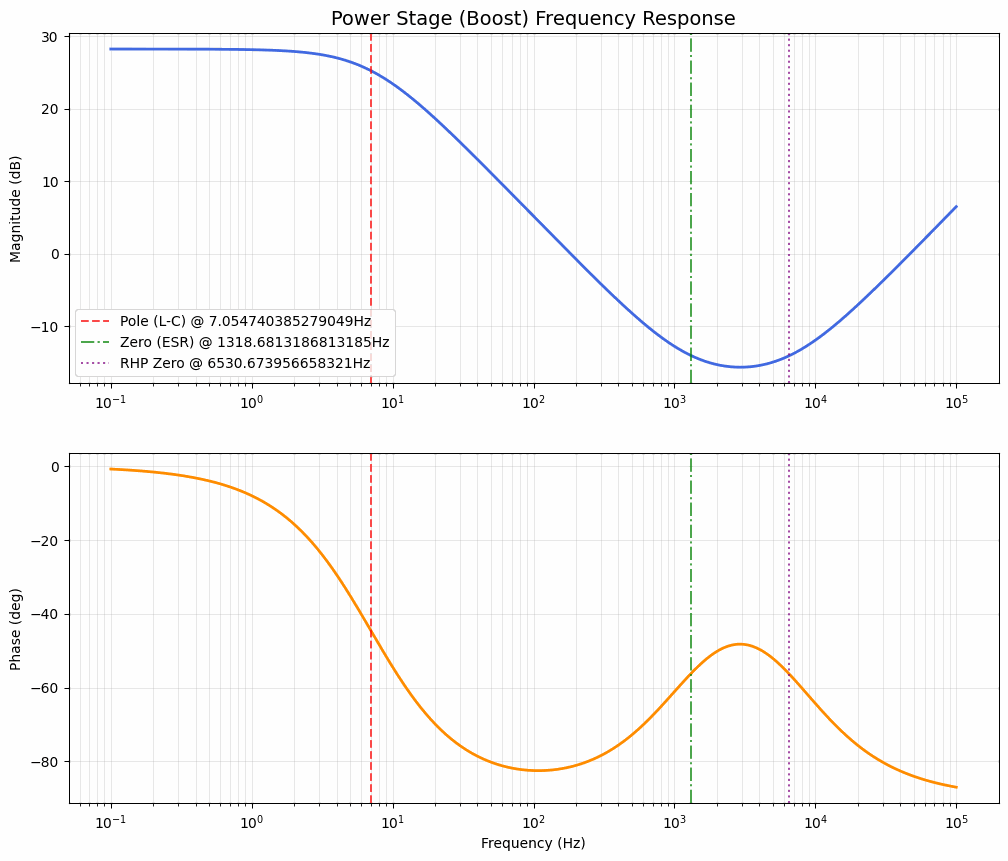

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- 1. System Constants ---
# Choose a nominal operating point for the single Bode plot
# Nominal: Vin = 9V (mid-boost), Full load (100%)
r_cs = r_sense #from previous section, 0.01ohm
a_cs = 5 #lm5176 datasheet
kd = 2  # slope compensation factor for boost

# Find the nominal operating point indices
vin_nominal = 9.0  # V (middle of boost range)
load_nominal = 1.0 # 100% load
vin_idx = np.where(np.isclose(v_in, vin_nominal))[0][0]
load_idx = np.where(np.isclose(load_ratios, load_nominal))[0][0]

# Extract nominal values
R_nom = R_OUT[load_idx, vin_idx]
D_nom = D_BOOST[load_idx, vin_idx]
print(f"Nominal point: Vin={v_in[vin_idx]}V, Load={load_ratios[load_idx]*100}%, R={R_nom:.1f}Ω, D={D_nom:.3f}")

# Calculate nominal DC gain
gain_dc_linear = R_nom * (1 - D_nom) / (r_cs * a_cs * kd)
gain_dc = 20 * np.log10(gain_dc_linear)  # Convert to dB

# Convert to rad/s for transfer function
wp1 = 2 / (R_nom * c_out_chosen_derated)  # Boost pole
wz1 = 2 * np.pi * f_z1  # ESR zero
wrhp = R_nom * (1-D_nom)**2 / L1  # RHP zero

print(f"Nominal: f_p1={wp1/2/np.pi:.1f}Hz, f_z1={wz1/2/np.pi:.1f}Hz, f_rhp={wrhp/2/np.pi:.1f}Hz, gain_dc={gain_dc:.1f}dB")

# Plant TF: G(s) = Gain * (1 + s/wz1) * (1 - s/wrhp) / (1 + s/wp1)
num = 10**(gain_dc/20) * np.polymul([1/wz1, 1], [-1/wrhp, 1])
den = [1/wp1, 1]
system = signal.TransferFunction(num, den)

# --- 2. Calculate Bode Data ---
# Custom frequency range to ensure we see the low-end pole
w_hz = np.logspace(-1, 5, 1000)
w, mag, phase = signal.bode(system, w=2*np.pi*w_hz)

# --- 3. Plotting ---
plt.figure(figsize=(12, 10))

# Magnitude Plot
plt.subplot(2, 1, 1)
plt.semilogx(w_hz, mag, color='royalblue', linewidth=2)
plt.title('Power Stage (Boost) Frequency Response', fontsize=14)
plt.ylabel('Magnitude (dB)')
plt.grid(True, which="both", alpha=0.3)

# Phase Plot
plt.subplot(2, 1, 2)
plt.semilogx(w_hz, phase, color='darkorange', linewidth=2)
plt.ylabel('Phase (deg)')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", alpha=0.3)

# --- 4. Annotations ---
features = {
    'Pole (L-C)': (wp1/2/np.pi, 'red', 'dashed'),
    'Zero (ESR)': (wz1/2/np.pi, 'green', 'dashdot'),
    'RHP Zero': (wrhp/2/np.pi, 'purple', 'dotted')
}

for label, (freq, color, style) in features.items():
    # Add vertical lines to both plots
    for ax in [1, 2]:
        plt.subplot(2, 1, ax)
        plt.axvline(freq, color=color, linestyle=style, alpha=0.7, label=f'{label} @ {freq}Hz')
    
    # Add text label to Magnitude plot
plt.subplot(2, 1, 1)
plt.legend()

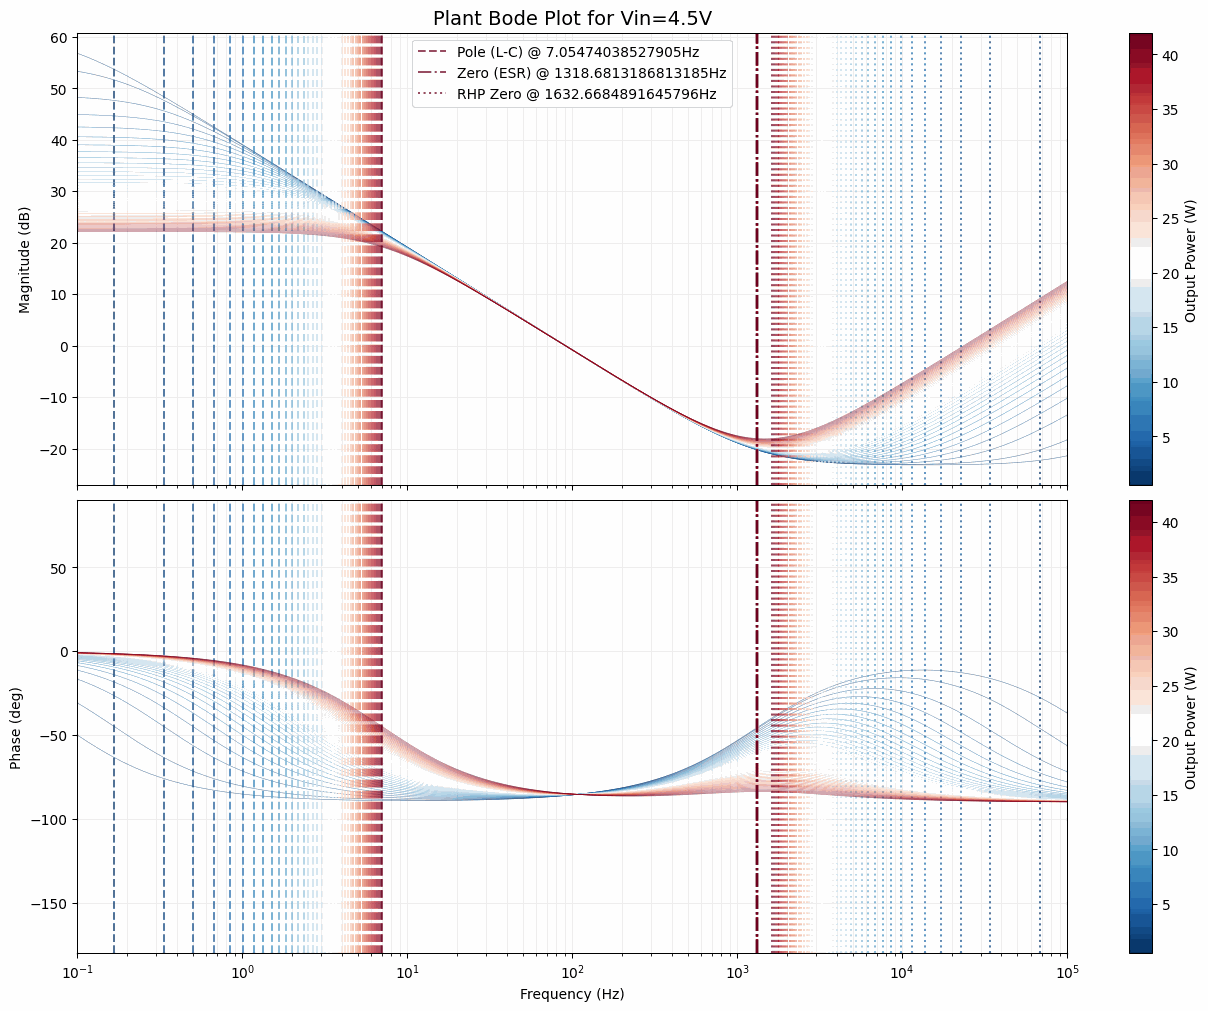

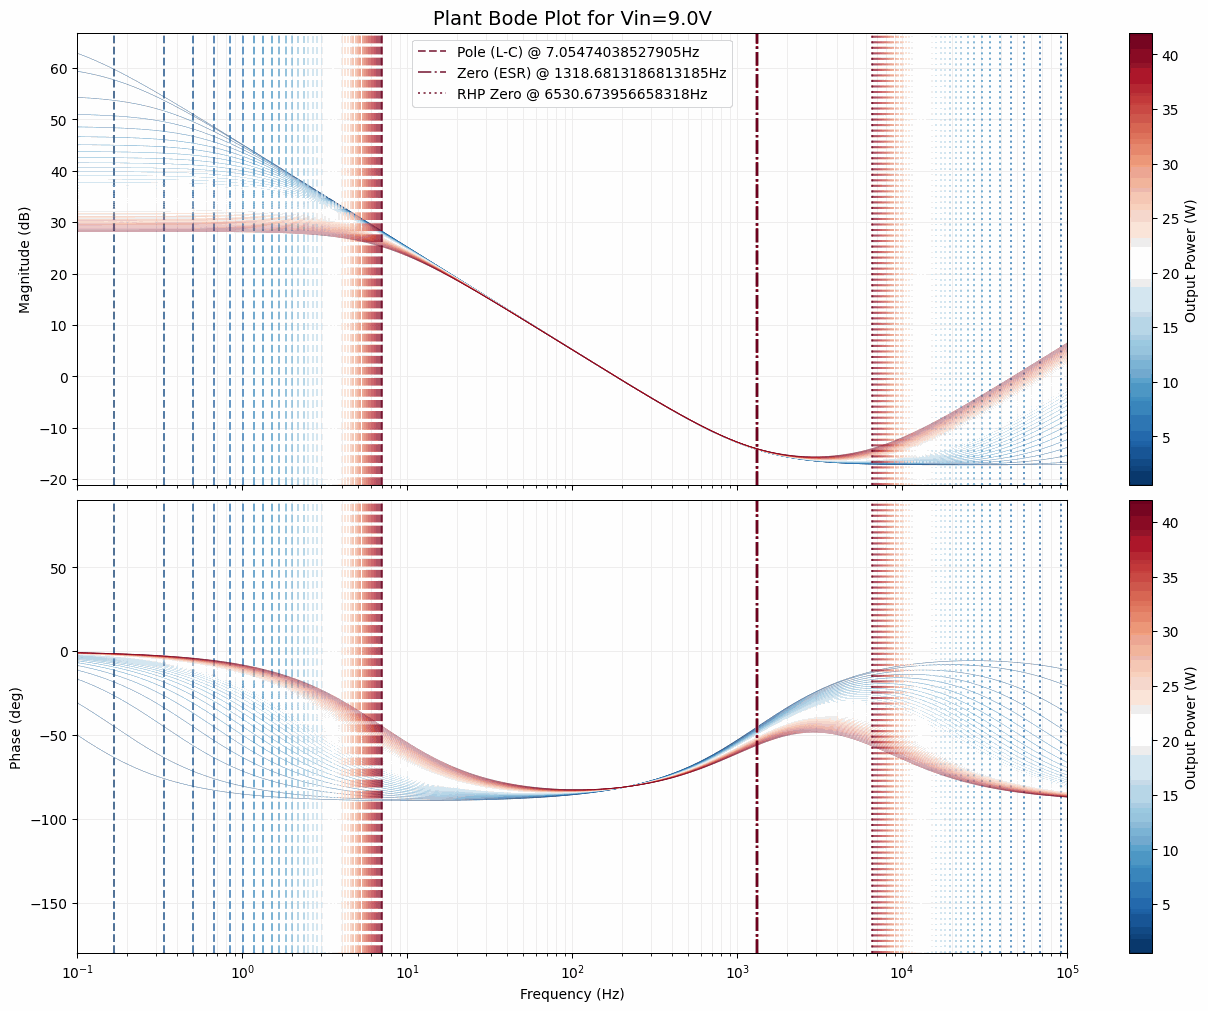

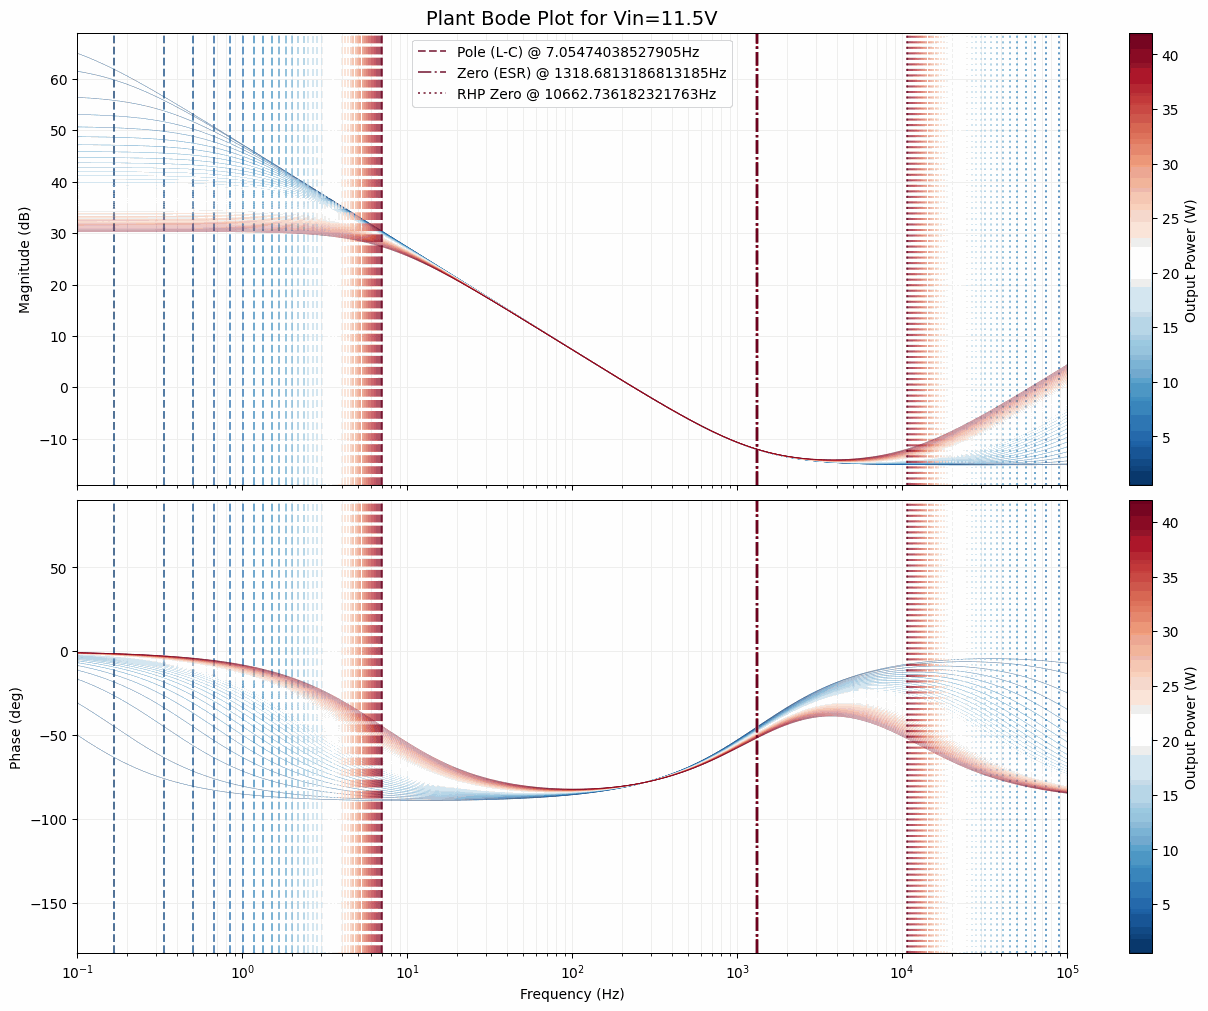

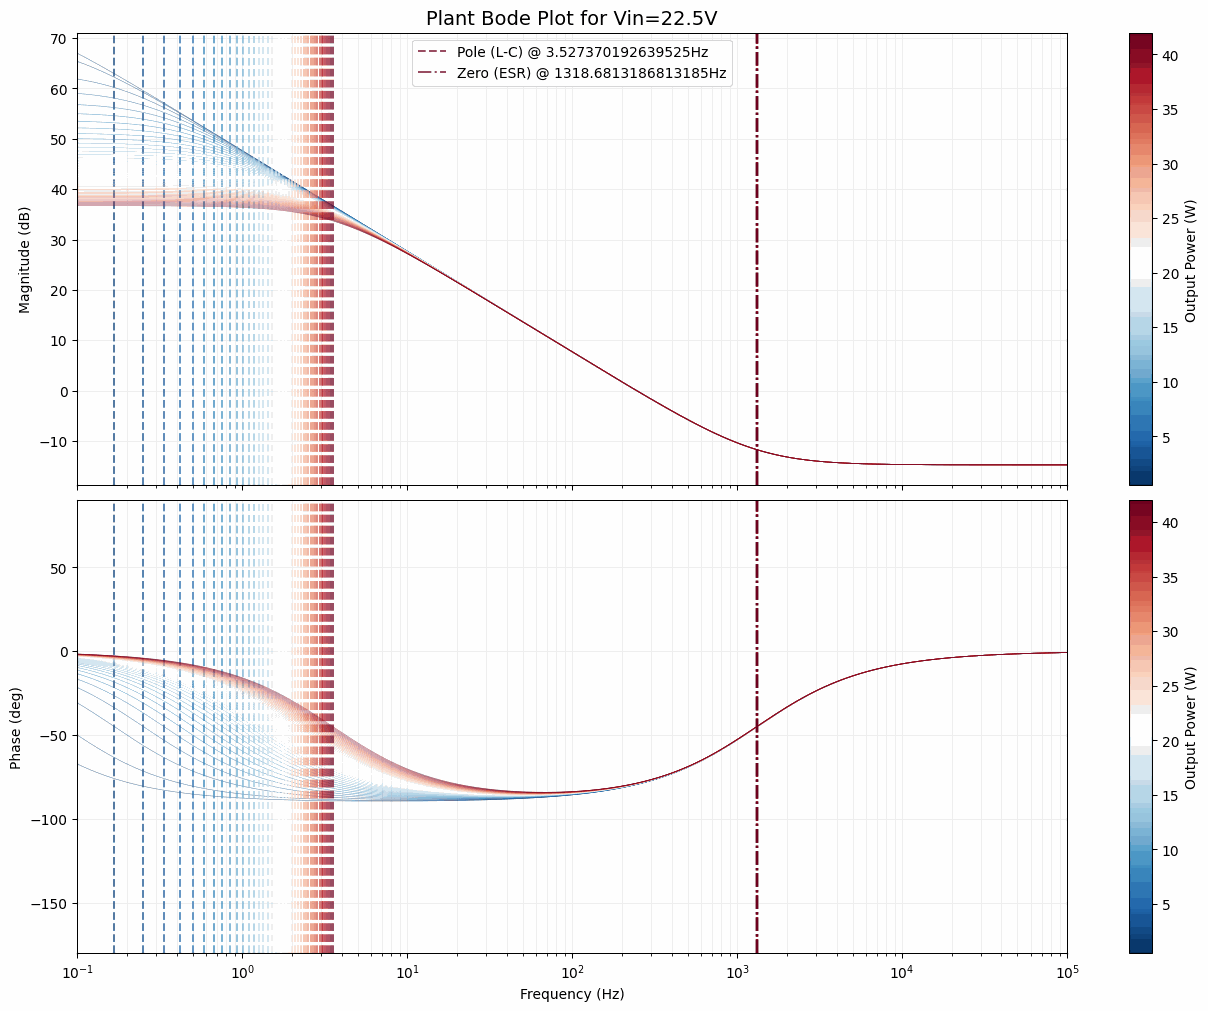

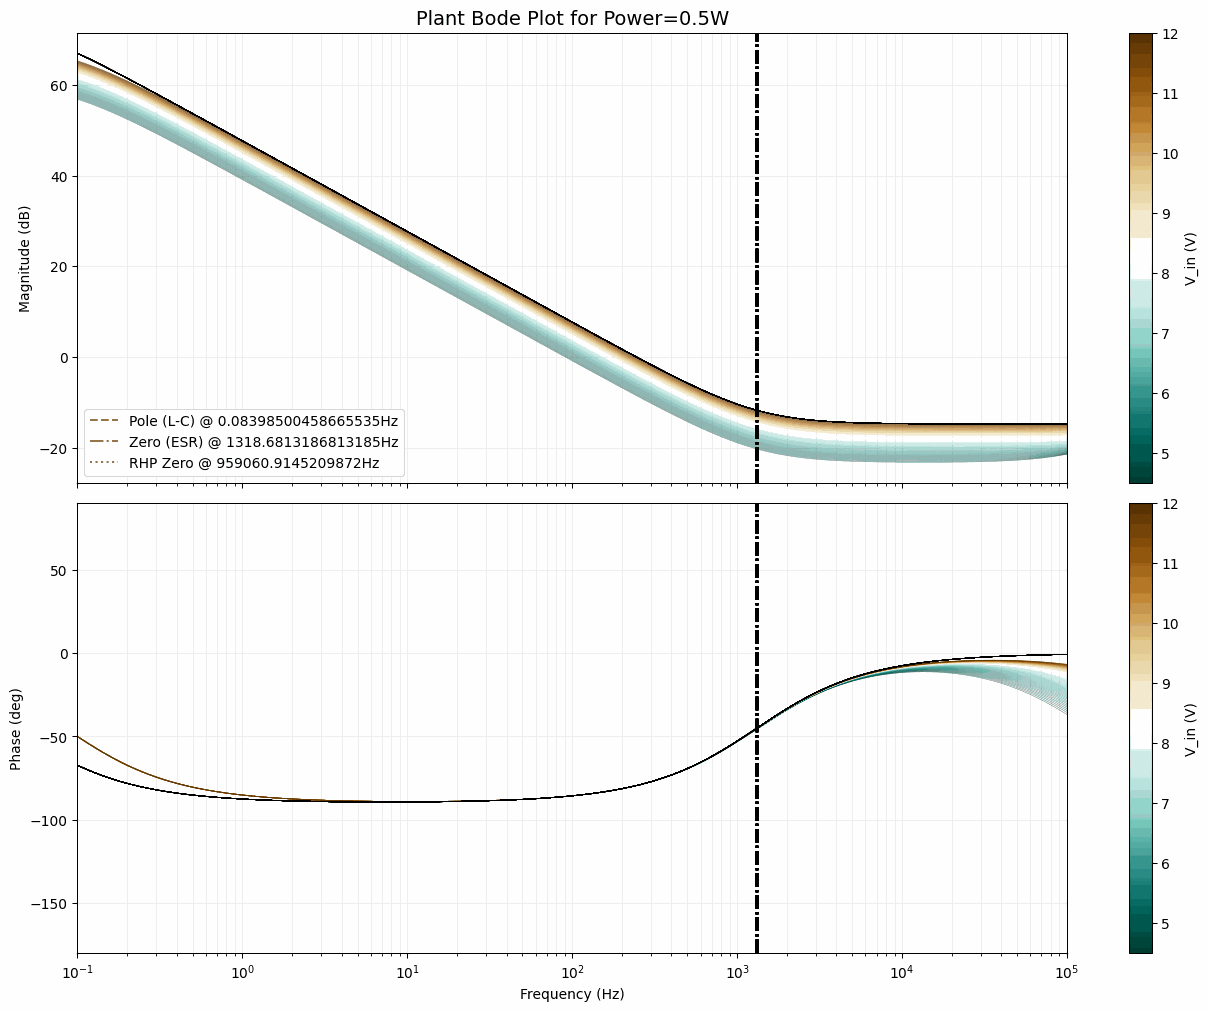

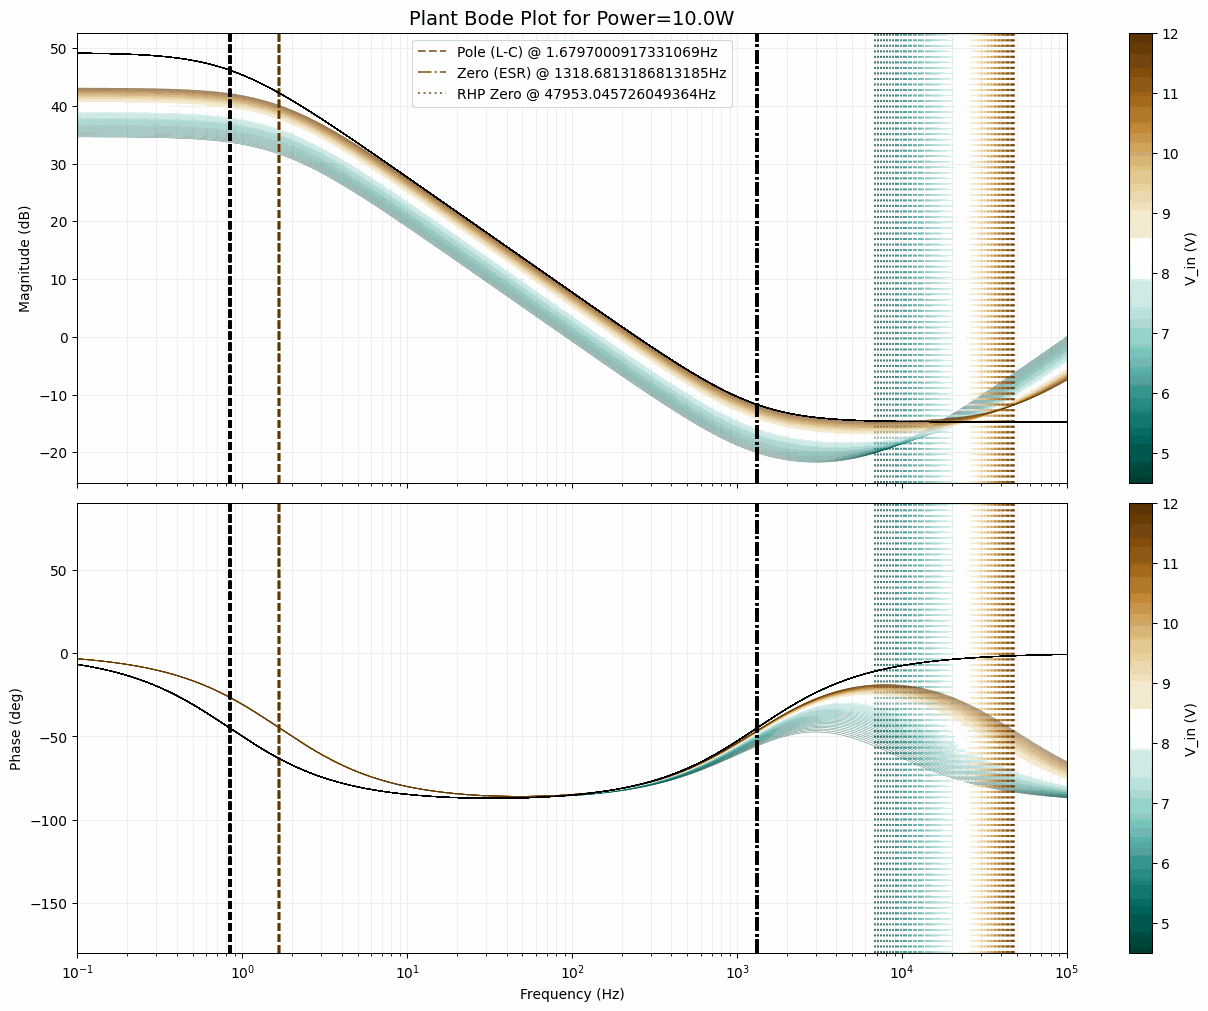

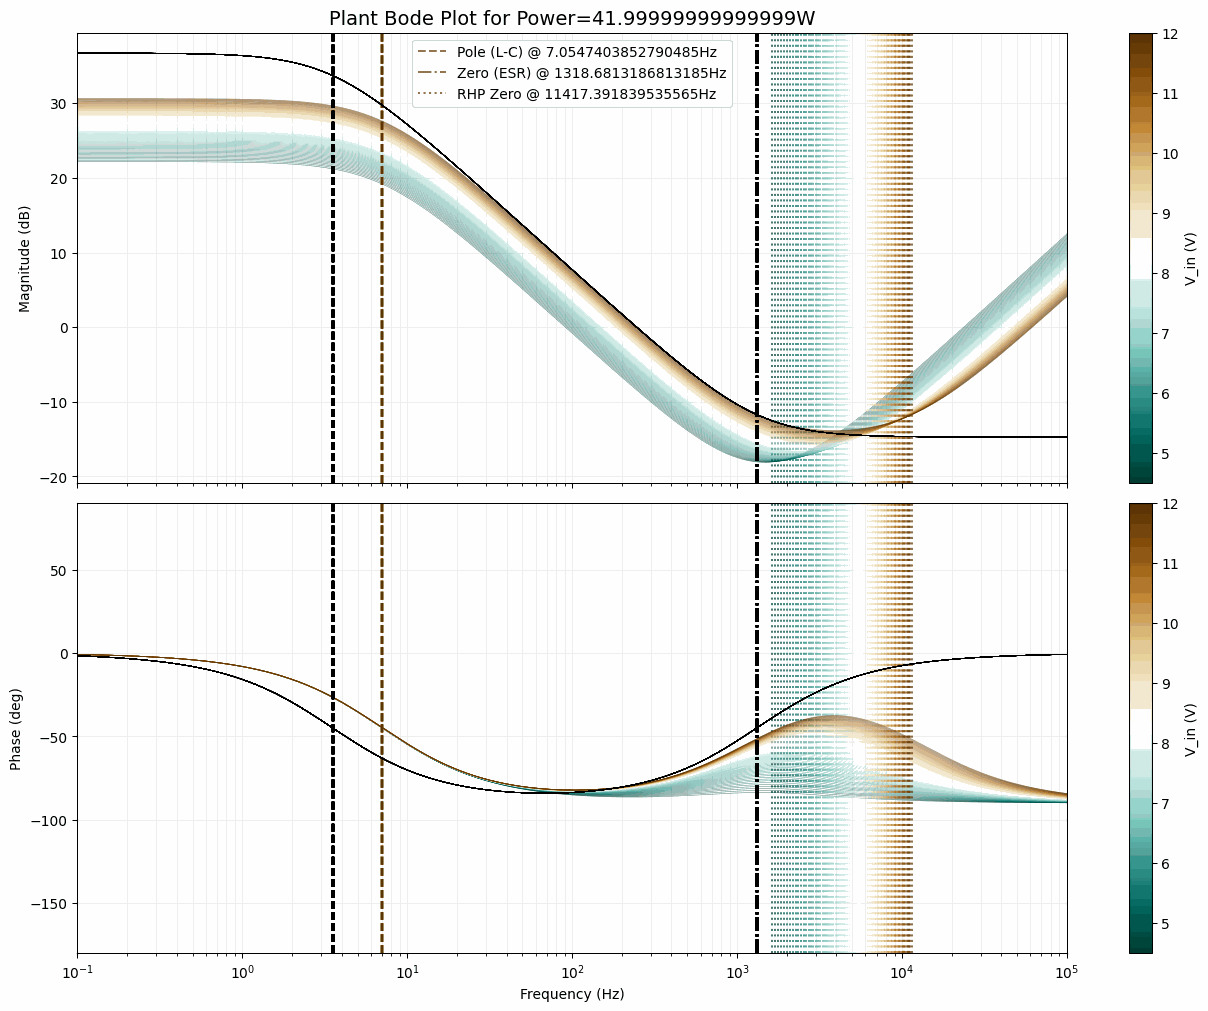

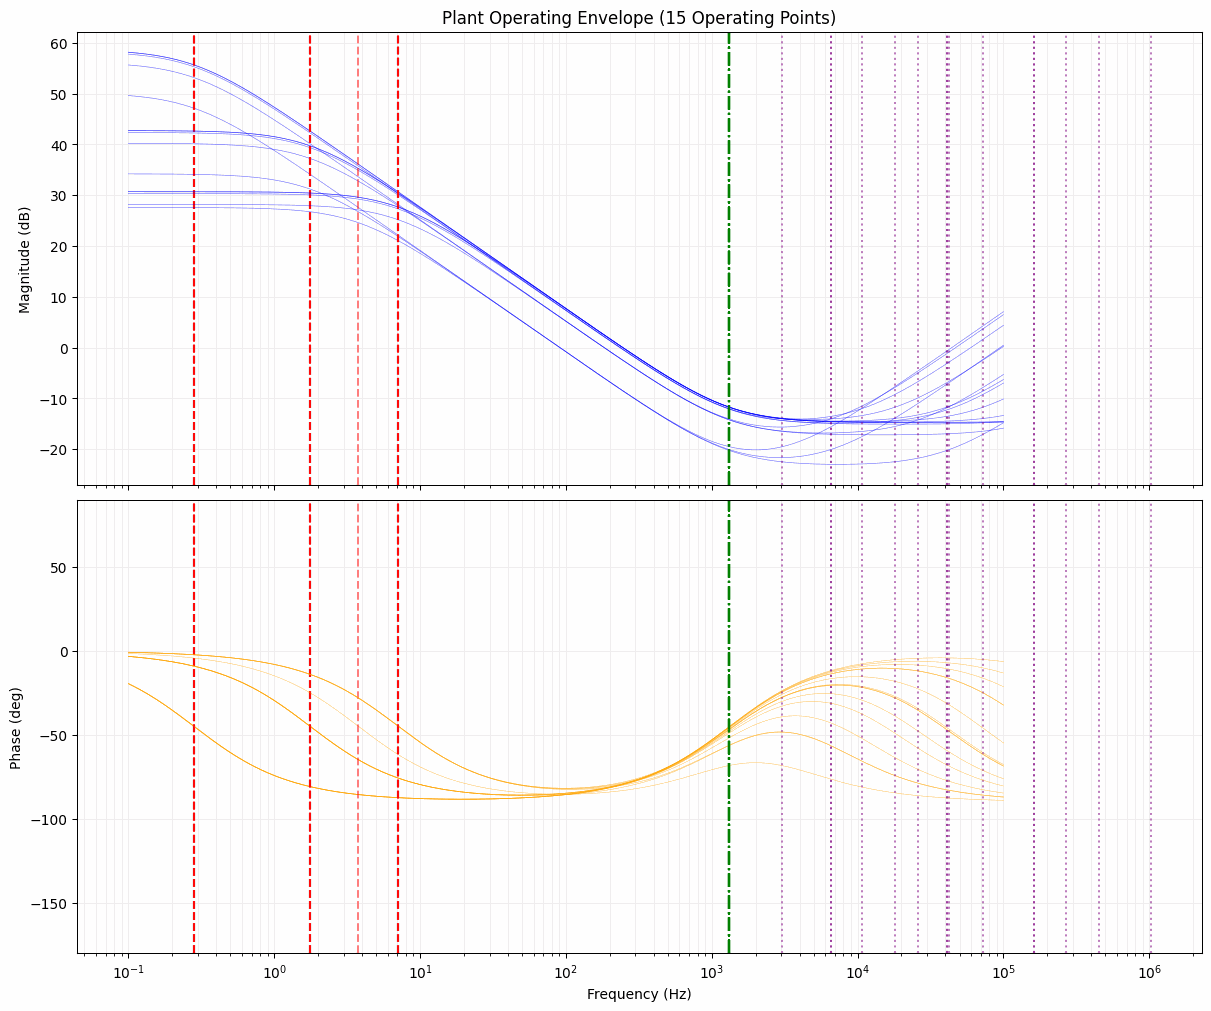

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as colors
from scipy import signal

# --- 1. Flatten the Mesh for Iteration ---
v_in_flat = VIN.flatten()
r_out_flat = R_OUT.flatten()
d_boost_flat = D_BOOST.flatten()

v_in_array_boost = np.arange(4.5, 12.0, 0.1) # finer resolution for color mapping
v_in_array_buck = np.arange(12.1, 22.6, 0.1)
v_in_array = np.concatenate((v_in_array_boost, v_in_array_buck))
power_few = np.asarray([0.5, 10, max_load_watts])
r_out_few = v_out ** 2 / power_few

v_in_few_boost = np.asarray([4.5, 9, 11.5])
v_in_few_buck = np.asarray([22.5]) # current mode buck power stage gain is not affect by vin
v_in_few = np.concatenate((v_in_few_boost, v_in_few_buck))
power_array = np.arange(1, max_load_watts + 1, 1)
power_array = np.insert(power_array, 0, 0.5) # add very light load point for better visualization of low power region
r_out_array = v_out ** 2 / power_array


# Setup Frequency Range
w_hz = np.logspace(-1, 5, 1000)
w_rad = 2 * np.pi * w_hz

for v_in_step in v_in_few:
    fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, layout='constrained')
    ax_mag.grid(True, which="both", alpha=0.2)
    ax_phase.grid(True, which="both", alpha=0.2)
    # Define range and colormap
    norm = colors.Normalize(vmin=np.min(power_array), vmax=np.max(power_array))
    cmap = mpl.colormaps['RdBu_r'] #cmap = cm.get_cmap('RdBu_r') # Red for high power/ blue for low
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_mag, label='Output Power (W)')
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_phase, label='Output Power (W)')
    ax_mag.set_title(f'Plant Bode Plot for Vin={v_in_step}V', fontsize=14)
    for r_out_i, power_i in zip(r_out_array, power_array):
        # Recalculate local Pole/Zero
        # Boost Pole: 2 / (2*pi*R*C)
        if (v_in_step < v_out): # oost mode
            wp = 2 / (r_out_i * c_out_chosen_derated)
            # RHP Zero: (R * (Vin/Vout)^2) / (2*pi*L)
            wrhp = 2 * np.pi * ((r_out_i * (v_in_step/v_out)**2) / (2 * np.pi * L1))
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 2  # slope compensation factor
            _duty = 1 - v_in_step / v_out
            gain_linear = (r_out_i * (1 - _duty)) / (r_cs * a_cs * kd)
            
            # Construct TF
            num = gain_linear * np.polymul([1/wz_esr, 1], [-1/wrhp, 1])
            den = [1/wp, 1]
        elif (v_in_step > v_out): # Buck mode
            wp = 1 / (r_out_i * c_out_chosen_derated)            
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 1  # slope compensation factor
            gain_linear = r_out_i / (r_cs * a_cs * kd)
            
            # Construct TF
            num = [gain_linear * i for i in [1/wz_esr, 1]]
            den = [1/wp, 1]
        sys = signal.TransferFunction(num, den)
        
        # Calculate Bode
        _, mag, phase = signal.bode(sys, w=w_rad)
        
        # Plot with high transparency (alpha)
        ax_mag.semilogx(w_hz, mag, color=cmap(norm(power_i)), alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase, color=cmap(norm(power_i)), alpha=0.5, linewidth=0.5)

        if (v_in_step < v_out): # boost mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot'),
                'RHP Zero': (wrhp/2/np.pi, 'dotted')
            }
        elif (v_in_step > v_out): # buck mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot')
            }
        for label, (freq, style) in features.items():
            # Add vertical lines to both plots
            for ax in [1, 2]:
                plt.subplot(2, 1, ax)
                if (power_i == power_array[-1]):
                    plt.axvline(freq, color=cmap(norm(power_i)), linestyle=style, alpha=0.7, label=f'{label} @ {freq}Hz')
                else:
                    plt.axvline(freq, color=cmap(norm(power_i)), linestyle=style, alpha=0.7)
    ax_mag.legend()
    ax_mag.set_ylabel('Magnitude (dB)')
    ax_phase.set_ylabel('Phase (deg)')
    ax_phase.set_xlabel('Frequency (Hz)')
    ax_mag.set_xlim(0.1, 1e5)
    ax_phase.set_xlim(0.1, 1e5)
    ax_phase.set_ylim(-180, 90) # Standard range for stability check
for power_step, r_out_step in zip(power_few, r_out_few) :
    fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, layout='constrained')
    ax_mag.grid(True, which="both", alpha=0.2)
    ax_phase.grid(True, which="both", alpha=0.2)
    # Define range and colormap
    norm = colors.Normalize(vmin=np.min(v_in_array), vmax=np.max(v_out)) # buck mode is not affected by vin
    cmap = mpl.colormaps['BrBG_r'] #cmap = cm.get_cmap('RdBu_r') # Red for high power/ blue for low
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_mag, label='V_in (V)')
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_phase, label='V_in (V)')
    ax_mag.set_title(f'Plant Bode Plot for Power={power_step}W', fontsize=14)
    for v_in_i in v_in_array:
        if (v_in_i < v_out): # boost mode
            # Recalculate local Pole/Zero
            # Boost Pole: 2 / (2*pi*R*C)
            wp = 2 * np.pi * (2 / (2 * np.pi * r_out_step * c_out_chosen_derated))
            # RHP Zero: (R * (Vin/Vout)^2) / (2*pi*L)
            wrhp = 2 * np.pi * ((r_out_step * (v_in_i/v_out)**2) / (2 * np.pi * L1))
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 2  # slope compensation factor
            _duty = 1 - v_in_i / v_out
            gain_linear = (r_out_step * (1 - _duty)) / (r_cs * a_cs * kd)
            
            # Construct TF
            num = gain_linear * np.polymul([1/wz_esr, 1], [-1/wrhp, 1])
            den = [1/wp, 1]
        elif (v_in_i > v_out): # Buck mode
            # Recalculate local Pole/Zero
            wp = 1 / (r_out_step * c_out_chosen_derated)           
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 1  # slope compensation factor
            gain_linear = r_out_step / (r_cs * a_cs * kd)
            
            # Construct TF
            num = [gain_linear * i for i in [1/wz_esr, 1]]
            den = [1/wp, 1]
        sys = signal.TransferFunction(num, den)
        
        # Calculate Bode
        _, mag, phase = signal.bode(sys, w=w_rad)
        
        # Plot with high transparency (alpha)
        if (v_in_i < v_out): # boost mode
            _color = cmap(norm(v_in_i))
        else: # buck mode
            _color = 'black'
        ax_mag.semilogx(w_hz, mag, color=_color, alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase, color=_color, alpha=0.5, linewidth=0.5)

        if (v_in_i < v_out): # boost mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot'),
                'RHP Zero': (wrhp/2/np.pi, 'dotted')
            }
        elif (v_in_step > v_out): # buck mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot')
            }
        for label, (freq, style) in features.items():
            # Add vertical lines to both plots
            for ax in [1, 2]:
                plt.subplot(2, 1, ax)
                if (v_in_i == v_in_array_boost[-1]):
                    plt.axvline(freq, color=_color, linestyle=style, alpha=0.7, label=f'{label} @ {freq}Hz')
                else:
                    plt.axvline(freq, color=_color, linestyle=style, alpha=0.7)
    ax_mag.legend()
    ax_mag.set_ylabel('Magnitude (dB)')
    ax_phase.set_ylabel('Phase (deg)')
    ax_phase.set_xlabel('Frequency (Hz)')
    ax_mag.set_xlim(0.1, 1e5)
    ax_phase.set_xlim(0.1, 1e5)
    ax_phase.set_ylim(-180, 90) # Standard range for stability check
    plt.show()

# --- 2. Loop Through Every Operating Point ---
fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, layout='constrained')
for i in range(len(v_in_flat)):
    # Local Parameters for this specific point
    R_val = r_out_flat[i]
    D_val = d_boost_flat[i]
    Vin_val = v_in_flat[i]
    
    # Recalculate local Pole/Zero
    # Boost Pole: 2 / (2*pi*R*C)
    
    wp = 2 * np.pi * (1 / (2 * np.pi * (R_val/2) * c_out_chosen_derated))
    # RHP Zero: (R * (Vin/Vout)^2) / (2*pi*L)
    wrhp = 2 * np.pi * ((R_val * (Vin_val/v_out)**2) / (2 * np.pi * L1))
    wz_esr = 2 * np.pi * f_z1 # Constant
    
    # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
    kd = 2  # slope compensation factor
    gain_linear = (R_val * (1 - D_val)) / (r_cs * a_cs * kd)
    
    # Construct TF
    num = gain_linear * np.polymul([1/wz_esr, 1], [-1/wrhp, 1])
    den = [1/wp, 1]
    sys = signal.TransferFunction(num, den)
    
    # Calculate Bode
    _, mag, phase = signal.bode(sys, w=w_rad)
    
    # Plot with high transparency (alpha)
    ax_mag.semilogx(w_hz, mag, color='blue', alpha=0.5, linewidth=0.5)
    ax_phase.semilogx(w_hz, phase, color='orange', alpha=0.5, linewidth=0.5)

    features = {
        'Pole (L-C)': (wp/2/np.pi, 'red', 'dashed'),
        'Zero (ESR)': (wz_esr/2/np.pi, 'green', 'dashdot'),
        'RHP Zero': (wrhp/2/np.pi, 'purple', 'dotted')
    }
    for label, (freq, color, style) in features.items():
        # Add vertical lines to both plots
        for ax in [1, 2]:
            plt.subplot(2, 1, ax)
            plt.axvline(freq, color=color, linestyle=style, alpha=0.5, label=f'{label} @ {freq}Hz')
        
# --- 3. Formatting ---
ax_mag.set_title(f'Plant Operating Envelope ({len(v_in_flat)} Operating Points)')
ax_mag.set_ylabel('Magnitude (dB)')
ax_mag.grid(True, which="both", alpha=0.2)

ax_phase.set_ylabel('Phase (deg)')
ax_phase.set_xlabel('Frequency (Hz)')
ax_phase.set_ylim(-180, 90) # Standard range for stability check
ax_phase.grid(True, which="both", alpha=0.2)

#plt.tight_layout()
plt.show()

R_fb2: 280.0 kOhm
Rc: 1.4 kOhm
Cc: 114.613 uF
Chf: 114.61 nF
Cc: 220.000 nF, chosen capacitor
Chf: 150.00 nF, chosen capacitor


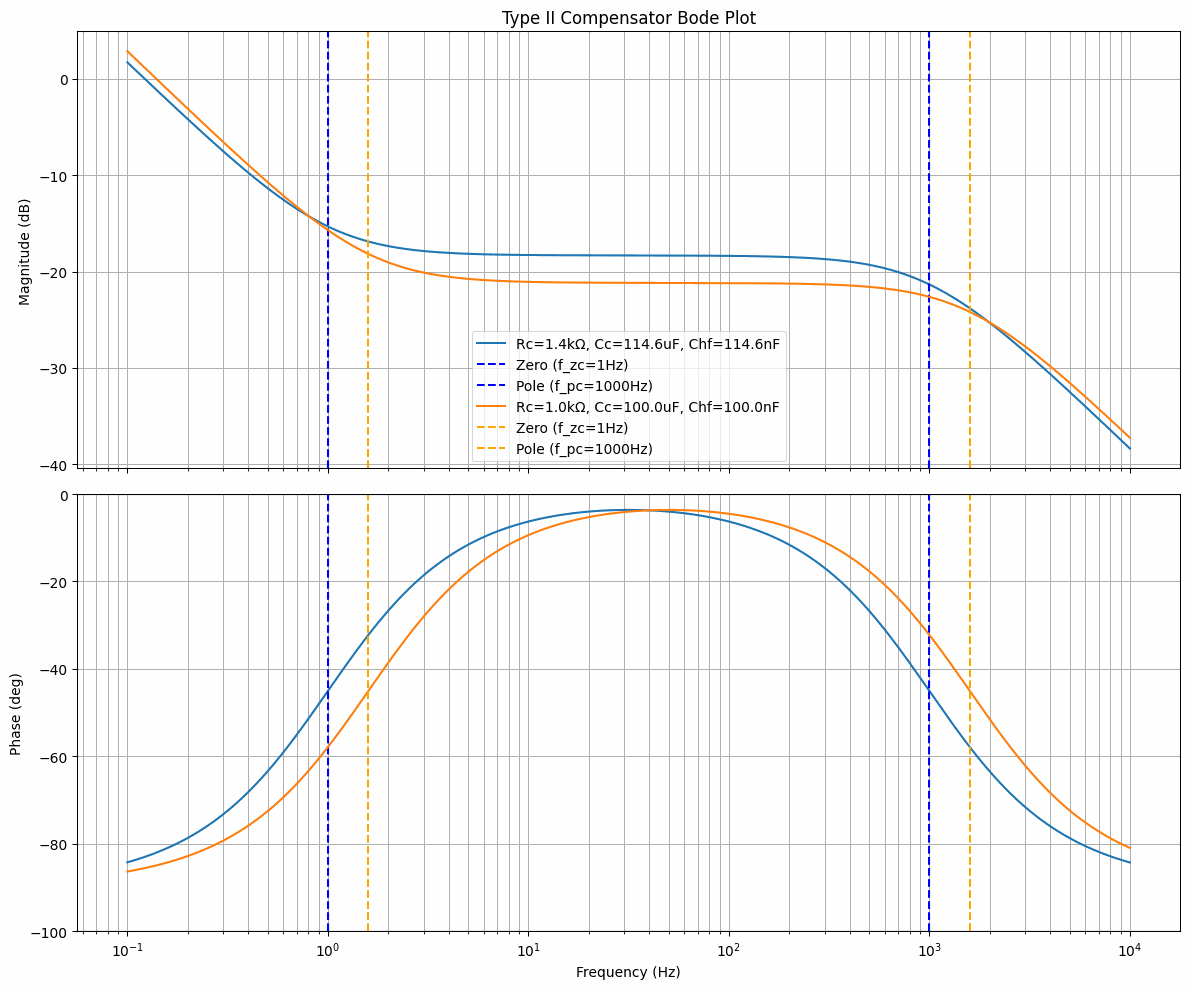

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Corrected variable names
v_out = 12
r_fb1 = 20e3
r_fb2 = (v_out - 0.8) / 0.8 * r_fb1 # 280k
v_ref = 0.8

# Frequencies
f_pc = 1000     # High frequency pole, 7 to 10x bw
#f_bw = f_bw2
#f_zc = f_zc2

# Design values for components
Rc = 2 * np.pi / gm_ea * (r_fb1 + r_fb2) / r_fb1 * a_cs * r_cs * c_out_chosen_derated / (1-D_max_boost) * f_bw
Cc = 1 / (2 * np.pi * Rc * f_zc)
Chf = 1 / (2 * np.pi * Rc * f_pc)

# Transfer Function for Type II Op-Amp Compensator:
# H(s) = (1 + s*Rc*Cc) / (s*r_fb2*(Cc + Chf) * (1 + s*Rc*Cc*Chf/(Cc+Chf)))
fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
Rc_implemented = 1e3
Cc_implemented = 100e-6
Chf_implemented = 100e-9
_colors = ['blue', 'orange']
for i, compensation in enumerate([[Rc, Cc, Chf], [Rc_implemented, Cc_implemented, Chf_implemented]]):
    _Rc, _Cc, _Chf = compensation
    
    gain_dc_comp = r_fb1 / (r_fb1 + r_fb2) * gm_ea * r_out_ea
    num = [gain_dc_comp * i for i in [_Rc * _Cc, 1]]
    # Denominator coefficients: s^2 * [r_fb2 * (Cc+Chf) * Rc * Cc * Chf / (Cc+Chf)] + s * [r_fb2 * (Cc+Chf)] + 0
    #den = [r_fb2 * Rc_implemented * Cc_implemented * Chf_implemented, r_fb2 * (Cc_implemented + Chf_implemented), 0]
    den = np.polymul([_Rc * _Chf, 1], [r_out_ea * _Cc, 1])

    sys_comp = signal.TransferFunction(num, den)

    # Frequencies for plot: 0.1 Hz to 10 kHz
    w_hz = np.logspace(-1, 4, 1000)
    w = 2 * np.pi * w_hz
    w, mag, phase = signal.bode(sys_comp, w)

    #plt.figure(figsize=(10, 8))

    # Magnitude Plot
    #plt.subplot(2, 1, 1)
    ax_mag.semilogx(w_hz, mag, label = 'Rc={:.1f}kΩ, Cc={:.1f}uF, Chf={:.1f}nF'.format(_Rc/1e3, _Cc*1e6, _Chf*1e9))
    ax_mag.set_title('Type II Compensator Bode Plot')
    ax_mag.set_ylabel('Magnitude (dB)')
    ax_mag.grid(True, which="both")
    ax_mag.axvline(1 / (2 * np.pi * _Rc * _Cc), color=_colors[i], linestyle='--', label=f'Zero (f_zc={f_zc}Hz)')
    ax_mag.axvline(1 / (2 * np.pi * _Rc * _Chf), color=_colors[i], linestyle='--', label=f'Pole (f_pc={f_pc}Hz)')
    ax_mag.legend()

    # Phase Plot
    ax_phase.semilogx(w_hz, phase)
    ax_phase.set_ylabel('Phase (deg)')
    ax_phase.set_xlabel('Frequency (Hz)')
    ax_phase.set_ylim(-100, 0)
    ax_phase.grid(True, which="both")
    ax_phase.axvline(1 / (2 * np.pi * _Rc * _Cc), color=_colors[i], linestyle='--')
    ax_phase.axvline(1 / (2 * np.pi * _Rc * _Chf), color=_colors[i], linestyle='--')

plt.tight_layout()
plt.savefig('compensator_bode_plot.png')

print(f"R_fb2: {r_fb2/1000:.1f} kOhm")
print(f"Rc: {Rc/1000:.1f} kOhm")
print(f"Cc: {Cc*1e6:.3f} uF")
print(f"Chf: {Chf*1e9:.2f} nF")
print(f"Cc: {220:.3f} nF, chosen capacitor")
print(f"Chf: {150:.2f} nF, chosen capacitor")

### Good low-frequency compensation

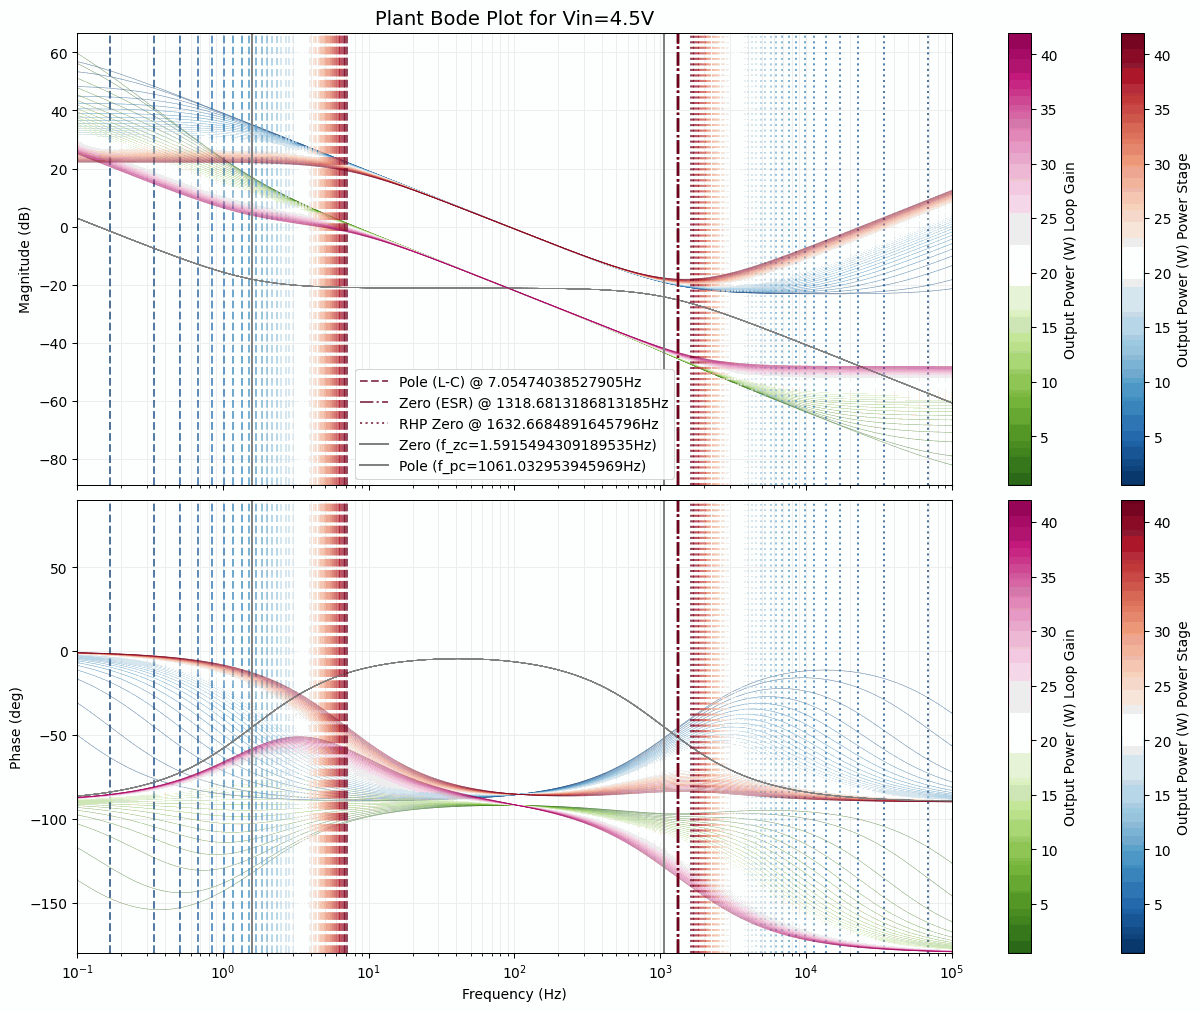

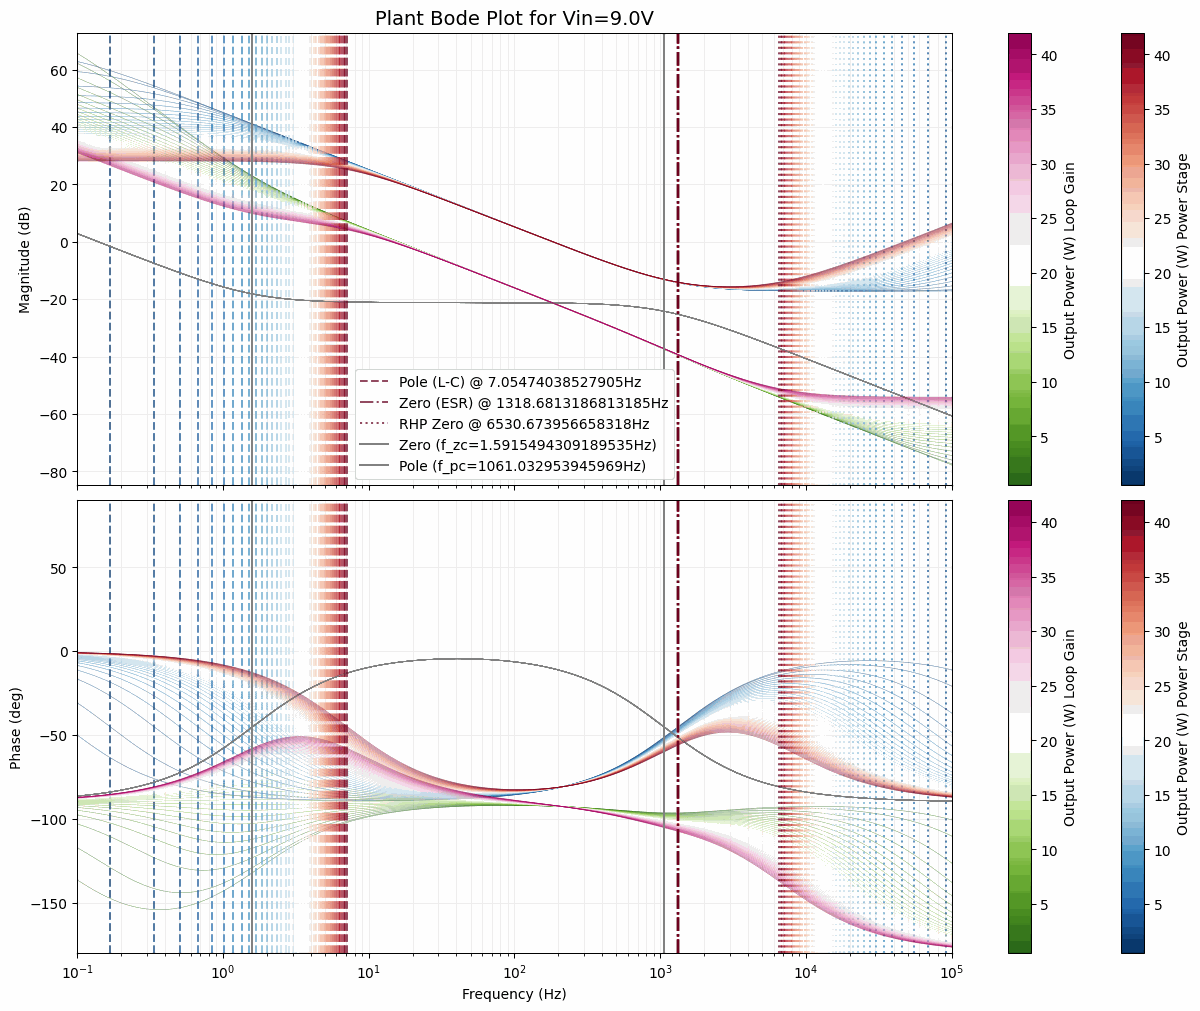

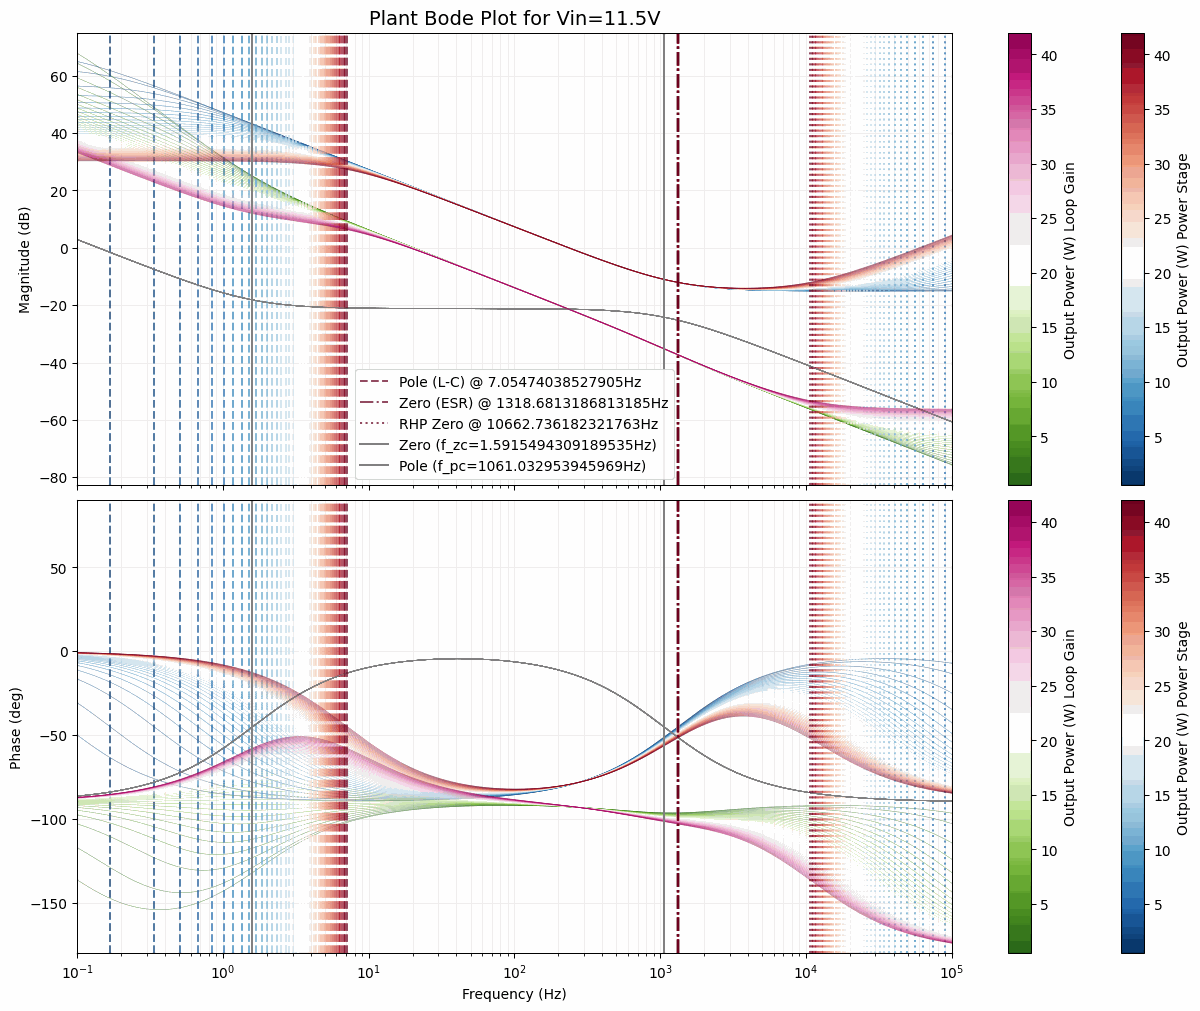

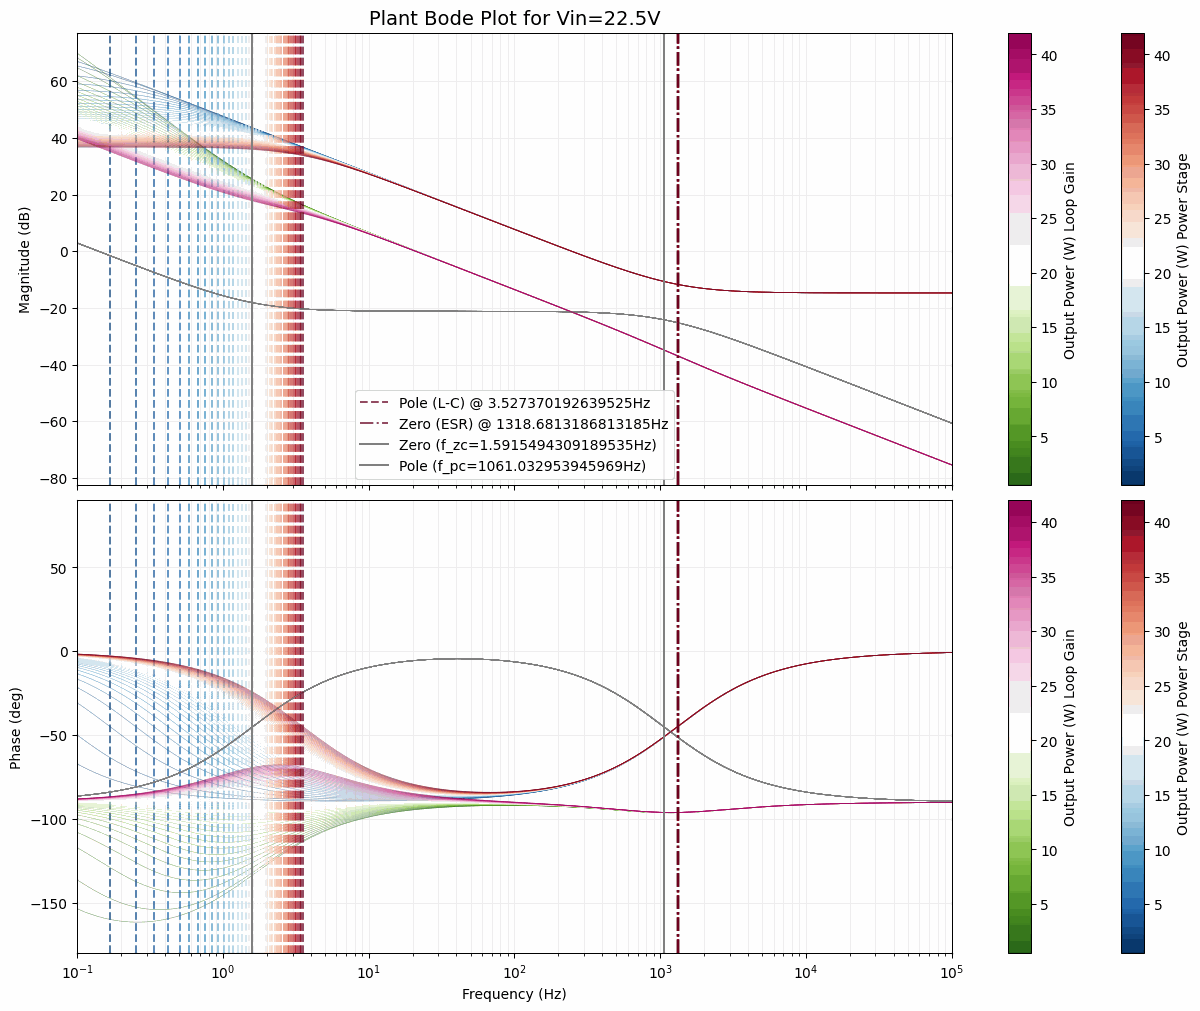

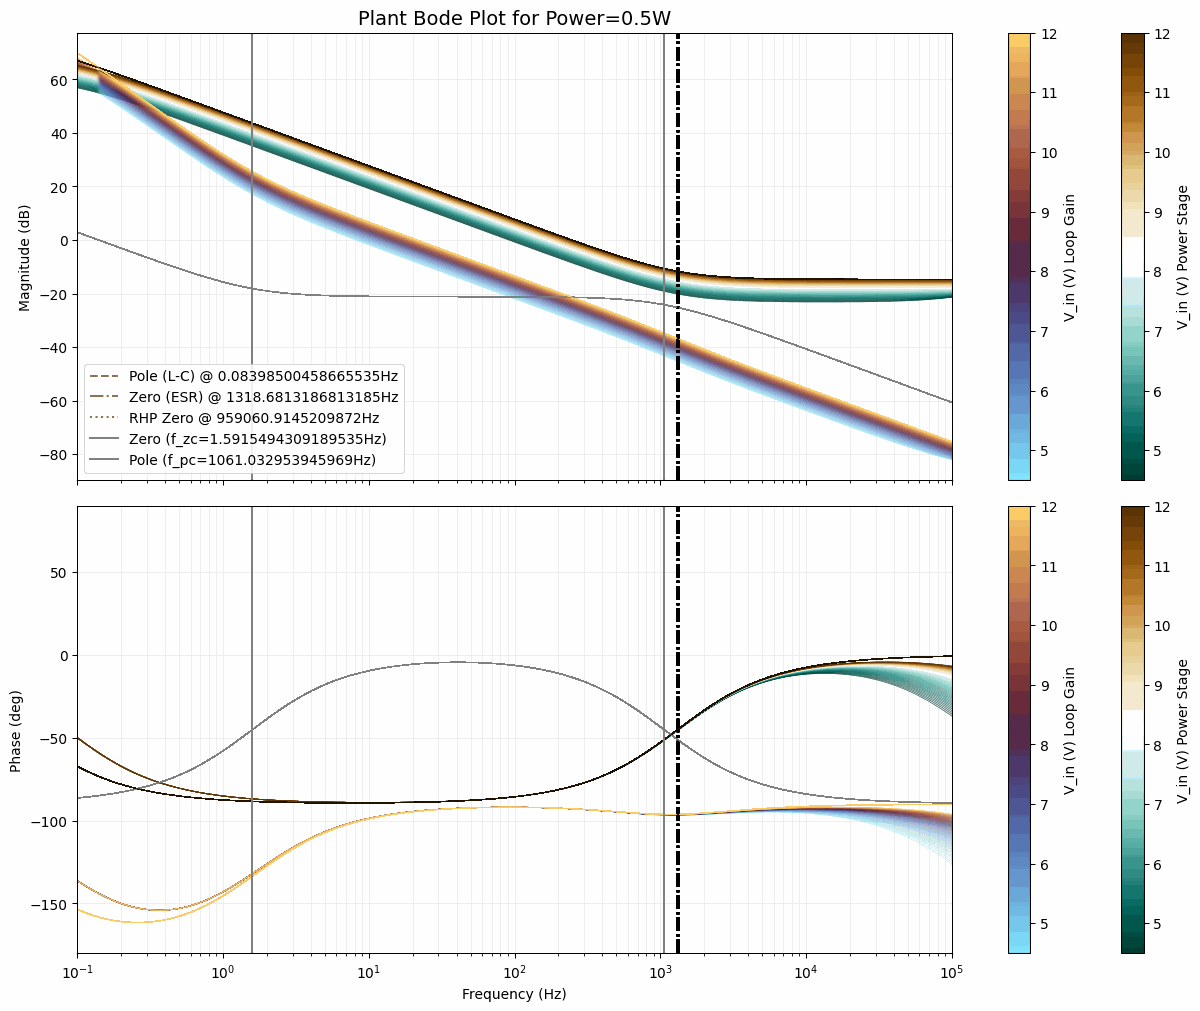

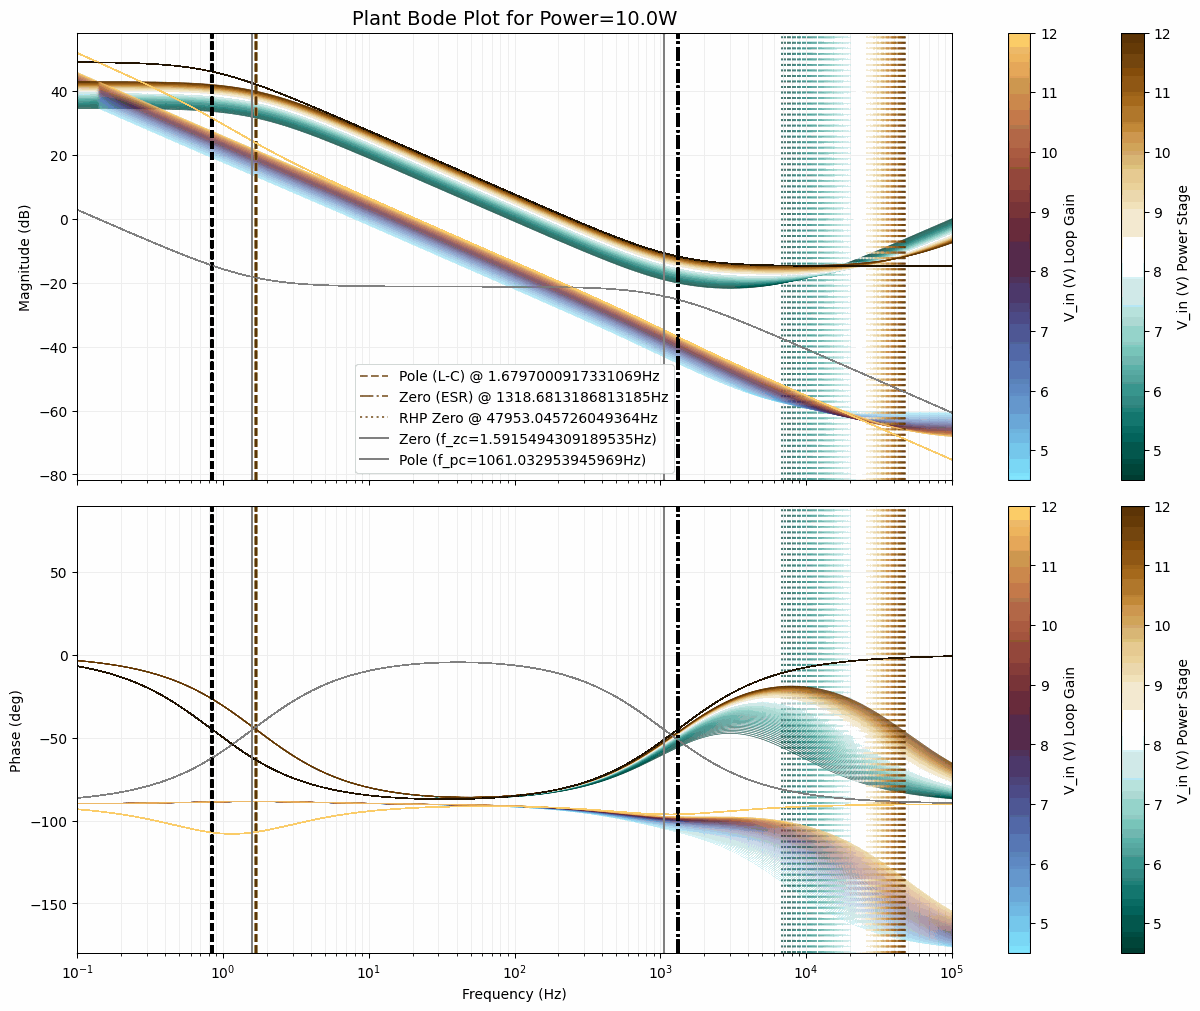

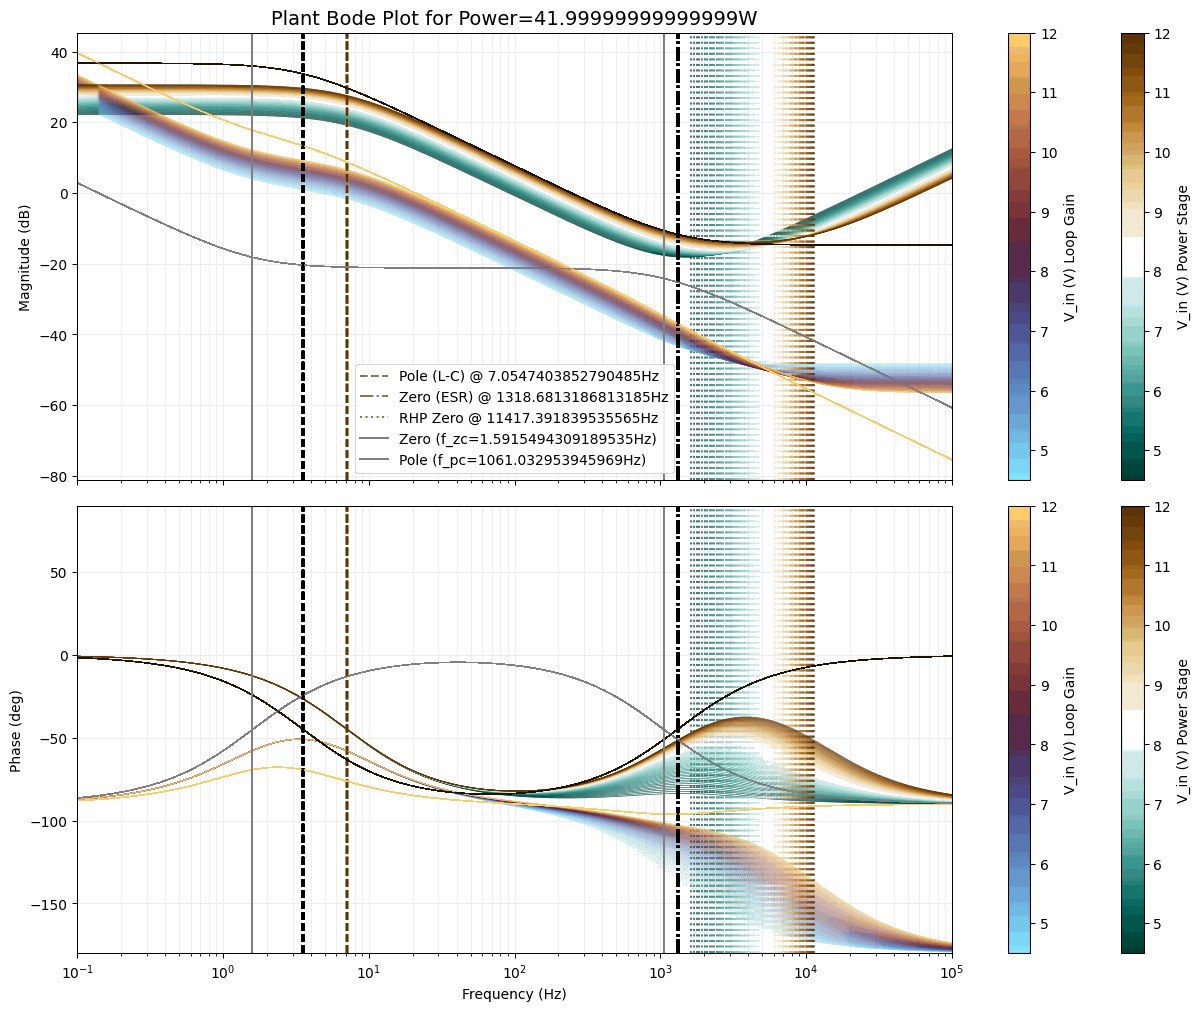

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as colors
from scipy import signal

# --- 1. Flatten the Mesh for Iteration ---
v_in_flat = VIN.flatten()
r_out_flat = R_OUT.flatten()
d_boost_flat = D_BOOST.flatten()

v_in_array_boost = np.arange(4.5, 12.0, 0.1) # finer resolution for color mapping
v_in_array_buck = np.arange(12.1, 22.6, 0.1)
v_in_array = np.concatenate((v_in_array_boost, v_in_array_buck))
power_few = np.asarray([0.5, 10, max_load_watts])
r_out_few = v_out ** 2 / power_few

v_in_few_boost = np.asarray([4.5, 9, 11.5])
v_in_few_buck = np.asarray([22.5]) # current mode buck power stage gain is not affect by vin
v_in_few = np.concatenate((v_in_few_boost, v_in_few_buck))
power_array = np.arange(1, max_load_watts + 1, 1)
power_array = np.insert(power_array, 0, 0.5) # add very light load point for better visualization of low power region
r_out_array = v_out ** 2 / power_array


# Setup Frequency Range
w_hz = np.logspace(-1, 5, 1000)
w_rad = 2 * np.pi * w_hz

Rc_implemented = 1e3
Cc_implemented = 100e-6
Chf_implemented = 150e-9
f_zc_implemented = 1 / (2 * np.pi * Rc_implemented * Cc_implemented)
f_pc_implemented = 1 / (2 * np.pi * Rc_implemented * Chf_implemented)

gain_dc_comp = r_fb1 / (r_fb1 + r_fb2) * gm_ea * r_out_ea
num = [gain_dc_comp * i for i in [Rc_implemented * Cc_implemented, 1]]
# Denominator coefficients: s^2 * [r_fb2 * (Cc+Chf) * Rc * Cc * Chf / (Cc+Chf)] + s * [r_fb2 * (Cc+Chf)] + 0
#den = [r_fb2 * Rc_implemented * Cc_implemented * Chf_implemented, r_fb2 * (Cc_implemented + Chf_implemented), 0]
den = np.polymul([Rc_implemented * Chf_implemented, 1], [r_out_ea * Cc_implemented, 1])
sys_comp = signal.TransferFunction(num, den)


for v_in_step in v_in_few:
    fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, layout='constrained')
    ax_mag.grid(True, which="both", alpha=0.2)
    ax_phase.grid(True, which="both", alpha=0.2)
    # Define range and colormap
    norm = colors.Normalize(vmin=np.min(power_array), vmax=np.max(power_array))
    cmap = mpl.colormaps['RdBu_r'] #cmap = cm.get_cmap('RdBu_r') # Red for high power/ blue for low
    cmap2 = mpl.colormaps['PiYG_r'] # for total system response
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_mag, label='Output Power (W) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_mag, label='Output Power (W) Loop Gain')
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_phase, label='Output Power (W) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_phase, label='Output Power (W) Loop Gain')
    ax_mag.set_title(f'Plant Bode Plot for Vin={v_in_step}V', fontsize=14)
    for r_out_i, power_i in zip(r_out_array, power_array):
        # Recalculate local Pole/Zero
        # Boost Pole: 2 / (2*pi*R*C)
        if (v_in_step < v_out): # oost mode
            wp = 2 / (r_out_i * c_out_chosen_derated)
            # RHP Zero: (R * (Vin/Vout)^2) / (2*pi*L)
            wrhp = 2 * np.pi * ((r_out_i * (v_in_step/v_out)**2) / (2 * np.pi * L1))
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 2  # slope compensation factor
            _duty = 1 - v_in_step / v_out
            gain_linear = (r_out_i * (1 - _duty)) / (r_cs * a_cs * kd)
            
            # Construct TF
            num = gain_linear * np.polymul([1/wz_esr, 1], [-1/wrhp, 1])
            den = [1/wp, 1]
        elif (v_in_step > v_out): # Buck mode
            wp = 1 / (r_out_i * c_out_chosen_derated)            
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 1  # slope compensation factor
            gain_linear = r_out_i / (r_cs * a_cs * kd)
            
            # Construct TF
            num = [gain_linear * i for i in [1/wz_esr, 1]]
            den = [1/wp, 1]
        sys = signal.TransferFunction(num, den)
        num_total = np.polymul(sys.num, sys_comp.num)
        den_total = np.polymul(sys.den, sys_comp.den)
        sys_total = signal.TransferFunction(num_total, den_total)
        
        _, mag_total, phase_total = signal.bode(sys_total, w=w_rad)

        # Calculate Bode
        _, mag, phase = signal.bode(sys, w=w_rad)
        _, mag_comp, phase_comp = signal.bode(sys_comp, w=w_rad)
        _, mag_total, phase_total = signal.bode(sys_total, w=w_rad)
        # Plot with high transparency (alpha)
        ax_mag.semilogx(w_hz, mag, color=cmap(norm(power_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_total, color=cmap2(norm(power_i)), alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase, color=cmap(norm(power_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_total, color=cmap2(norm(power_i)), alpha=0.5, linewidth=0.5)

        if (v_in_step < v_out): # boost mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot'),
                'RHP Zero': (wrhp/2/np.pi, 'dotted')
            }
        elif (v_in_step > v_out): # buck mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot')
            }
        for label, (freq, style) in features.items():
            # Add vertical lines to both plots
            for ax in [1, 2]:
                plt.subplot(2, 1, ax)
                if (power_i == power_array[-1]):
                    plt.axvline(freq, color=cmap(norm(power_i)), linestyle=style, alpha=0.7, label=f'{label} @ {freq}Hz')
                else:
                    plt.axvline(freq, color=cmap(norm(power_i)), linestyle=style, alpha=0.7)
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={f_zc_implemented}Hz)')
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={f_pc_implemented}Hz)')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={f_zc_implemented}Hz)')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={f_pc_implemented}Hz)')
    ax_mag.legend()
    ax_mag.set_ylabel('Magnitude (dB)')
    ax_phase.set_ylabel('Phase (deg)')
    ax_phase.set_xlabel('Frequency (Hz)')
    ax_mag.set_xlim(0.1, 1e5)
    ax_phase.set_xlim(0.1, 1e5)
    ax_phase.set_ylim(-180, 90) # Standard range for stability check
for power_step, r_out_step in zip(power_few, r_out_few) :
    fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, layout='constrained')
    ax_mag.grid(True, which="both", alpha=0.2)
    ax_phase.grid(True, which="both", alpha=0.2)
    # Define range and colormap
    norm = colors.Normalize(vmin=np.min(v_in_array), vmax=np.max(v_out)) # buck mode is not affected by vin
    cmap = mpl.colormaps['BrBG_r'] #cmap = cm.get_cmap('RdBu_r') # Red for high power/ blue for low
    cmap2 = mpl.colormaps['managua_r'] # for total system response
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_mag, label='V_in (V) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_mag, label='V_in (V) Loop Gain')
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_phase, label='V_in (V) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_phase, label='V_in (V) Loop Gain')
    ax_mag.set_title(f'Plant Bode Plot for Power={power_step}W', fontsize=14)
    for v_in_i in v_in_array:
        if (v_in_i < v_out): # boost mode
            # Recalculate local Pole/Zero
            # Boost Pole: 2 / (2*pi*R*C)
            wp = 2 * np.pi * (2 / (2 * np.pi * r_out_step * c_out_chosen_derated))
            # RHP Zero: (R * (Vin/Vout)^2) / (2*pi*L)
            wrhp = 2 * np.pi * ((r_out_step * (v_in_i/v_out)**2) / (2 * np.pi * L1))
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 2  # slope compensation factor
            _duty = 1 - v_in_i / v_out
            gain_linear = (r_out_step * (1 - _duty)) / (r_cs * a_cs * kd)
            
            # Construct TF
            num = gain_linear * np.polymul([1/wz_esr, 1], [-1/wrhp, 1])
            den = [1/wp, 1]
        elif (v_in_i > v_out): # Buck mode
            # Recalculate local Pole/Zero
            wp = 1 / (r_out_step * c_out_chosen_derated)           
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 1  # slope compensation factor
            gain_linear = r_out_step / (r_cs * a_cs * kd)
            
            # Construct TF
            num = [gain_linear * i for i in [1/wz_esr, 1]]
            den = [1/wp, 1]
        sys = signal.TransferFunction(num, den)
        
        num_total = np.polymul(sys.num, sys_comp.num)
        den_total = np.polymul(sys.den, sys_comp.den)
        sys_total = signal.TransferFunction(num_total, den_total)

        # Calculate Bode
        _, mag, phase = signal.bode(sys, w=w_rad)
        _, mag_comp, phase_comp = signal.bode(sys_comp, w=w_rad)
        _, mag_total, phase_total = signal.bode(sys_total, w=w_rad)
        # Plot with high transparency (alpha)
        ax_mag.semilogx(w_hz, mag, color=cmap(norm(v_in_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_total, color=cmap2(norm(v_in_i)), alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase, color=cmap(norm(v_in_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_total, color=cmap2(norm(v_in_i)), alpha=0.5, linewidth=0.5)

        # Plot with high transparency (alpha)
        if (v_in_i < v_out): # boost mode
            _color = cmap(norm(v_in_i))
        else: # buck mode
            _color = 'black'
        
        ax_mag.semilogx(w_hz, mag, color=_color, alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase, color=_color, alpha=0.5, linewidth=0.5)

        if (v_in_i < v_out): # boost mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot'),
                'RHP Zero': (wrhp/2/np.pi, 'dotted')
            }
        elif (v_in_step > v_out): # buck mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot')
            }
        for label, (freq, style) in features.items():
            # Add vertical lines to both plots
            for ax in [1, 2]:
                plt.subplot(2, 1, ax)
                if (v_in_i == v_in_array_boost[-1]):
                    plt.axvline(freq, color=_color, linestyle=style, alpha=0.7, label=f'{label} @ {freq}Hz')
                else:
                    plt.axvline(freq, color=_color, linestyle=style, alpha=0.7)
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={f_zc_implemented}Hz)')
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={f_pc_implemented}Hz)')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={f_zc_implemented}Hz)')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={f_pc_implemented}Hz)')
    ax_mag.legend()
    ax_mag.set_ylabel('Magnitude (dB)')
    ax_phase.set_ylabel('Phase (deg)')
    ax_phase.set_xlabel('Frequency (Hz)')
    ax_mag.set_xlim(0.1, 1e5)
    ax_phase.set_xlim(0.1, 1e5)
    ax_phase.set_ylim(-180, 90) # Standard range for stability check
    plt.show()


### Accidentally assembled on PCB v1

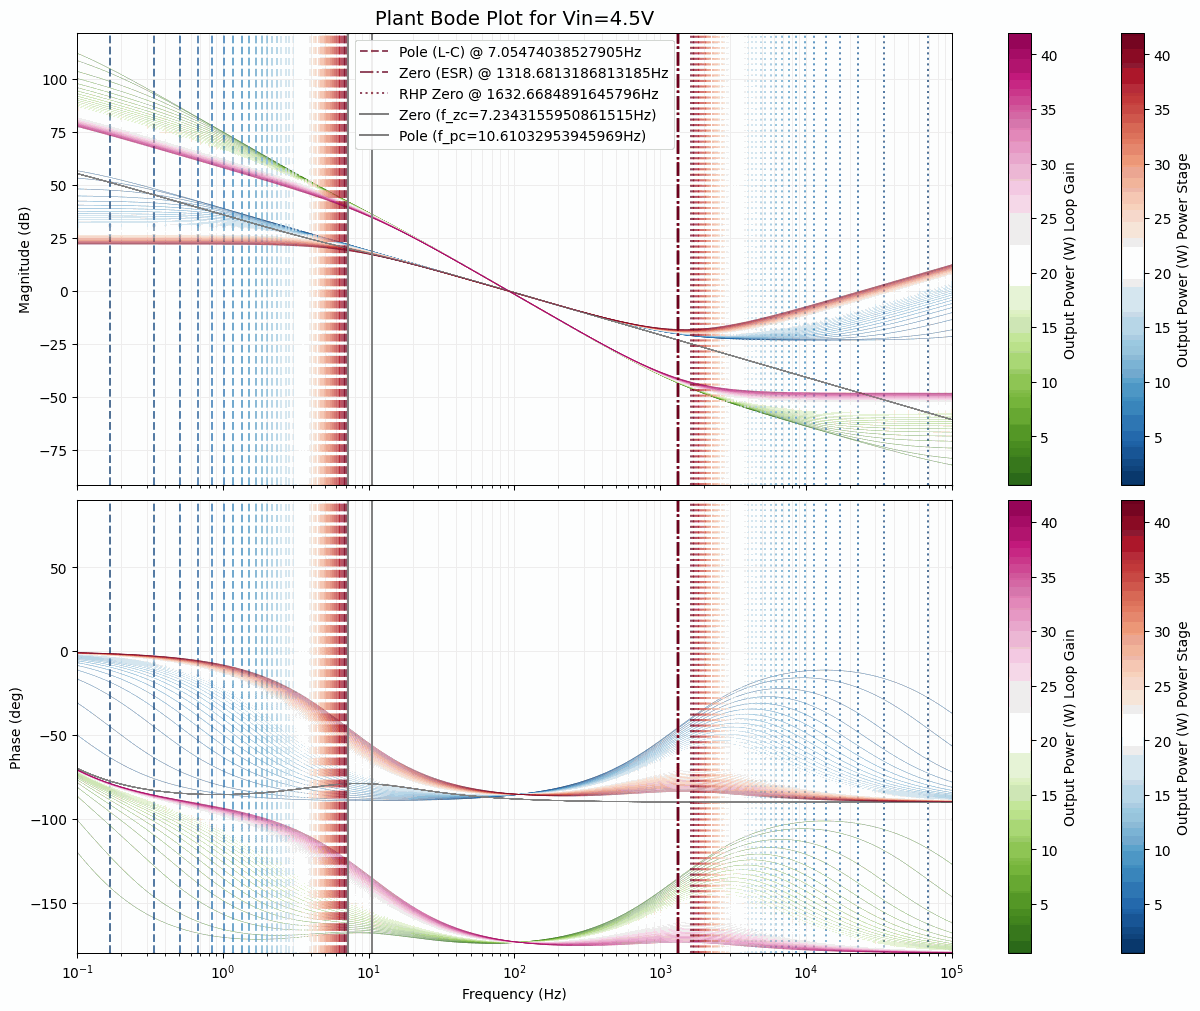

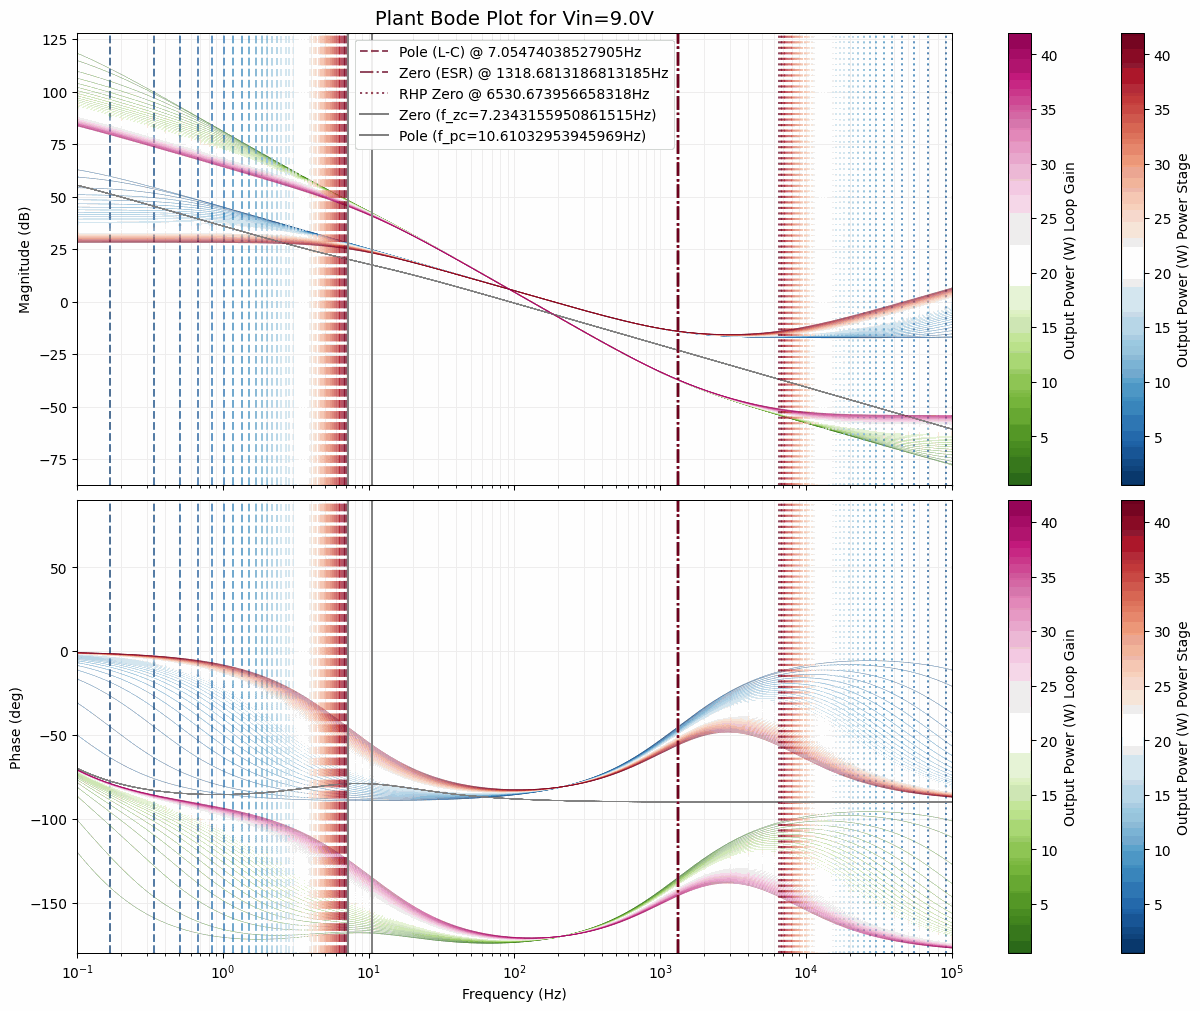

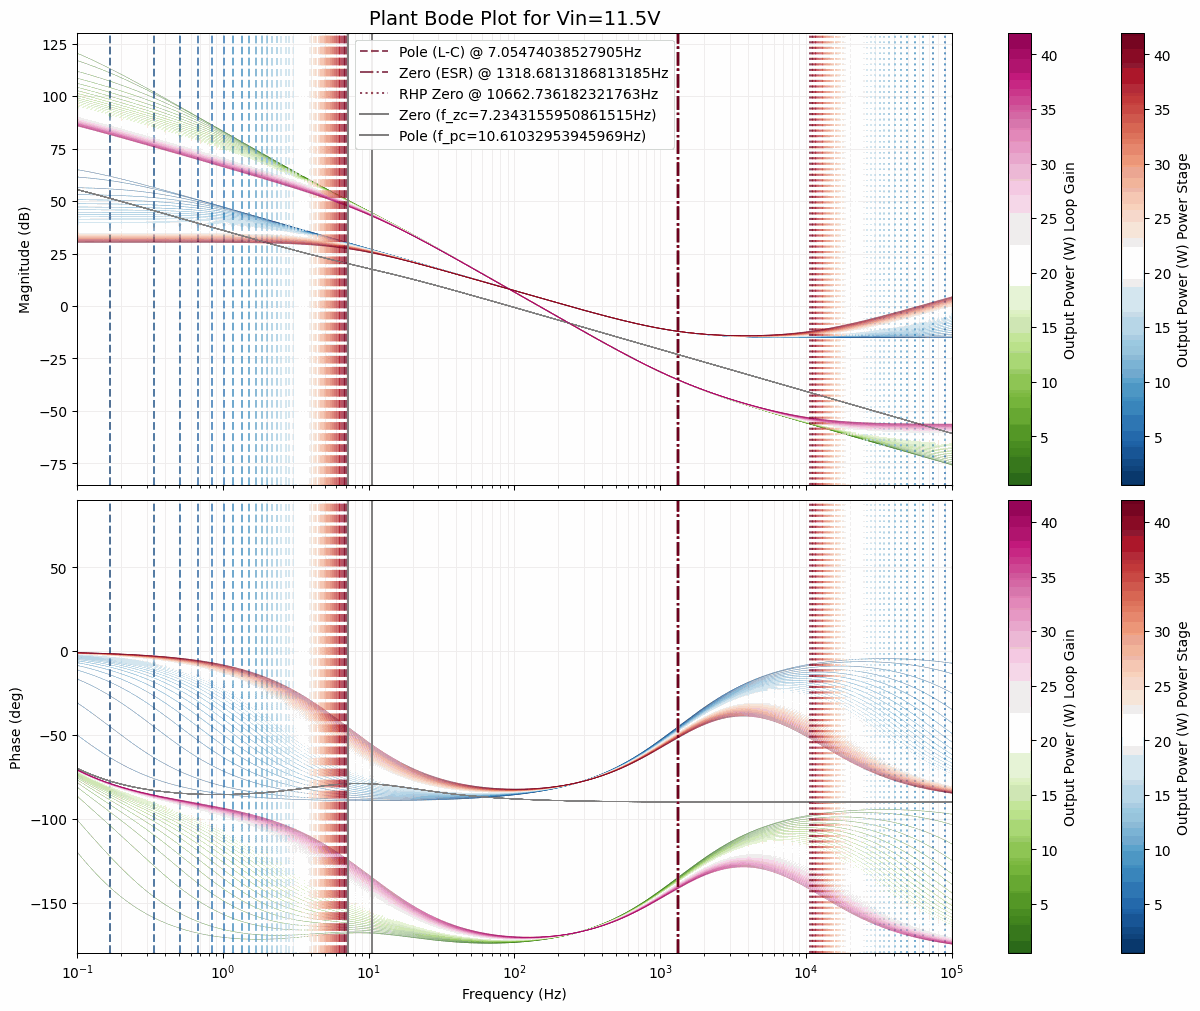

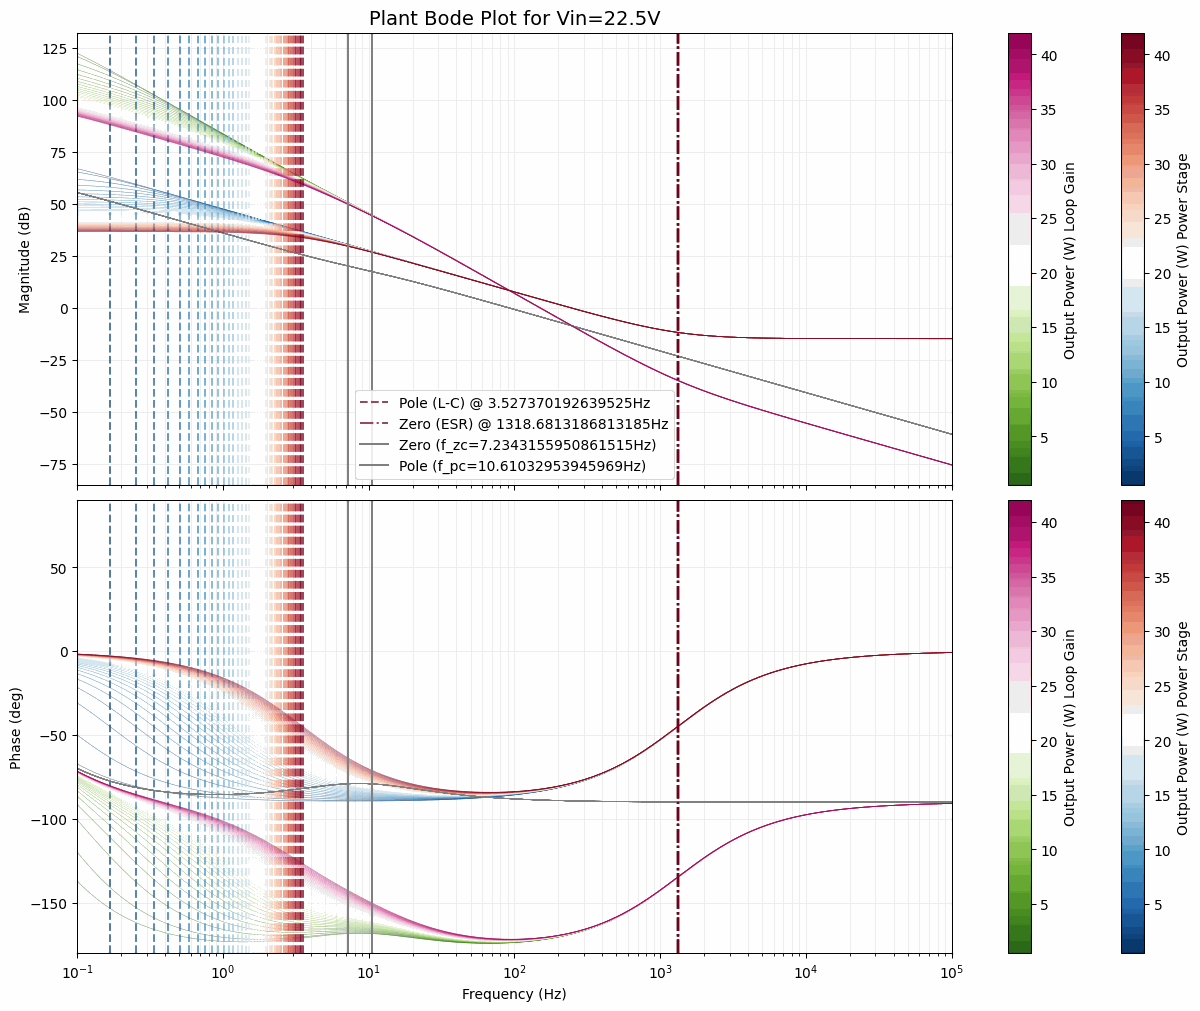

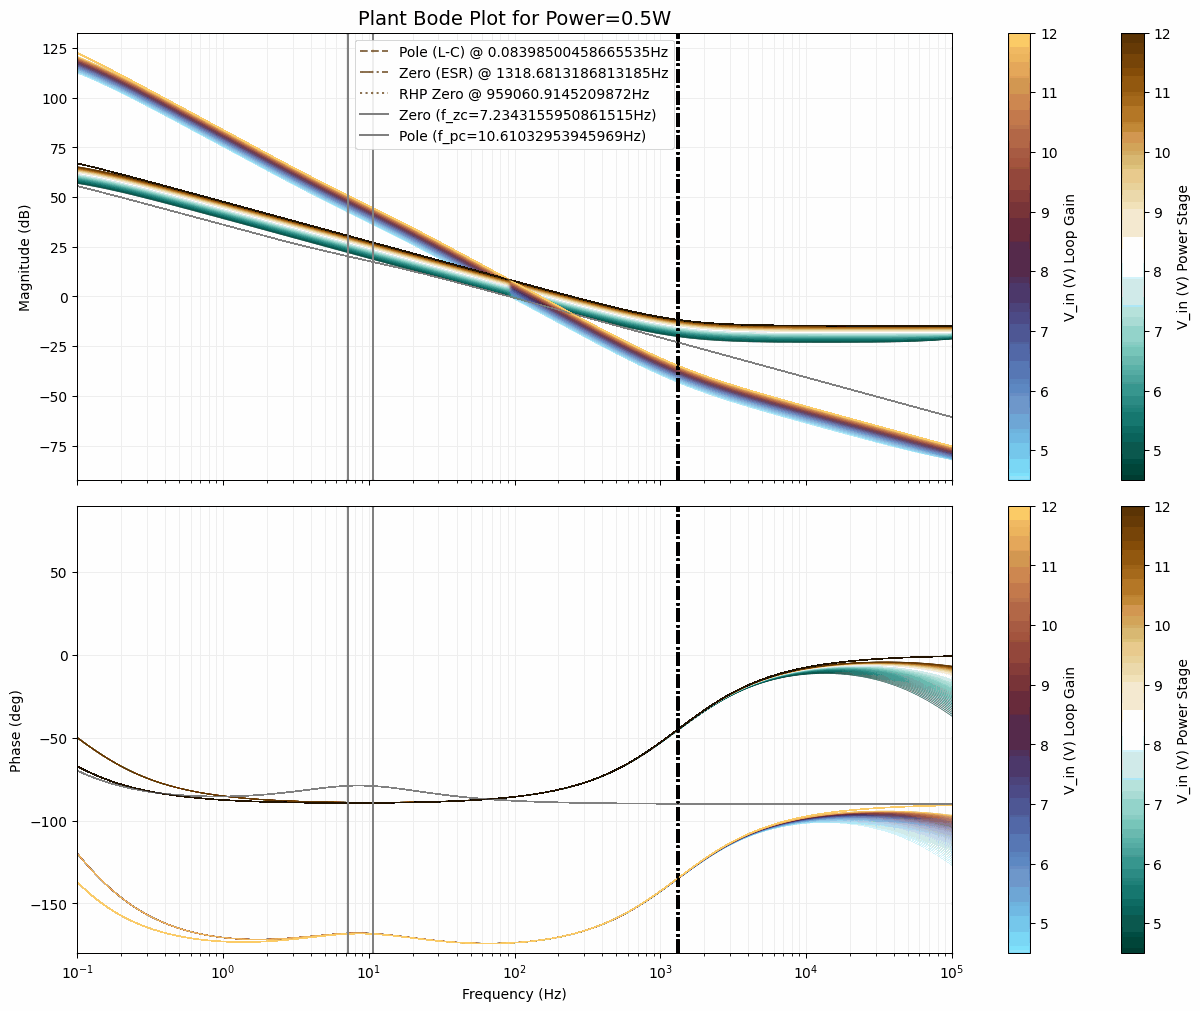

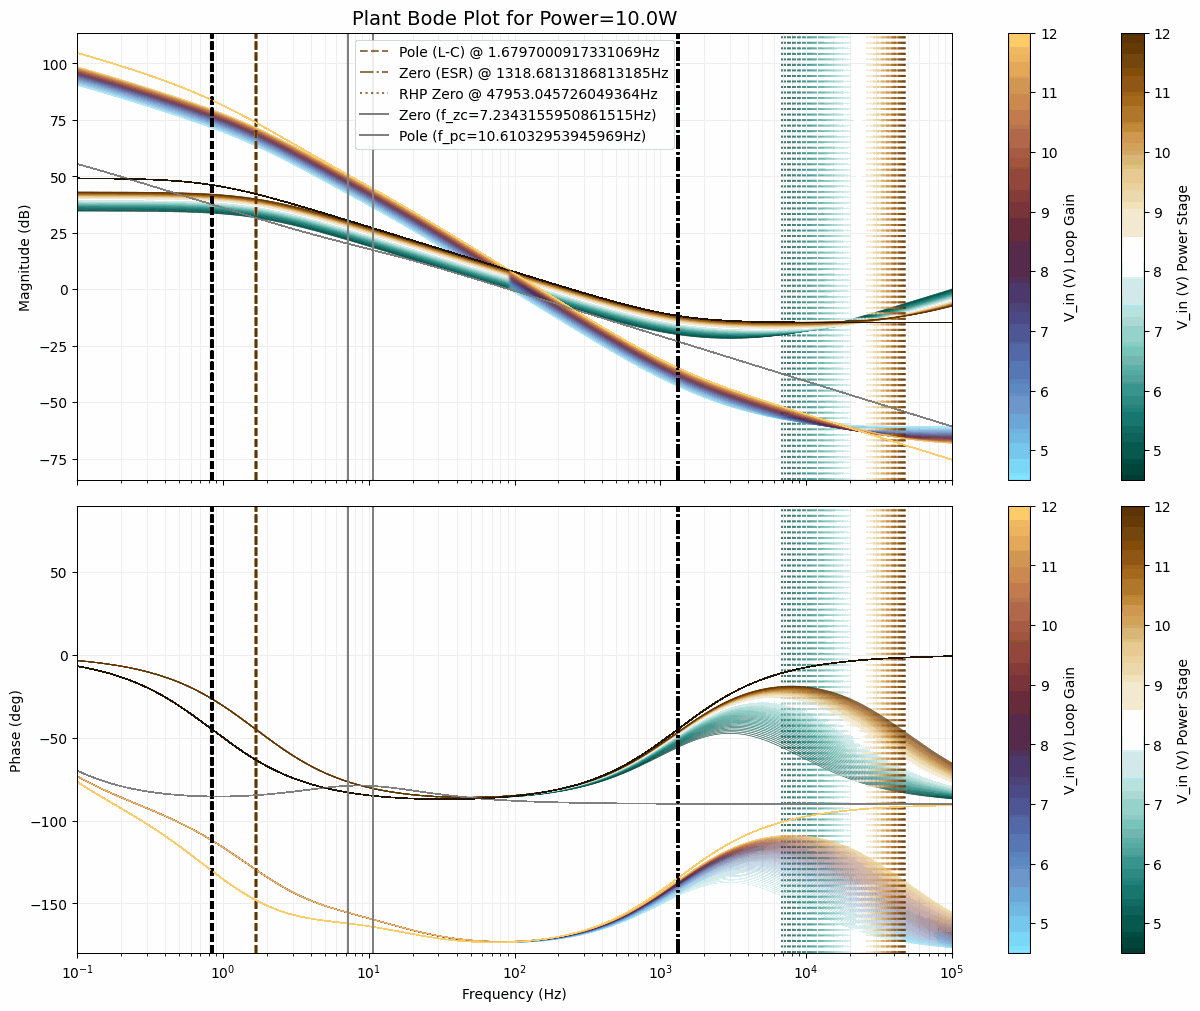

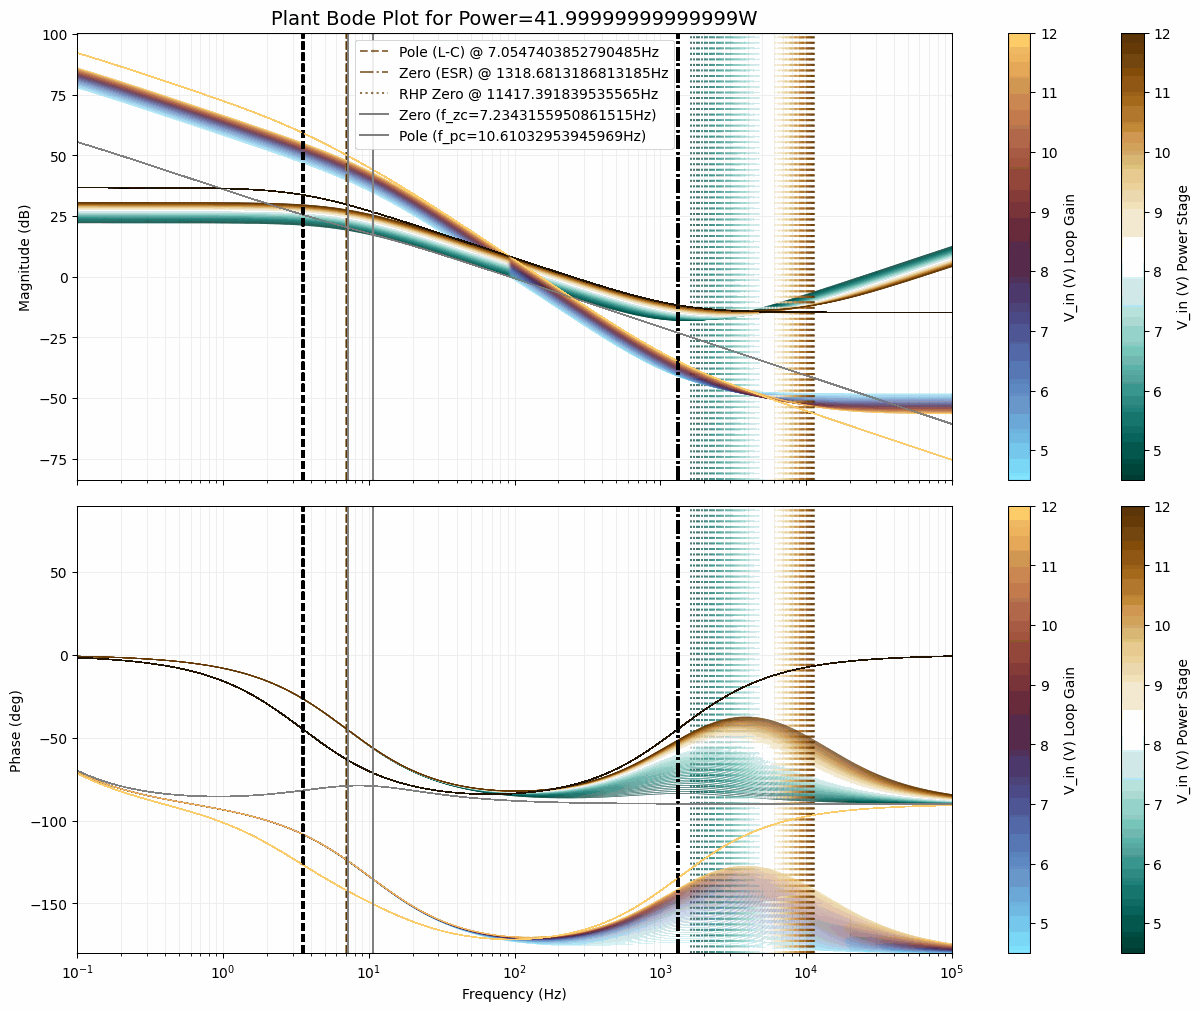

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as colors
from scipy import signal

# --- 1. Flatten the Mesh for Iteration ---
v_in_flat = VIN.flatten()
r_out_flat = R_OUT.flatten()
d_boost_flat = D_BOOST.flatten()

v_in_array_boost = np.arange(4.5, 12.0, 0.1) # finer resolution for color mapping
v_in_array_buck = np.arange(12.1, 22.6, 0.1)
v_in_array = np.concatenate((v_in_array_boost, v_in_array_buck))
power_few = np.asarray([0.5, 10, max_load_watts])
r_out_few = v_out ** 2 / power_few

v_in_few_boost = np.asarray([4.5, 9, 11.5])
v_in_few_buck = np.asarray([22.5]) # current mode buck power stage gain is not affect by vin
v_in_few = np.concatenate((v_in_few_boost, v_in_few_buck))
power_array = np.arange(1, max_load_watts + 1, 1)
power_array = np.insert(power_array, 0, 0.5) # add very light load point for better visualization of low power region
r_out_array = v_out ** 2 / power_array


# Setup Frequency Range
w_hz = np.logspace(-1, 5, 1000)
w_rad = 2 * np.pi * w_hz

Rc_implemented = 100e3
Cc_implemented = 220e-9
Chf_implemented = 150e-9
f_zc_implemented = 1 / (2 * np.pi * Rc_implemented * Cc_implemented)
f_pc_implemented = 1 / (2 * np.pi * Rc_implemented * Chf_implemented)

gain_dc_comp = r_fb1 / (r_fb1 + r_fb2) * gm_ea * r_out_ea
num = [gain_dc_comp * i for i in [Rc_implemented * Cc_implemented, 1]]
# Denominator coefficients: s^2 * [r_fb2 * (Cc+Chf) * Rc * Cc * Chf / (Cc+Chf)] + s * [r_fb2 * (Cc+Chf)] + 0
#den = [r_fb2 * Rc_implemented * Cc_implemented * Chf_implemented, r_fb2 * (Cc_implemented + Chf_implemented), 0]
den = np.polymul([Rc_implemented * Chf_implemented, 1], [r_out_ea * Cc_implemented, 1])

sys_comp = signal.TransferFunction(num, den)



for v_in_step in v_in_few:
    fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, layout='constrained')
    ax_mag.grid(True, which="both", alpha=0.2)
    ax_phase.grid(True, which="both", alpha=0.2)
    # Define range and colormap
    norm = colors.Normalize(vmin=np.min(power_array), vmax=np.max(power_array))
    cmap = mpl.colormaps['RdBu_r'] #cmap = cm.get_cmap('RdBu_r') # Red for high power/ blue for low
    cmap2 = mpl.colormaps['PiYG_r'] # for total system response
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_mag, label='Output Power (W) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_mag, label='Output Power (W) Loop Gain')
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_phase, label='Output Power (W) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_phase, label='Output Power (W) Loop Gain')
    ax_mag.set_title(f'Plant Bode Plot for Vin={v_in_step}V', fontsize=14)
    for r_out_i, power_i in zip(r_out_array, power_array):
        # Recalculate local Pole/Zero
        # Boost Pole: 2 / (2*pi*R*C)
        if (v_in_step < v_out): # oost mode
            wp = 2 / (r_out_i * c_out_chosen_derated)
            # RHP Zero: (R * (Vin/Vout)^2) / (2*pi*L)
            wrhp = 2 * np.pi * ((r_out_i * (v_in_step/v_out)**2) / (2 * np.pi * L1))
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 2  # slope compensation factor
            _duty = 1 - v_in_step / v_out
            gain_linear = (r_out_i * (1 - _duty)) / (r_cs * a_cs * kd)
            
            # Construct TF
            num = gain_linear * np.polymul([1/wz_esr, 1], [-1/wrhp, 1])
            den = [1/wp, 1]
        elif (v_in_step > v_out): # Buck mode
            wp = 1 / (r_out_i * c_out_chosen_derated)            
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 1  # slope compensation factor
            gain_linear = r_out_i / (r_cs * a_cs * kd)
            
            # Construct TF
            num = [gain_linear * i for i in [1/wz_esr, 1]]
            den = [1/wp, 1]
        sys = signal.TransferFunction(num, den)
        num_total = np.polymul(sys.num, sys_comp.num)
        den_total = np.polymul(sys.den, sys_comp.den)
        sys_total = signal.TransferFunction(num_total, den_total)
        
        _, mag_total, phase_total = signal.bode(sys_total, w=w_rad)

        # Calculate Bode
        _, mag, phase = signal.bode(sys, w=w_rad)
        _, mag_comp, phase_comp = signal.bode(sys_comp, w=w_rad)
        _, mag_total, phase_total = signal.bode(sys_total, w=w_rad)
        # Plot with high transparency (alpha)
        ax_mag.semilogx(w_hz, mag, color=cmap(norm(power_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_total, color=cmap2(norm(power_i)), alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase, color=cmap(norm(power_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_total, color=cmap2(norm(power_i)), alpha=0.5, linewidth=0.5)

        if (v_in_step < v_out): # boost mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot'),
                'RHP Zero': (wrhp/2/np.pi, 'dotted')
            }
        elif (v_in_step > v_out): # buck mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot')
            }
        for label, (freq, style) in features.items():
            # Add vertical lines to both plots
            for ax in [1, 2]:
                plt.subplot(2, 1, ax)
                if (power_i == power_array[-1]):
                    plt.axvline(freq, color=cmap(norm(power_i)), linestyle=style, alpha=0.7, label=f'{label} @ {freq}Hz')
                else:
                    plt.axvline(freq, color=cmap(norm(power_i)), linestyle=style, alpha=0.7)
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={f_zc_implemented}Hz)')
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={f_pc_implemented}Hz)')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={f_zc_implemented}Hz)')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={f_pc_implemented}Hz)')
    ax_mag.legend()
    ax_mag.set_ylabel('Magnitude (dB)')
    ax_phase.set_ylabel('Phase (deg)')
    ax_phase.set_xlabel('Frequency (Hz)')
    ax_mag.set_xlim(0.1, 1e5)
    ax_phase.set_xlim(0.1, 1e5)
    ax_phase.set_ylim(-180, 90) # Standard range for stability check
for power_step, r_out_step in zip(power_few, r_out_few) :
    fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, layout='constrained')
    ax_mag.grid(True, which="both", alpha=0.2)
    ax_phase.grid(True, which="both", alpha=0.2)
    # Define range and colormap
    norm = colors.Normalize(vmin=np.min(v_in_array), vmax=np.max(v_out)) # buck mode is not affected by vin
    cmap = mpl.colormaps['BrBG_r'] #cmap = cm.get_cmap('RdBu_r') # Red for high power/ blue for low
    cmap2 = mpl.colormaps['managua_r'] # for total system response
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_mag, label='V_in (V) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_mag, label='V_in (V) Loop Gain')
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_phase, label='V_in (V) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_phase, label='V_in (V) Loop Gain')
    ax_mag.set_title(f'Plant Bode Plot for Power={power_step}W', fontsize=14)
    for v_in_i in v_in_array:
        if (v_in_i < v_out): # boost mode
            # Recalculate local Pole/Zero
            # Boost Pole: 2 / (2*pi*R*C)
            wp = 2 * np.pi * (2 / (2 * np.pi * r_out_step * c_out_chosen_derated))
            # RHP Zero: (R * (Vin/Vout)^2) / (2*pi*L)
            wrhp = 2 * np.pi * ((r_out_step * (v_in_i/v_out)**2) / (2 * np.pi * L1))
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 2  # slope compensation factor
            _duty = 1 - v_in_i / v_out
            gain_linear = (r_out_step * (1 - _duty)) / (r_cs * a_cs * kd)
            
            # Construct TF
            num = gain_linear * np.polymul([1/wz_esr, 1], [-1/wrhp, 1])
            den = [1/wp, 1]
        elif (v_in_i > v_out): # Buck mode
            # Recalculate local Pole/Zero
            wp = 1 / (r_out_step * c_out_chosen_derated)           
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 1  # slope compensation factor
            gain_linear = r_out_step / (r_cs * a_cs * kd)
            
            # Construct TF
            num = [gain_linear * i for i in [1/wz_esr, 1]]
            den = [1/wp, 1]
        sys = signal.TransferFunction(num, den)
        
        num_total = np.polymul(sys.num, sys_comp.num)
        den_total = np.polymul(sys.den, sys_comp.den)
        sys_total = signal.TransferFunction(num_total, den_total)

        # Calculate Bode
        _, mag, phase = signal.bode(sys, w=w_rad)
        _, mag_comp, phase_comp = signal.bode(sys_comp, w=w_rad)
        _, mag_total, phase_total = signal.bode(sys_total, w=w_rad)
        # Plot with high transparency (alpha)
        ax_mag.semilogx(w_hz, mag, color=cmap(norm(v_in_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_total, color=cmap2(norm(v_in_i)), alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase, color=cmap(norm(v_in_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_total, color=cmap2(norm(v_in_i)), alpha=0.5, linewidth=0.5)

        # Plot with high transparency (alpha)
        if (v_in_i < v_out): # boost mode
            _color = cmap(norm(v_in_i))
        else: # buck mode
            _color = 'black'
        
        ax_mag.semilogx(w_hz, mag, color=_color, alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase, color=_color, alpha=0.5, linewidth=0.5)

        if (v_in_i < v_out): # boost mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot'),
                'RHP Zero': (wrhp/2/np.pi, 'dotted')
            }
        elif (v_in_step > v_out): # buck mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot')
            }
        for label, (freq, style) in features.items():
            # Add vertical lines to both plots
            for ax in [1, 2]:
                plt.subplot(2, 1, ax)
                if (v_in_i == v_in_array_boost[-1]):
                    plt.axvline(freq, color=_color, linestyle=style, alpha=0.7, label=f'{label} @ {freq}Hz')
                else:
                    plt.axvline(freq, color=_color, linestyle=style, alpha=0.7)
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={f_zc_implemented}Hz)')
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={f_pc_implemented}Hz)')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={f_zc_implemented}Hz)')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={f_pc_implemented}Hz)')
    ax_mag.legend()
    ax_mag.set_ylabel('Magnitude (dB)')
    ax_phase.set_ylabel('Phase (deg)')
    ax_phase.set_xlabel('Frequency (Hz)')
    ax_mag.set_xlim(0.1, 1e5)
    ax_phase.set_xlim(0.1, 1e5)
    ax_phase.set_ylim(-180, 90) # Standard range for stability check
    plt.show()


### Maximum-performance high-bandwidth alternative

gm_ea: 1.31 mS
r_fb1: 20000.00 Ohms
r_fb2: 280000.00 Ohms
c_out_chosen_derated: 13160.00 uF
D_max_boost: 0.62
a_cs: 5.00
r_cs: 0.01 Ohms
Calculated Rc: 85.84 kOhms
Calculated Cc: 1.85 uF
Calculated Chf: 1.85 nF
Compensator Gain (DC): 1746.67
Compensator Pole1 Frequency: 0.00 Hz
Compensator Zero Frequency: 1.00 Hz (defined by design)
Compensator Zero Frequency: 1.00 Hz
Compensator Pole2 Frequency: 1000.00 Hz (defined by design)
Compensator Pole2 Frequency: 1000.00 Hz


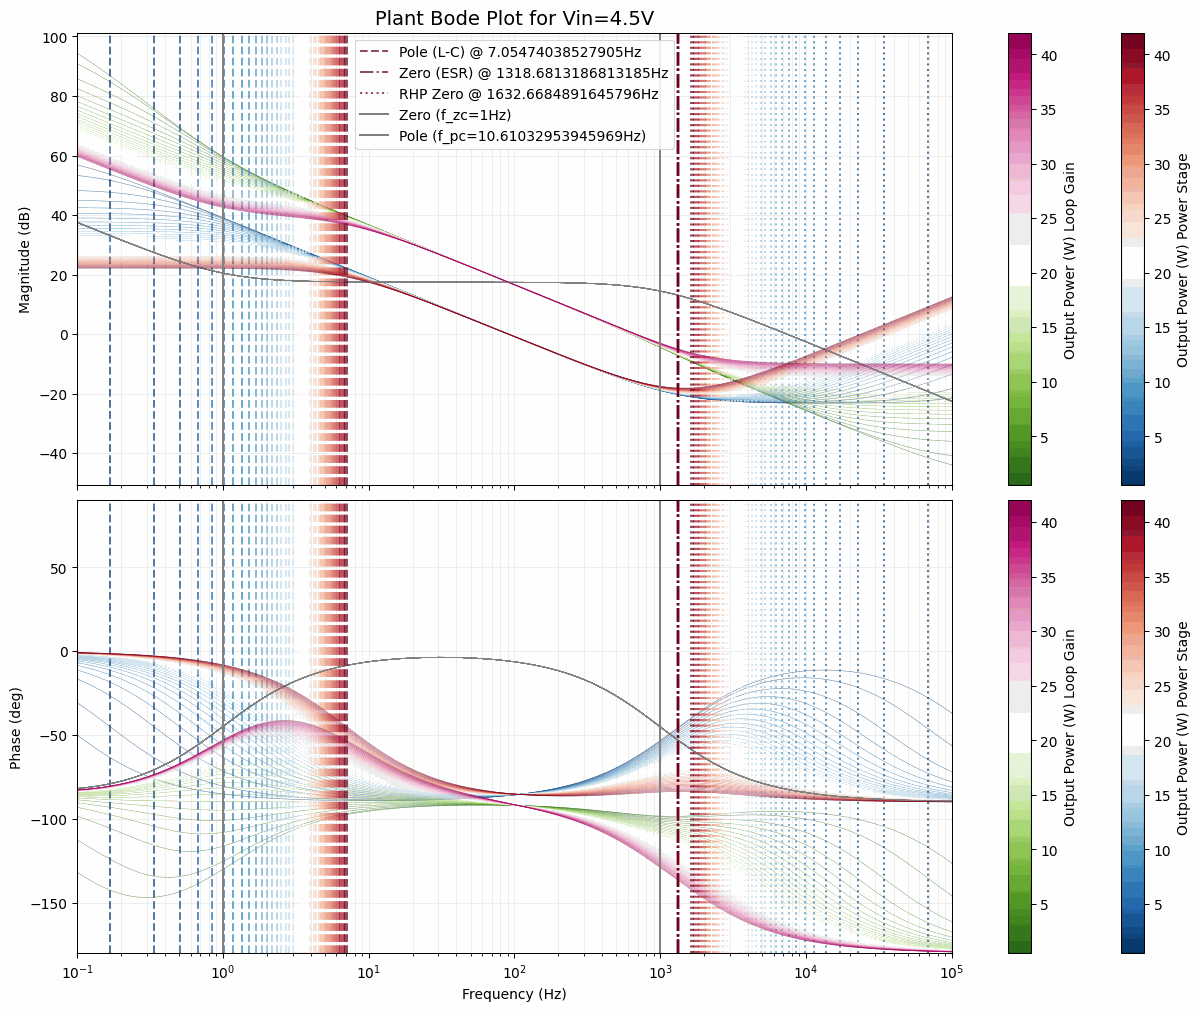

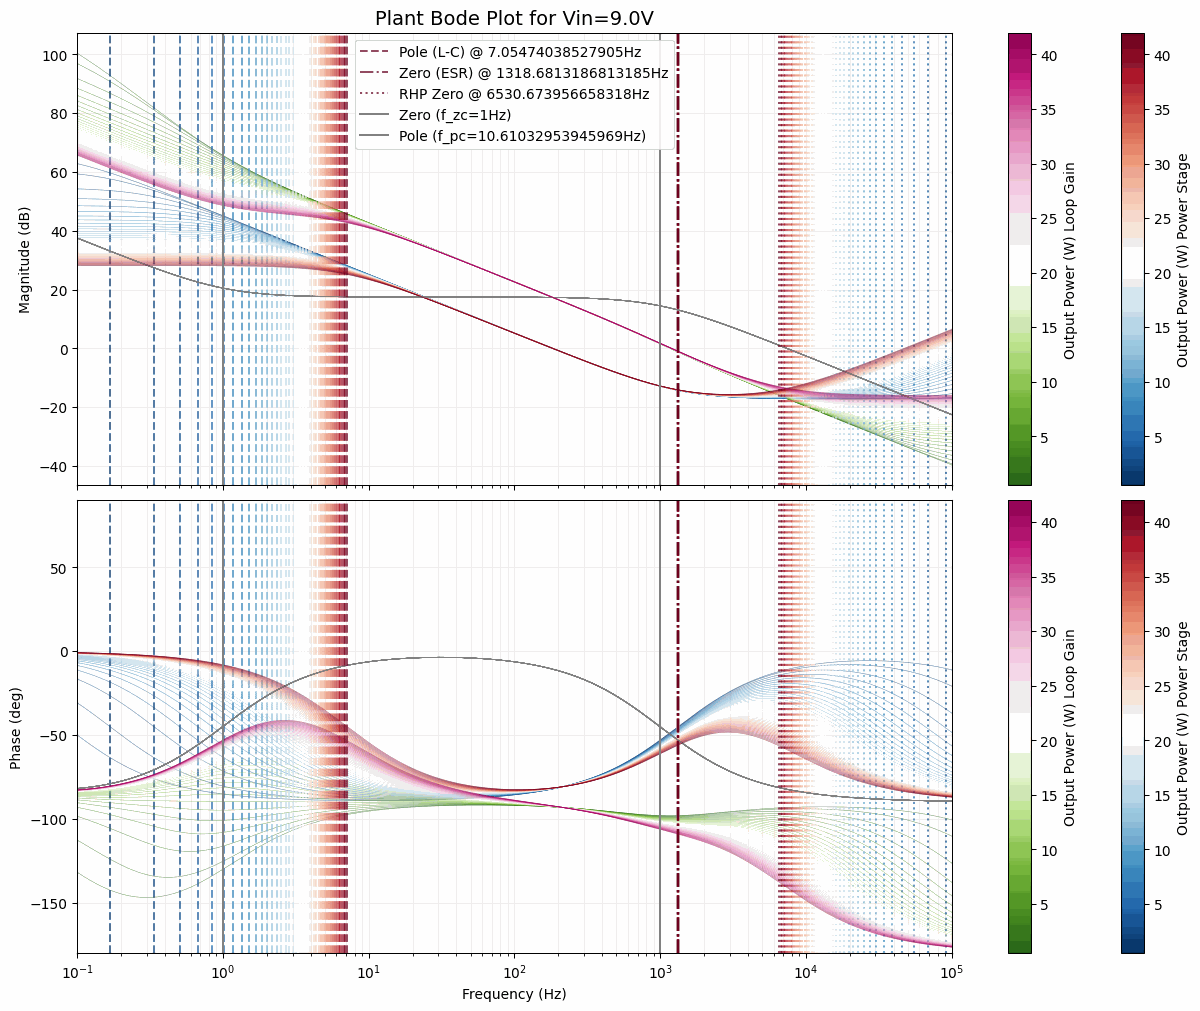

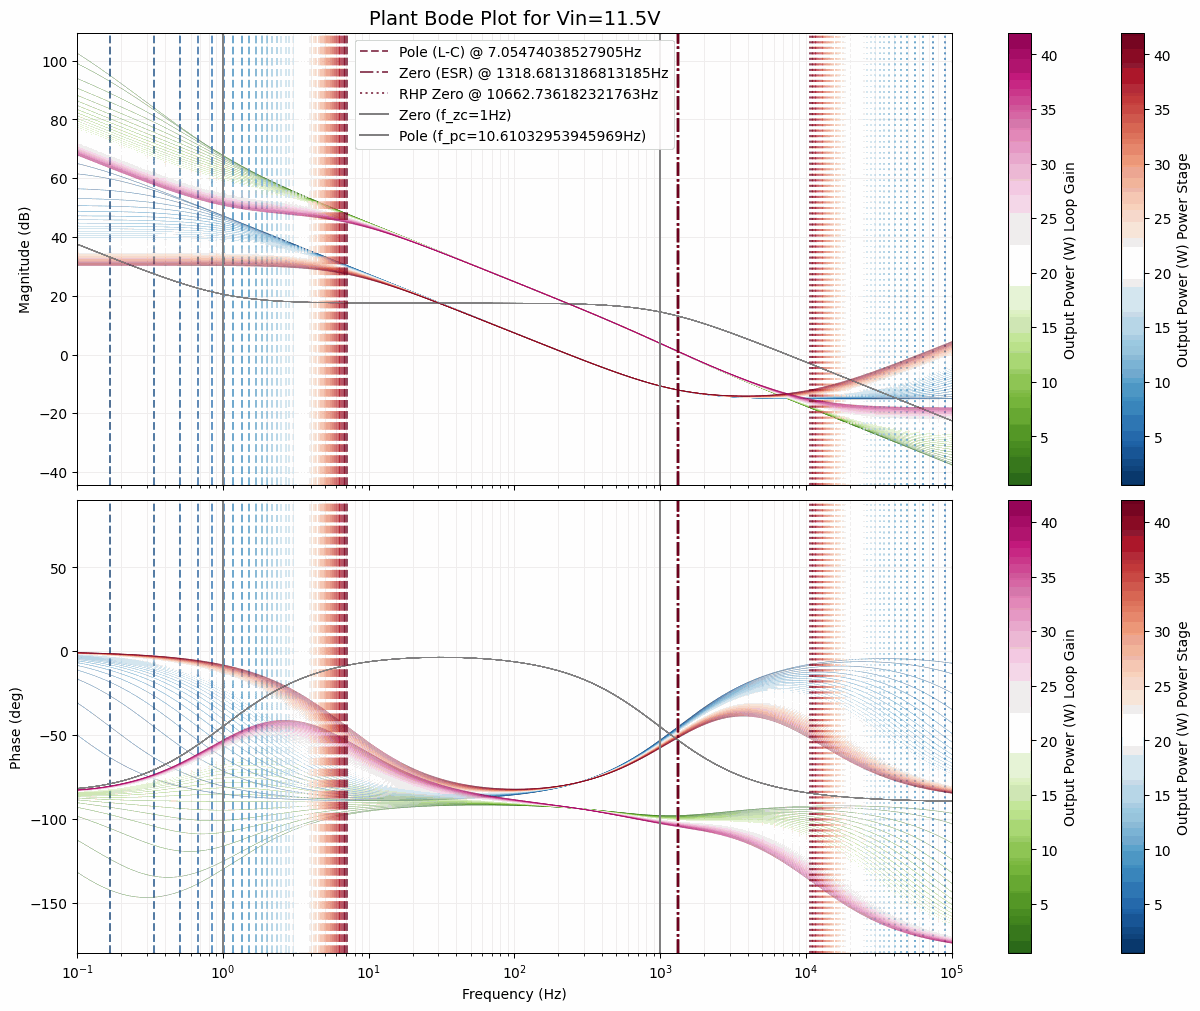

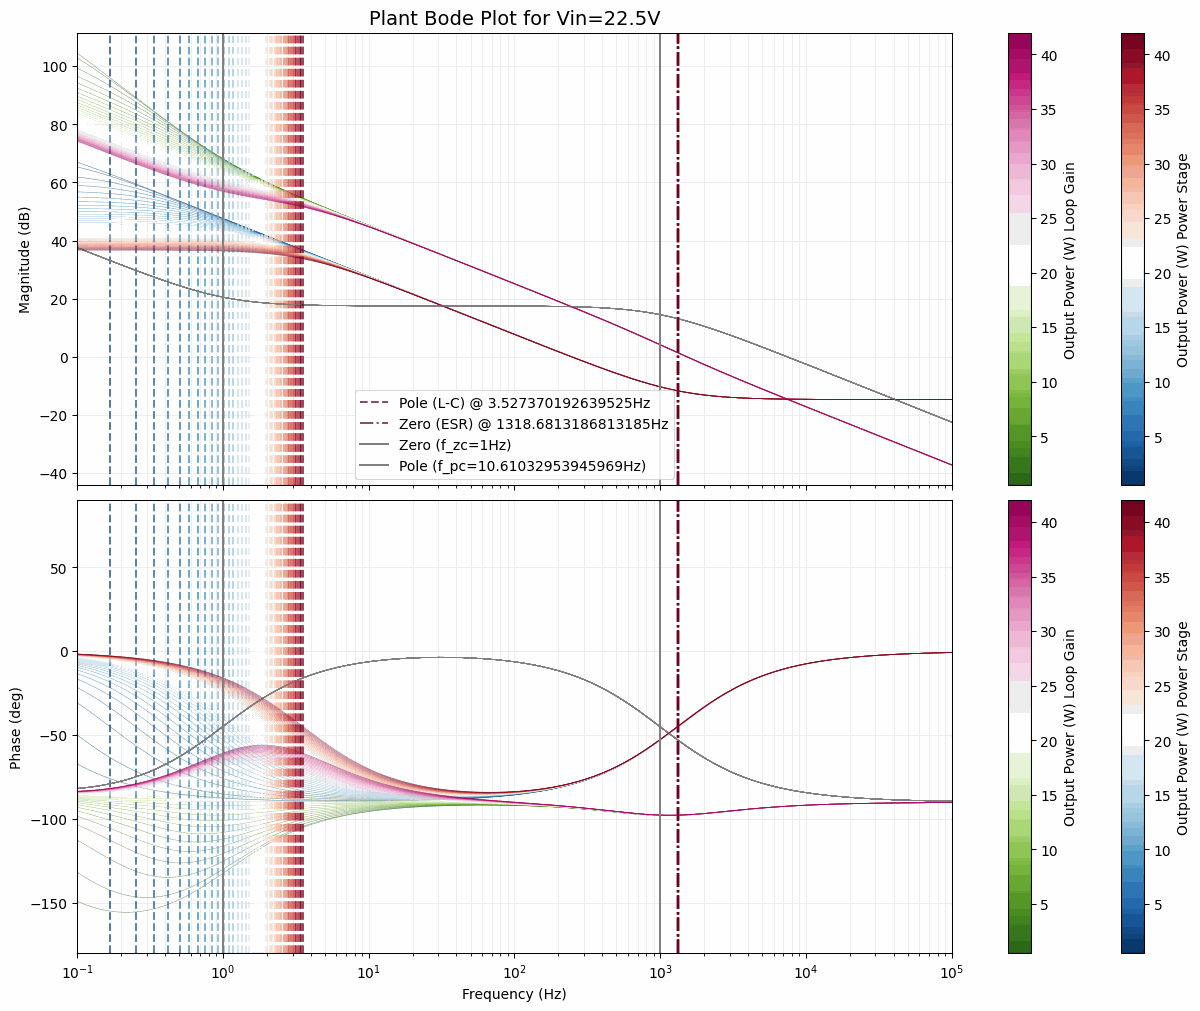

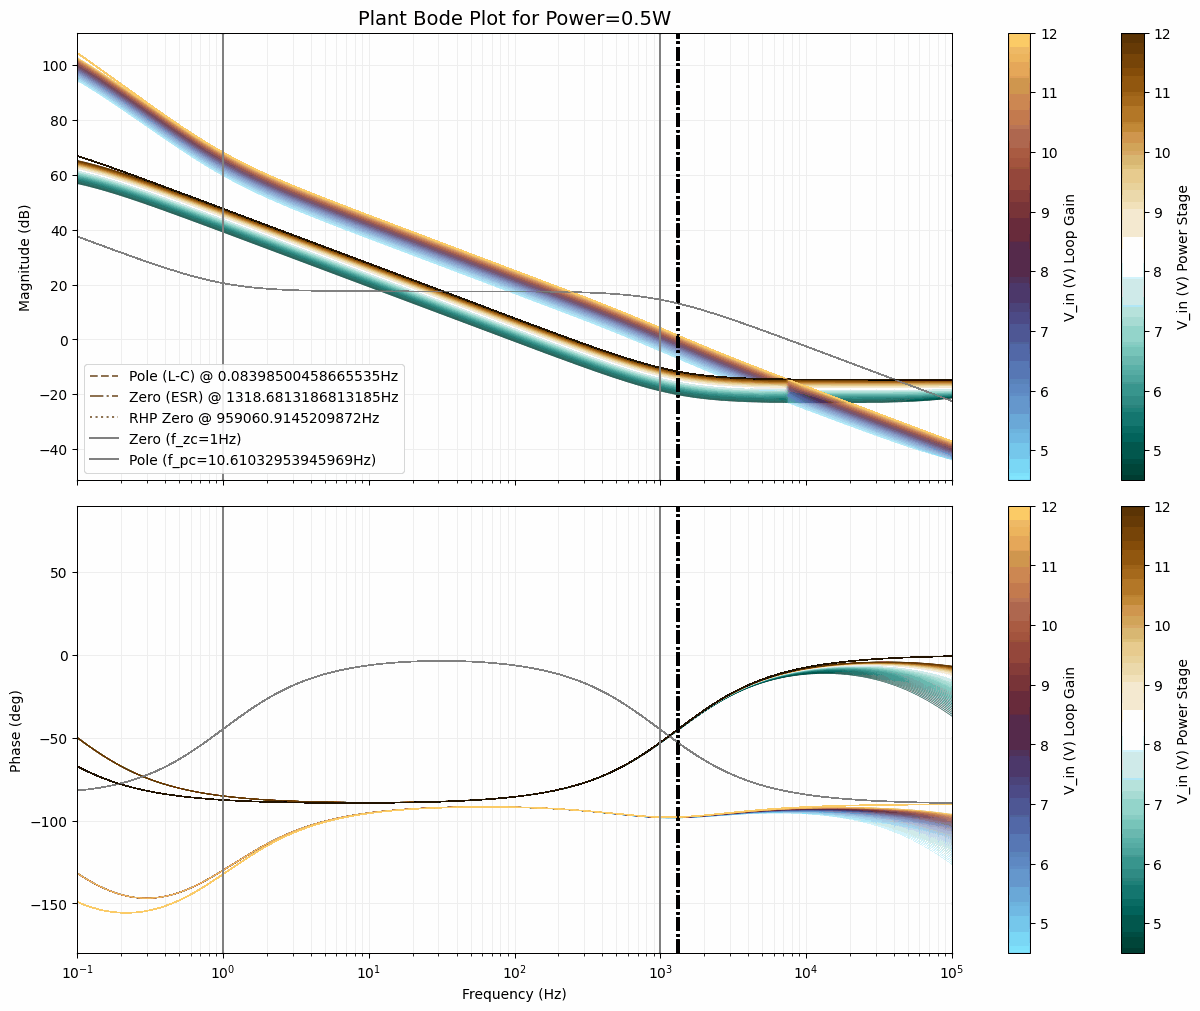

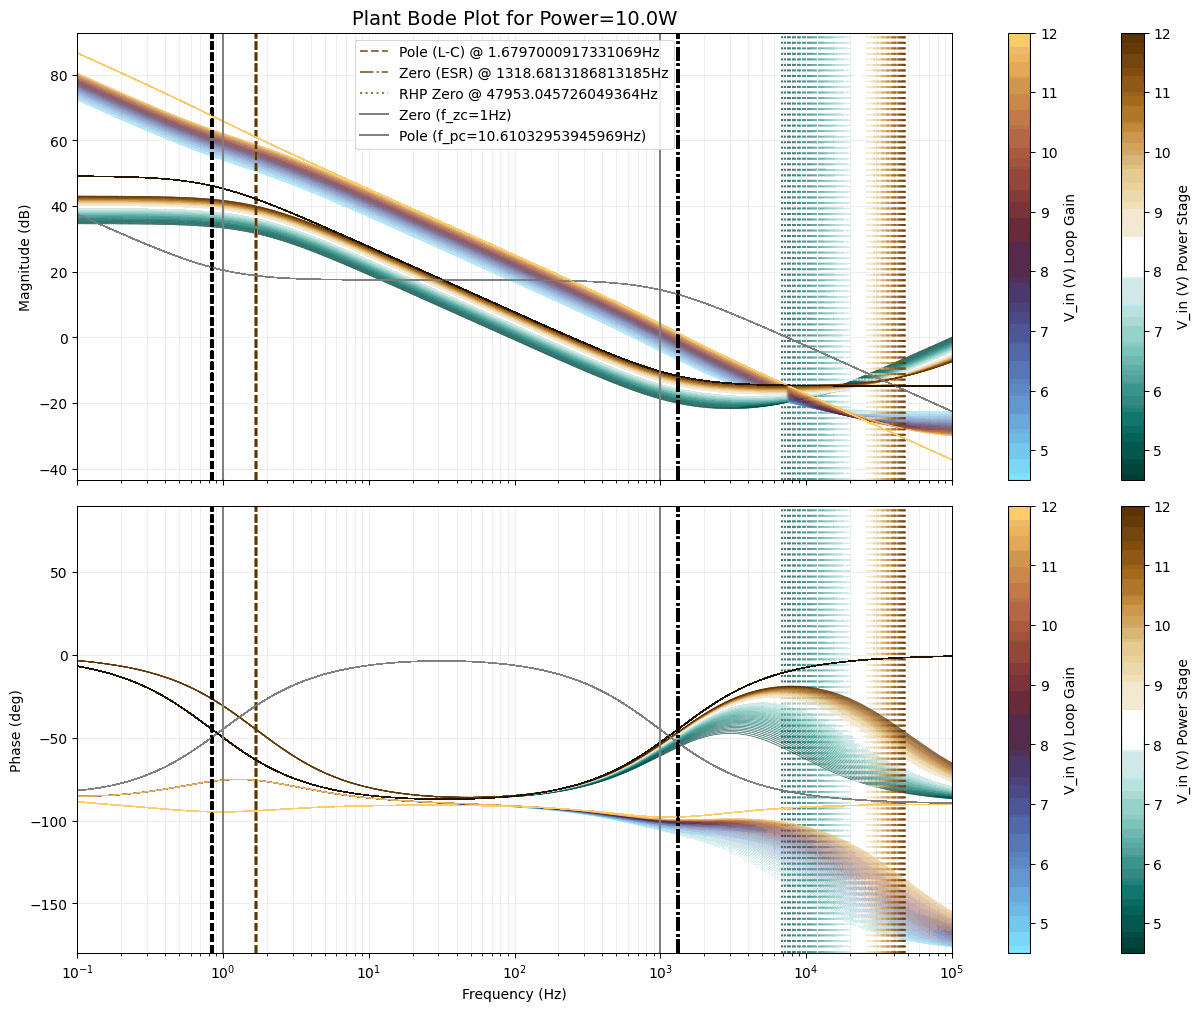

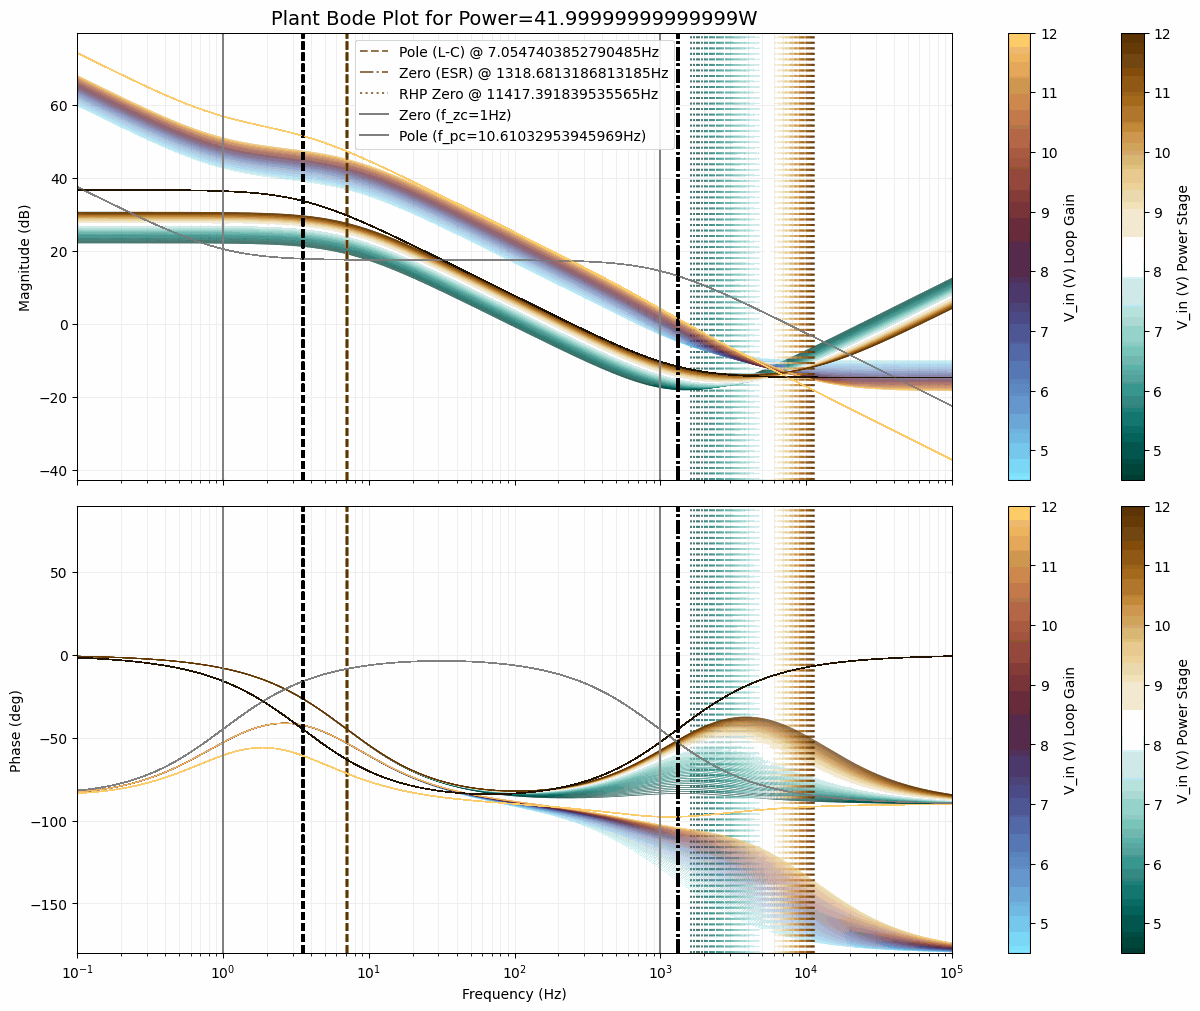

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as colors
from scipy import signal

# --- 1. Flatten the Mesh for Iteration ---
v_in_flat = VIN.flatten()
r_out_flat = R_OUT.flatten()
d_boost_flat = D_BOOST.flatten()

v_in_array_boost = np.arange(4.5, 12.0, 0.1) # finer resolution for color mapping
v_in_array_buck = np.arange(12.1, 22.6, 0.1)
v_in_array = np.concatenate((v_in_array_boost, v_in_array_buck))
power_few = np.asarray([0.5, 10, max_load_watts])
r_out_few = v_out ** 2 / power_few

v_in_few_boost = np.asarray([4.5, 9, 11.5])
v_in_few_buck = np.asarray([22.5]) # current mode buck power stage gain is not affect by vin
v_in_few = np.concatenate((v_in_few_boost, v_in_few_buck))
power_array = np.arange(1, max_load_watts + 1, 1)
power_array = np.insert(power_array, 0, 0.5) # add very light load point for better visualization of low power region
r_out_array = v_out ** 2 / power_array


# Setup Frequency Range
w_hz = np.logspace(-1, 5, 1000)
w_rad = 2 * np.pi * w_hz

f_bw_implemented = 680 # Desired bandwidth for compensation design (Hz)
f_zc_implemented = 1
f_pc2_implemented = 1000
Rc_implemented = 2 * np.pi * f_bw_implemented / gm_ea * (r_fb1 + r_fb2) / r_fb1 * a_cs * r_cs * c_out_chosen_derated / (1 - D_max_boost) # Calculate Rc based on desired bandwidth and Cc
print(f"gm_ea: {gm_ea*1e3:.2f} mS")
print(f"r_fb1: {r_fb1:.2f} Ohms")
print(f"r_fb2: {r_fb2:.2f} Ohms")
print(f"c_out_chosen_derated: {c_out_chosen_derated*1e6:.2f} uF")
print(f"D_max_boost: {D_max_boost:.2f}")
print(f"a_cs: {a_cs:.2f}")
print(f"r_cs: {r_cs:.2f} Ohms")
Cc_implemented = 1 / (2 * np.pi * f_zc_implemented * Rc_implemented) # Calculate Cc based on desired zero frequency and Rc
Chf_implemented = 1 / (2 * np.pi * f_pc2_implemented * Rc_implemented) # Calculate Cc based on desired zero frequency and Rc
print(f"Calculated Rc: {Rc_implemented*1e-3:.2f} kOhms")
print(f"Calculated Cc: {Cc_implemented*1e6:.2f} uF")
print(f"Calculated Chf: {Chf_implemented*1e9:.2f} nF")
#f_zc_implemented = 1 / (2 * np.pi * Rc_implemented * Cc_implemented)
#f_pc_implemented = 1 / (2 * np.pi * Rc_implemented * Chf_implemented)

gain_dc_comp = r_fb1 / (r_fb1 + r_fb2) * gm_ea * r_out_ea
num = [gain_dc_comp * i for i in [Rc_implemented * Cc_implemented, 1]]
# Denominator coefficients: s^2 * [r_fb2 * (Cc+Chf) * Rc * Cc * Chf / (Cc+Chf)] + s * [r_fb2 * (Cc+Chf)] + 0
#den = [r_fb2 * Rc_implemented * Cc_implemented * Chf_implemented, r_fb2 * (Cc_implemented + Chf_implemented), 0]
den = np.polymul([Rc_implemented * Chf_implemented, 1], [r_out_ea * Cc_implemented, 1])
print(f"Compensator Gain (DC): {gain_dc_comp:.2f}")
print(f"Compensator Pole1 Frequency: {1 / (2 * np.pi * r_out_ea * Cc_implemented):.2f} Hz")
print(f"Compensator Zero Frequency: {f_zc_implemented:.2f} Hz (defined by design)")
print(f"Compensator Zero Frequency: {1 / (2 * np.pi * Rc_implemented * Cc_implemented):.2f} Hz")
print(f"Compensator Pole2 Frequency: {f_pc2_implemented:.2f} Hz (defined by design)")
print(f"Compensator Pole2 Frequency: {1 / (2 * np.pi * Rc_implemented * Chf_implemented):.2f} Hz")
sys_comp = signal.TransferFunction(num, den)


for v_in_step in v_in_few:
    fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, layout='constrained')
    ax_mag.grid(True, which="both", alpha=0.2)
    ax_phase.grid(True, which="both", alpha=0.2)
    # Define range and colormap
    norm = colors.Normalize(vmin=np.min(power_array), vmax=np.max(power_array))
    cmap = mpl.colormaps['RdBu_r'] #cmap = cm.get_cmap('RdBu_r') # Red for high power/ blue for low
    cmap2 = mpl.colormaps['PiYG_r'] # for total system response
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_mag, label='Output Power (W) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_mag, label='Output Power (W) Loop Gain')
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_phase, label='Output Power (W) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_phase, label='Output Power (W) Loop Gain')
    ax_mag.set_title(f'Plant Bode Plot for Vin={v_in_step}V', fontsize=14)
    for r_out_i, power_i in zip(r_out_array, power_array):
        # Recalculate local Pole/Zero
        # Boost Pole: 2 / (2*pi*R*C)
        if (v_in_step < v_out): # oost mode
            wp = 2 / (r_out_i * c_out_chosen_derated)
            # RHP Zero: (R * (Vin/Vout)^2) / (2*pi*L)
            wrhp = 2 * np.pi * ((r_out_i * (v_in_step/v_out)**2) / (2 * np.pi * L1))
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 2  # slope compensation factor
            _duty = 1 - v_in_step / v_out
            gain_linear = (r_out_i * (1 - _duty)) / (r_cs * a_cs * kd)
            
            # Construct TF
            num = gain_linear * np.polymul([1/wz_esr, 1], [-1/wrhp, 1])
            den = [1/wp, 1]
        elif (v_in_step > v_out): # Buck mode
            wp = 1 / (r_out_i * c_out_chosen_derated)            
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 1  # slope compensation factor
            gain_linear = r_out_i / (r_cs * a_cs * kd)
            
            # Construct TF
            num = [gain_linear * i for i in [1/wz_esr, 1]]
            den = [1/wp, 1]
        sys = signal.TransferFunction(num, den)
        num_total = np.polymul(sys.num, sys_comp.num)
        den_total = np.polymul(sys.den, sys_comp.den)
        sys_total = signal.TransferFunction(num_total, den_total)
        
        _, mag_total, phase_total = signal.bode(sys_total, w=w_rad)

        # Calculate Bode
        _, mag, phase = signal.bode(sys, w=w_rad)
        _, mag_comp, phase_comp = signal.bode(sys_comp, w=w_rad)
        _, mag_total, phase_total = signal.bode(sys_total, w=w_rad)
        # Plot with high transparency (alpha)
        ax_mag.semilogx(w_hz, mag, color=cmap(norm(power_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_total, color=cmap2(norm(power_i)), alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase, color=cmap(norm(power_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_total, color=cmap2(norm(power_i)), alpha=0.5, linewidth=0.5)

        if (v_in_step < v_out): # boost mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot'),
                'RHP Zero': (wrhp/2/np.pi, 'dotted')
            }
        elif (v_in_step > v_out): # buck mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot')
            }
        for label, (freq, style) in features.items():
            # Add vertical lines to both plots
            for ax in [1, 2]:
                plt.subplot(2, 1, ax)
                if (power_i == power_array[-1]):
                    plt.axvline(freq, color=cmap(norm(power_i)), linestyle=style, alpha=0.7, label=f'{label} @ {freq}Hz')
                else:
                    plt.axvline(freq, color=cmap(norm(power_i)), linestyle=style, alpha=0.7)
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={f_zc_implemented}Hz)')
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={f_pc_implemented}Hz)')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={f_zc_implemented}Hz)')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={f_pc_implemented}Hz)')
    ax_mag.legend()
    ax_mag.set_ylabel('Magnitude (dB)')
    ax_phase.set_ylabel('Phase (deg)')
    ax_phase.set_xlabel('Frequency (Hz)')
    ax_mag.set_xlim(0.1, 1e5)
    ax_phase.set_xlim(0.1, 1e5)
    ax_phase.set_ylim(-180, 90) # Standard range for stability check
for power_step, r_out_step in zip(power_few, r_out_few) :
    fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, layout='constrained')
    ax_mag.grid(True, which="both", alpha=0.2)
    ax_phase.grid(True, which="both", alpha=0.2)
    # Define range and colormap
    norm = colors.Normalize(vmin=np.min(v_in_array), vmax=np.max(v_out)) # buck mode is not affected by vin
    cmap = mpl.colormaps['BrBG_r'] #cmap = cm.get_cmap('RdBu_r') # Red for high power/ blue for low
    cmap2 = mpl.colormaps['managua_r'] # for total system response
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_mag, label='V_in (V) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_mag, label='V_in (V) Loop Gain')
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_phase, label='V_in (V) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_phase, label='V_in (V) Loop Gain')
    ax_mag.set_title(f'Plant Bode Plot for Power={power_step}W', fontsize=14)
    for v_in_i in v_in_array:
        if (v_in_i < v_out): # boost mode
            # Recalculate local Pole/Zero
            # Boost Pole: 2 / (2*pi*R*C)
            wp = 2 * np.pi * (2 / (2 * np.pi * r_out_step * c_out_chosen_derated))
            # RHP Zero: (R * (Vin/Vout)^2) / (2*pi*L)
            wrhp = 2 * np.pi * ((r_out_step * (v_in_i/v_out)**2) / (2 * np.pi * L1))
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 2  # slope compensation factor
            _duty = 1 - v_in_i / v_out
            gain_linear = (r_out_step * (1 - _duty)) / (r_cs * a_cs * kd)
            
            # Construct TF
            num = gain_linear * np.polymul([1/wz_esr, 1], [-1/wrhp, 1])
            den = [1/wp, 1]
        elif (v_in_i > v_out): # Buck mode
            # Recalculate local Pole/Zero
            wp = 1 / (r_out_step * c_out_chosen_derated)           
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 1  # slope compensation factor
            gain_linear = r_out_step / (r_cs * a_cs * kd)
            
            # Construct TF
            num = [gain_linear * i for i in [1/wz_esr, 1]]
            den = [1/wp, 1]
        sys = signal.TransferFunction(num, den)
        
        num_total = np.polymul(sys.num, sys_comp.num)
        den_total = np.polymul(sys.den, sys_comp.den)
        sys_total = signal.TransferFunction(num_total, den_total)

        # Calculate Bode
        _, mag, phase = signal.bode(sys, w=w_rad)
        _, mag_comp, phase_comp = signal.bode(sys_comp, w=w_rad)
        _, mag_total, phase_total = signal.bode(sys_total, w=w_rad)
        # Plot with high transparency (alpha)
        ax_mag.semilogx(w_hz, mag, color=cmap(norm(v_in_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_total, color=cmap2(norm(v_in_i)), alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase, color=cmap(norm(v_in_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_total, color=cmap2(norm(v_in_i)), alpha=0.5, linewidth=0.5)

        # Plot with high transparency (alpha)
        if (v_in_i < v_out): # boost mode
            _color = cmap(norm(v_in_i))
        else: # buck mode
            _color = 'black'
        
        ax_mag.semilogx(w_hz, mag, color=_color, alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase, color=_color, alpha=0.5, linewidth=0.5)

        if (v_in_i < v_out): # boost mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot'),
                'RHP Zero': (wrhp/2/np.pi, 'dotted')
            }
        elif (v_in_step > v_out): # buck mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot')
            }
        for label, (freq, style) in features.items():
            # Add vertical lines to both plots
            for ax in [1, 2]:
                plt.subplot(2, 1, ax)
                if (v_in_i == v_in_array_boost[-1]):
                    plt.axvline(freq, color=_color, linestyle=style, alpha=0.7, label=f'{label} @ {freq}Hz')
                else:
                    plt.axvline(freq, color=_color, linestyle=style, alpha=0.7)
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={f_zc_implemented}Hz)')
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={f_pc_implemented}Hz)')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={f_zc_implemented}Hz)')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={f_pc_implemented}Hz)')
    ax_mag.legend()
    ax_mag.set_ylabel('Magnitude (dB)')
    ax_phase.set_ylabel('Phase (deg)')
    ax_phase.set_xlabel('Frequency (Hz)')
    ax_mag.set_xlim(0.1, 1e5)
    ax_phase.set_xlim(0.1, 1e5)
    ax_phase.set_ylim(-180, 90) # Standard range for stability check
    plt.show()


### Chosen modification for PCB v1

In [20]:
def format_freq(freq):
    """Formats a frequency value into 3 significant figures with Hz or kHz."""
    if freq >= 1000:
        return f"{freq/1000:.3g}kHz"
    else:
        return f"{freq:.3g}Hz"

Calculated Rc: 2.00 kOhms
Calculated Cc: 10.00 uF
Calculated Chf: 150.00 nF
Compensator Gain (DC): 1746.67
Compensator Pole1 Frequency: 0.00 Hz
Compensator Zero Frequency: 7.96 Hz
Compensator Pole2 Frequency: 530.52 Hz


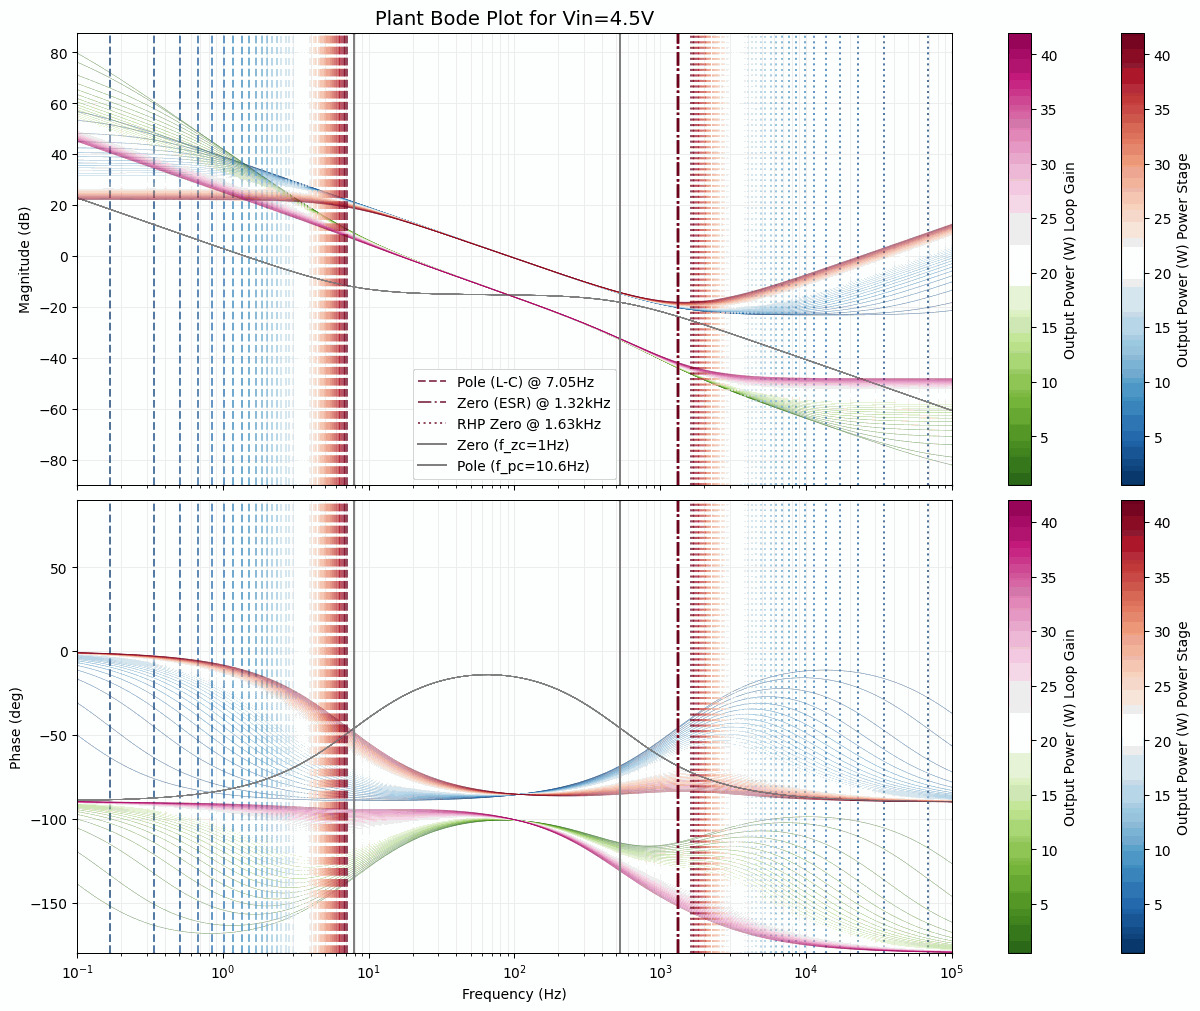

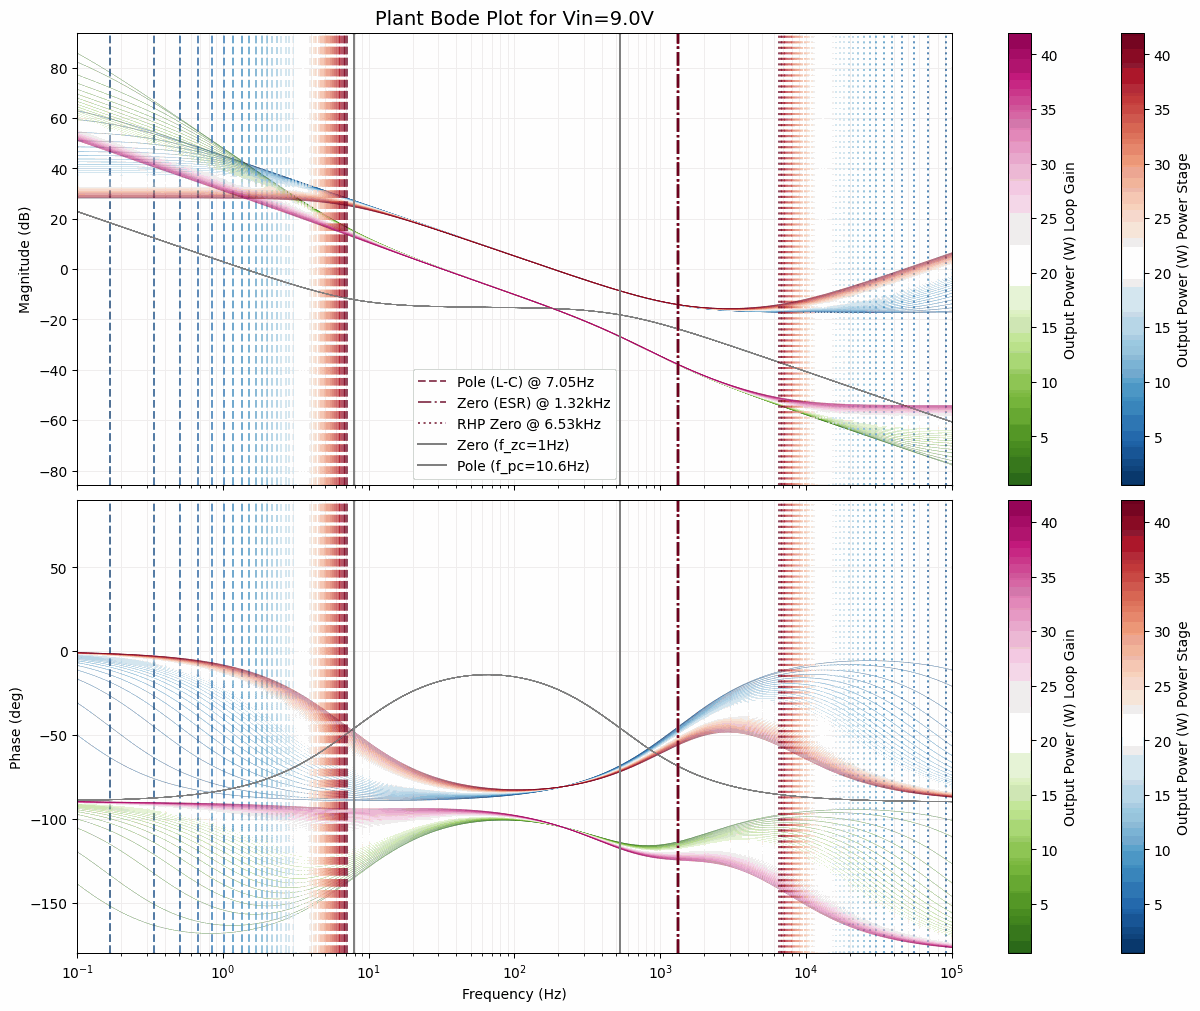

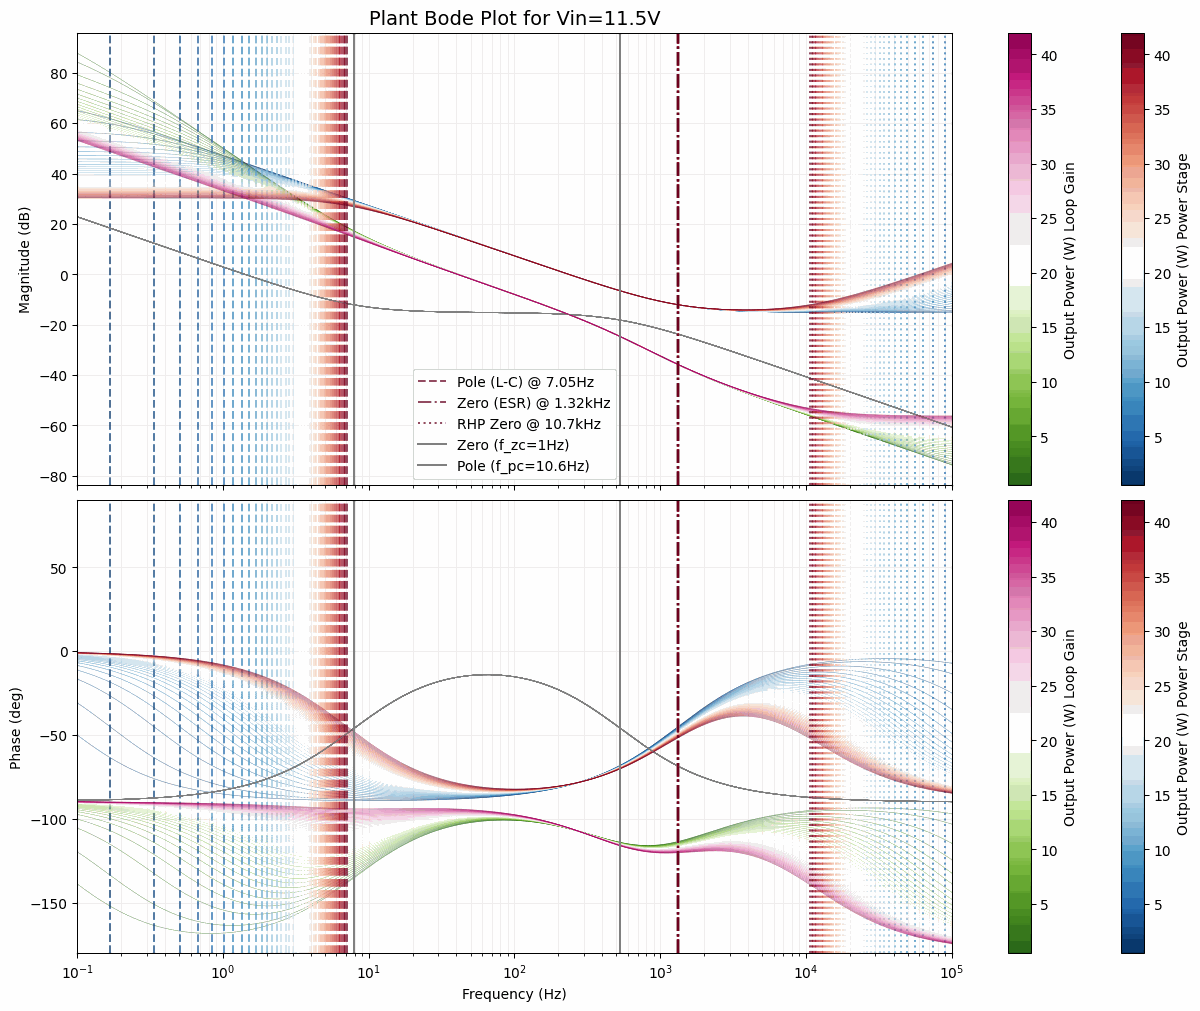

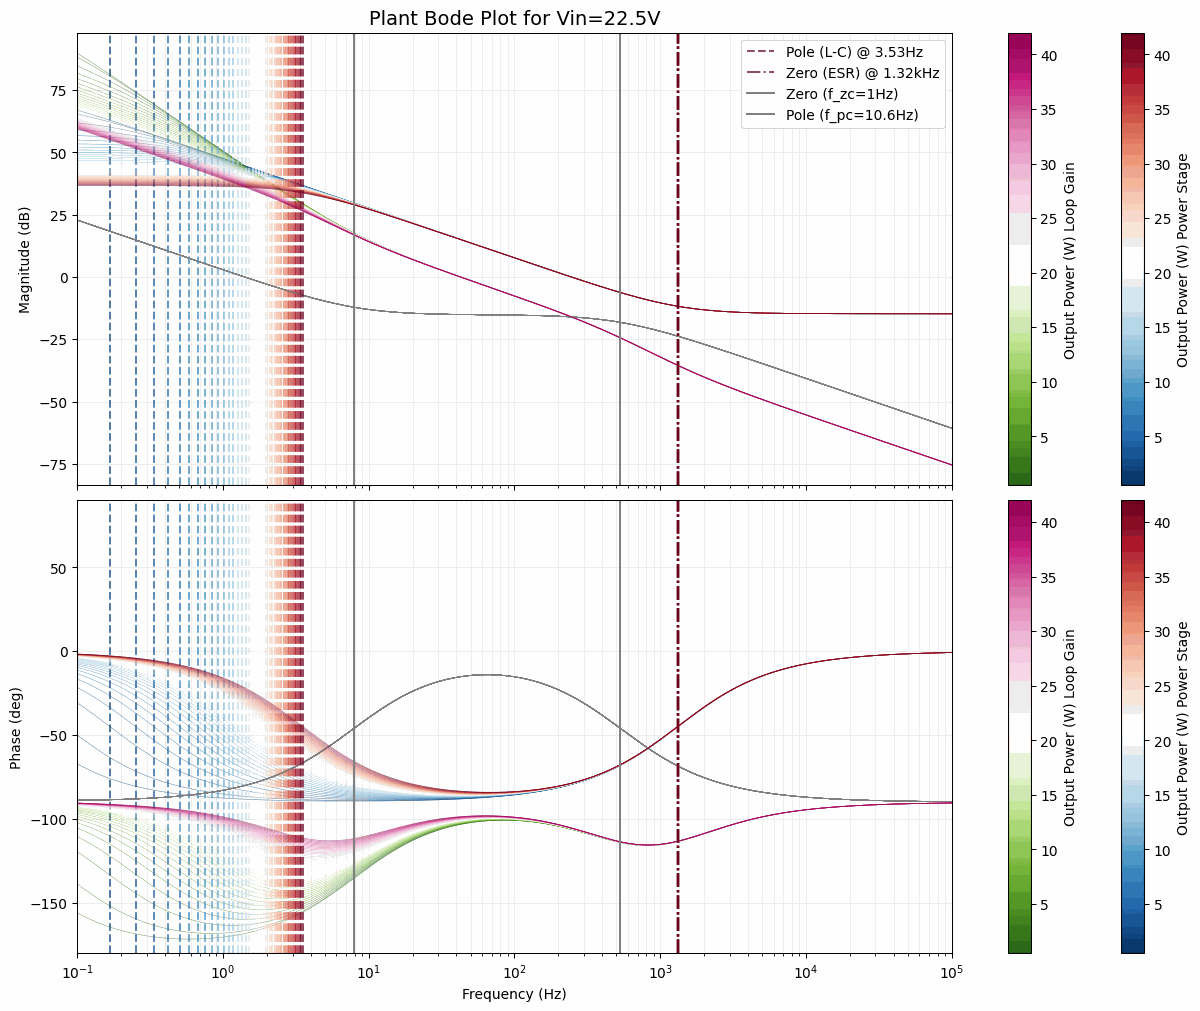

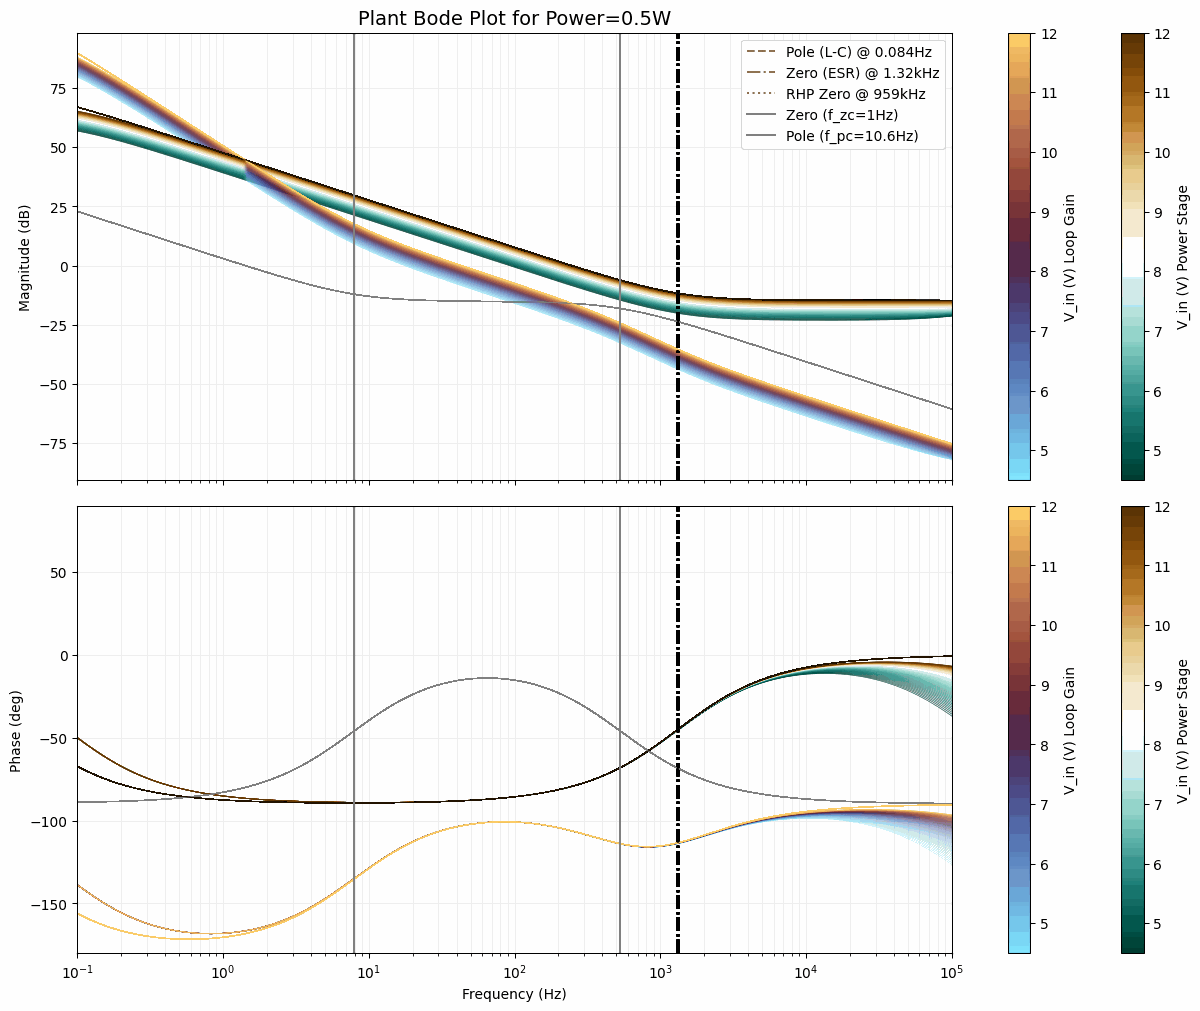

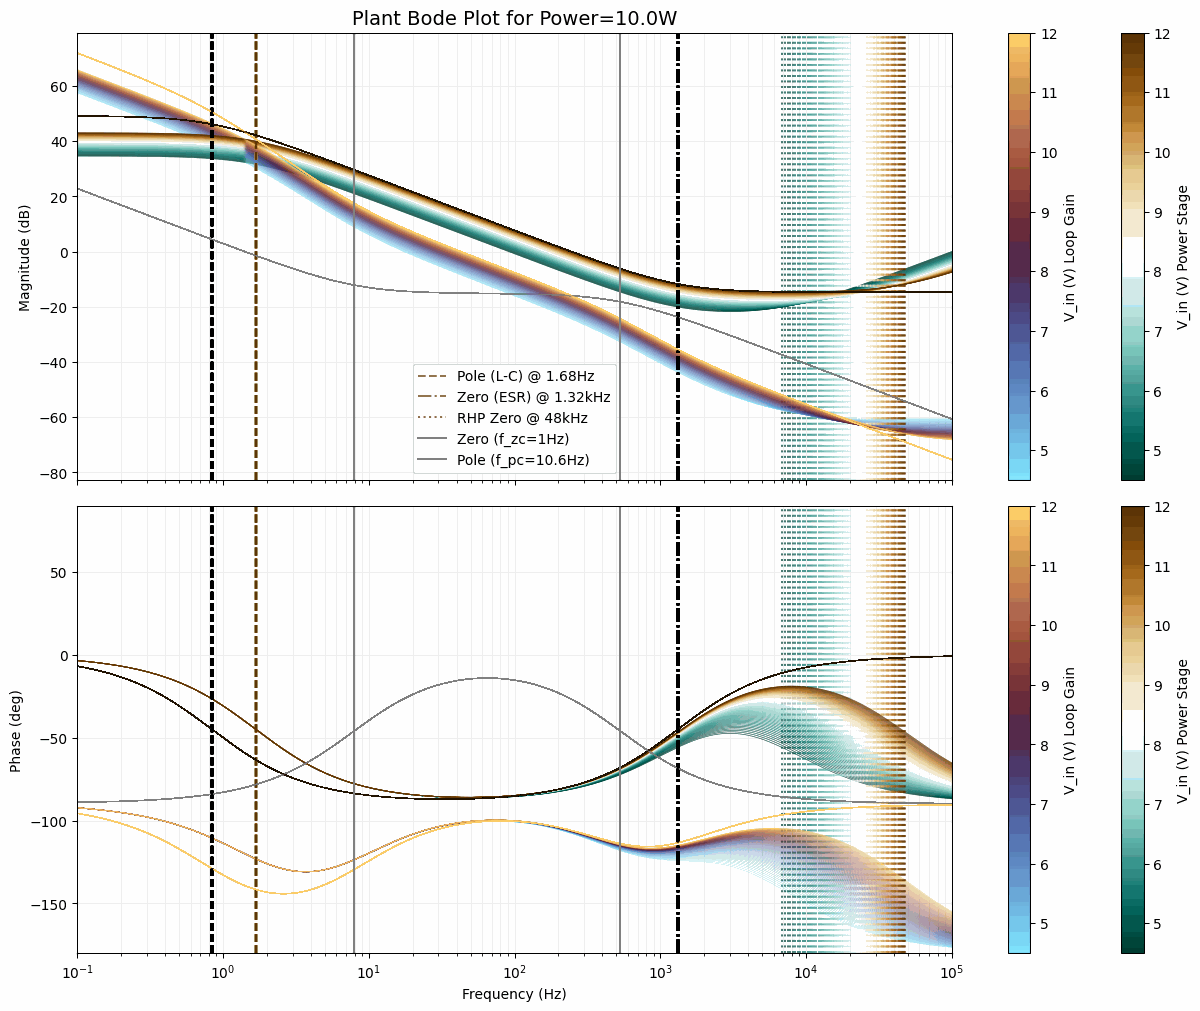

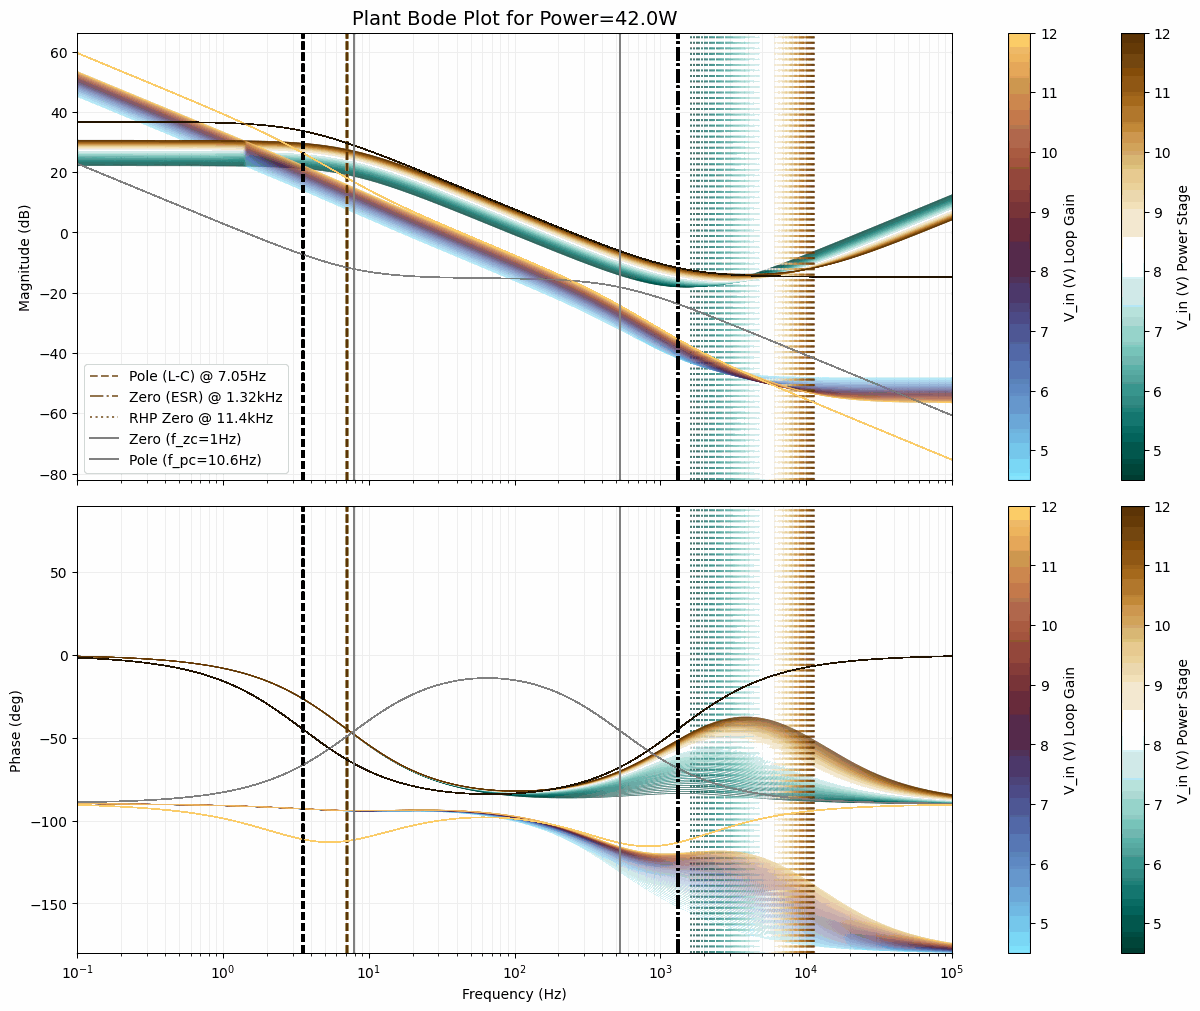

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as colors
from scipy import signal

# --- 1. Flatten the Mesh for Iteration ---
v_in_flat = VIN.flatten()
r_out_flat = R_OUT.flatten()
d_boost_flat = D_BOOST.flatten()

v_in_array_boost = np.arange(4.5, 12.0, 0.1) # finer resolution for color mapping
v_in_array_buck = np.arange(12.1, 22.6, 0.1)
v_in_array = np.concatenate((v_in_array_boost, v_in_array_buck))
power_few = np.asarray([0.5, 10, max_load_watts])
r_out_few = v_out ** 2 / power_few

v_in_few_boost = np.asarray([4.5, 9, 11.5])
v_in_few_buck = np.asarray([22.5]) # current mode buck power stage gain is not affect by vin
v_in_few = np.concatenate((v_in_few_boost, v_in_few_buck))
power_array = np.arange(1, max_load_watts + 1, 1)
power_array = np.insert(power_array, 0, 0.5) # add very light load point for better visualization of low power region
r_out_array = v_out ** 2 / power_array


# Setup Frequency Range
w_hz = np.logspace(-1, 5, 1000)
w_rad = 2 * np.pi * w_hz

#f_bw_implemented = 680 # Desired bandwidth for compensation design (Hz)
#f_zc_implemented = 1
#f_pc2_implemented = 1000
Rc_implemented = 2e3 ### change this for lower gain to get low bw to ignore commutation
Cc_implemented = 10e-6 ### need to change this to lower zero frequency
Chf_implemented = 150e-9 ### need to change this component for better high frequency roll-off
print(f"Calculated Rc: {Rc_implemented*1e-3:.2f} kOhms")
print(f"Calculated Cc: {Cc_implemented*1e6:.2f} uF")
print(f"Calculated Chf: {Chf_implemented*1e9:.2f} nF")
#f_zc_implemented = 1 / (2 * np.pi * Rc_implemented * Cc_implemented)
#f_pc_implemented = 1 / (2 * np.pi * Rc_implemented * Chf_implemented)

gain_dc_comp = r_fb1 / (r_fb1 + r_fb2) * gm_ea * r_out_ea
num = [gain_dc_comp * i for i in [Rc_implemented * Cc_implemented, 1]]
# Denominator coefficients: s^2 * [r_fb2 * (Cc+Chf) * Rc * Cc * Chf / (Cc+Chf)] + s * [r_fb2 * (Cc+Chf)] + 0
#den = [r_fb2 * Rc_implemented * Cc_implemented * Chf_implemented, r_fb2 * (Cc_implemented + Chf_implemented), 0]
den = np.polymul([Rc_implemented * Chf_implemented, 1], [r_out_ea * Cc_implemented, 1])
print(f"Compensator Gain (DC): {gain_dc_comp:.2f}")
print(f"Compensator Pole1 Frequency: {1 / (2 * np.pi * r_out_ea * Cc_implemented):.2f} Hz")
#print(f"Compensator Zero Frequency: {f_zc_implemented:.2f} Hz (defined by design)")
print(f"Compensator Zero Frequency: {1 / (2 * np.pi * Rc_implemented * Cc_implemented):.2f} Hz")
#print(f"Compensator Pole2 Frequency: {f_pc2_implemented:.2f} Hz (defined by design)")
print(f"Compensator Pole2 Frequency: {1 / (2 * np.pi * Rc_implemented * Chf_implemented):.2f} Hz")
sys_comp = signal.TransferFunction(num, den)


for v_in_step in v_in_few:
    fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, layout='constrained')
    ax_mag.grid(True, which="both", alpha=0.2)
    ax_phase.grid(True, which="both", alpha=0.2)
    # Define range and colormap
    norm = colors.Normalize(vmin=np.min(power_array), vmax=np.max(power_array))
    cmap = mpl.colormaps['RdBu_r'] #cmap = cm.get_cmap('RdBu_r') # Red for high power/ blue for low
    cmap2 = mpl.colormaps['PiYG_r'] # for total system response
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_mag, label='Output Power (W) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_mag, label='Output Power (W) Loop Gain')
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_phase, label='Output Power (W) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_phase, label='Output Power (W) Loop Gain')
    ax_mag.set_title(f'Plant Bode Plot for Vin={v_in_step}V', fontsize=14)
    for r_out_i, power_i in zip(r_out_array, power_array):
        # Recalculate local Pole/Zero
        # Boost Pole: 2 / (2*pi*R*C)
        if (v_in_step < v_out): # oost mode
            wp = 2 / (r_out_i * c_out_chosen_derated)
            # RHP Zero: (R * (Vin/Vout)^2) / (2*pi*L)
            wrhp = 2 * np.pi * ((r_out_i * (v_in_step/v_out)**2) / (2 * np.pi * L1))
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 2  # slope compensation factor
            _duty = 1 - v_in_step / v_out
            gain_linear = (r_out_i * (1 - _duty)) / (r_cs * a_cs * kd)
            
            # Construct TF
            num = gain_linear * np.polymul([1/wz_esr, 1], [-1/wrhp, 1])
            den = [1/wp, 1]
        elif (v_in_step > v_out): # Buck mode
            wp = 1 / (r_out_i * c_out_chosen_derated)            
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 1  # slope compensation factor
            gain_linear = r_out_i / (r_cs * a_cs * kd)
            
            # Construct TF
            num = [gain_linear * i for i in [1/wz_esr, 1]]
            den = [1/wp, 1]
        sys = signal.TransferFunction(num, den)
        num_total = np.polymul(sys.num, sys_comp.num)
        den_total = np.polymul(sys.den, sys_comp.den)
        sys_total = signal.TransferFunction(num_total, den_total)
        
        _, mag_total, phase_total = signal.bode(sys_total, w=w_rad)

        # Calculate Bode
        _, mag, phase = signal.bode(sys, w=w_rad)
        _, mag_comp, phase_comp = signal.bode(sys_comp, w=w_rad)
        _, mag_total, phase_total = signal.bode(sys_total, w=w_rad)
        # Plot with high transparency (alpha)
        ax_mag.semilogx(w_hz, mag, color=cmap(norm(power_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_total, color=cmap2(norm(power_i)), alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase, color=cmap(norm(power_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_total, color=cmap2(norm(power_i)), alpha=0.5, linewidth=0.5)

        if (v_in_step < v_out): # boost mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot'),
                'RHP Zero': (wrhp/2/np.pi, 'dotted')
            }
        elif (v_in_step > v_out): # buck mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot')
            }
        for label, (freq, style) in features.items():
            # Add vertical lines to both plots
            for ax in [1, 2]:
                plt.subplot(2, 1, ax)
                if (power_i == power_array[-1]):
                    plt.axvline(freq, color=cmap(norm(power_i)), linestyle=style, alpha=0.7, label=f'{label} @ {format_freq(freq)}')
                else:
                    plt.axvline(freq, color=cmap(norm(power_i)), linestyle=style, alpha=0.7)
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={format_freq(f_zc_implemented)})')
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={format_freq(f_pc_implemented)})')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={format_freq(f_zc_implemented)})')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={format_freq(f_pc_implemented)})')
    ax_mag.legend()
    ax_mag.set_ylabel('Magnitude (dB)')
    ax_phase.set_ylabel('Phase (deg)')
    ax_phase.set_xlabel('Frequency (Hz)')
    ax_mag.set_xlim(0.1, 1e5)
    ax_phase.set_xlim(0.1, 1e5)
    ax_phase.set_ylim(-180, 90) # Standard range for stability check
for power_step, r_out_step in zip(power_few, r_out_few) :
    fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, layout='constrained')
    ax_mag.grid(True, which="both", alpha=0.2)
    ax_phase.grid(True, which="both", alpha=0.2)
    # Define range and colormap
    norm = colors.Normalize(vmin=np.min(v_in_array), vmax=np.max(v_out)) # buck mode is not affected by vin
    cmap = mpl.colormaps['BrBG_r'] #cmap = cm.get_cmap('RdBu_r') # Red for high power/ blue for low
    cmap2 = mpl.colormaps['managua_r'] # for total system response
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_mag, label='V_in (V) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_mag, label='V_in (V) Loop Gain')
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_phase, label='V_in (V) Power Stage')
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap2), ax=ax_phase, label='V_in (V) Loop Gain')
    ax_mag.set_title(f'Plant Bode Plot for Power={power_step:.1f}W', fontsize=14)
    for v_in_i in v_in_array:
        if (v_in_i < v_out): # boost mode
            # Recalculate local Pole/Zero
            # Boost Pole: 2 / (2*pi*R*C)
            wp = 2 * np.pi * (2 / (2 * np.pi * r_out_step * c_out_chosen_derated))
            # RHP Zero: (R * (Vin/Vout)^2) / (2*pi*L)
            wrhp = 2 * np.pi * ((r_out_step * (v_in_i/v_out)**2) / (2 * np.pi * L1))
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 2  # slope compensation factor
            _duty = 1 - v_in_i / v_out
            gain_linear = (r_out_step * (1 - _duty)) / (r_cs * a_cs * kd)
            
            # Construct TF
            num = gain_linear * np.polymul([1/wz_esr, 1], [-1/wrhp, 1])
            den = [1/wp, 1]
        elif (v_in_i > v_out): # Buck mode
            # Recalculate local Pole/Zero
            wp = 1 / (r_out_step * c_out_chosen_derated)           
            wz_esr = 2 * np.pi * f_z1 # Constant
            
            # Local DC Gain (with slope compensation factor Kd ≈ 2 from SNVA555)
            kd = 1  # slope compensation factor
            gain_linear = r_out_step / (r_cs * a_cs * kd)
            
            # Construct TF
            num = [gain_linear * i for i in [1/wz_esr, 1]]
            den = [1/wp, 1]
        sys = signal.TransferFunction(num, den)
        
        num_total = np.polymul(sys.num, sys_comp.num)
        den_total = np.polymul(sys.den, sys_comp.den)
        sys_total = signal.TransferFunction(num_total, den_total)

        # Calculate Bode
        _, mag, phase = signal.bode(sys, w=w_rad)
        _, mag_comp, phase_comp = signal.bode(sys_comp, w=w_rad)
        _, mag_total, phase_total = signal.bode(sys_total, w=w_rad)
        # Plot with high transparency (alpha)
        ax_mag.semilogx(w_hz, mag, color=cmap(norm(v_in_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_mag.semilogx(w_hz, mag_total, color=cmap2(norm(v_in_i)), alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase, color=cmap(norm(v_in_i)), linestyle='-', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_comp, color='gray', alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase_total, color=cmap2(norm(v_in_i)), alpha=0.5, linewidth=0.5)

        # Plot with high transparency (alpha)
        if (v_in_i < v_out): # boost mode
            _color = cmap(norm(v_in_i))
        else: # buck mode
            _color = 'black'
        
        ax_mag.semilogx(w_hz, mag, color=_color, alpha=0.5, linewidth=0.5)
        ax_phase.semilogx(w_hz, phase, color=_color, alpha=0.5, linewidth=0.5)

        if (v_in_i < v_out): # boost mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot'),
                'RHP Zero': (wrhp/2/np.pi, 'dotted')
            }
        elif (v_in_step > v_out): # buck mode
            features = {
                'Pole (L-C)': (wp/2/np.pi, 'dashed'),
                'Zero (ESR)': (wz_esr/2/np.pi, 'dashdot')
            }
        for label, (freq, style) in features.items():
            # Add vertical lines to both plots
            for ax in [1, 2]:
                plt.subplot(2, 1, ax)
                if (v_in_i == v_in_array_boost[-1]):
                    plt.axvline(freq, color=_color, linestyle=style, alpha=0.7, label=f'{label} @ {format_freq(freq)}')
                else:
                    plt.axvline(freq, color=_color, linestyle=style, alpha=0.7)
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={format_freq(f_zc_implemented)})')
    ax_mag.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={format_freq(f_pc_implemented)})')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Cc_implemented), color='grey', linestyle='solid', label=f'Zero (f_zc={format_freq(f_zc_implemented)})')
    ax_phase.axvline(1 / (2 * np.pi * Rc_implemented * Chf_implemented), color='grey', linestyle='solid', label=f'Pole (f_pc={format_freq(f_pc_implemented)})')
    ax_mag.legend()
    ax_mag.set_ylabel('Magnitude (dB)')
    ax_phase.set_ylabel('Phase (deg)')
    ax_phase.set_xlabel('Frequency (Hz)')
    ax_mag.set_xlim(0.1, 1e5)
    ax_phase.set_xlim(0.1, 1e5)
    ax_phase.set_ylim(-180, 90) # Standard range for stability check
    plt.show()
